# 06. 숭실대 반경 800m — 1~3단계 (대학가 규정 · 구간/거리 규정 · 시각화/가설)

> 팀 회의 기준: 시각장애인 입장에서 본 대학가 — 중앙대 vs 숭실대. 이 노트북은 **숭실대 파트(1~3단계)** 를 다룬다.

| 단계 | 내용 | 산출물 | 상태 |
|---|---|---|---|
| 1. 대학가 규정 | 통학로 관점, 카카오 API(EPSG:4326), 카카오맵 '숭실대학교' 검색 지점 기준 반경 800m | 기준점 좌표, 반경 영역 | 완료 |
| 2. 구간·거리 규정 | 반경 내 노드·엣지 그래프, 통학로 파악 | 숭실대 보행 그래프, 출입문별 통학 구간 | 완료 |
| 3. 시각화·가설 설정 | 경사도·음향신호기·횡단보도·사고다발지역·편의시설 겹쳐보기 → 가설 목록 | 시각화 자료, 검증 대상 가설 목록 | **진행 (데이터별 EDA 완료)** |

**좌표계 규칙**

- 입력과 결과물(저장 파일·지도·팀에 공유하는 좌표)은 **EPSG:4326**(카카오 기준 위도·경도)으로 통일한다.
- 거리·면적·반경·경사 계산은 미터 단위인 **EPSG:5186**(중부원점 TM)으로 바꿔서 한다. 4326은 단위가 도(°)라서 거리 계산에 그대로 쓸 수 없다.

**1단계 결정 사항 (2026-09-21)**

- 기준점: 카카오맵에서 "숭실대학교"를 검색하면 나오는 지점 (캠퍼스 대표점). 값은 `soongsil_config.py`에 고정.
- 반경: 800m (팀 합의).
- 네이버 지도 기준점은 비교하지 않기로 함.


In [2]:
import os
import sys
from pathlib import Path

import folium
import geopandas as gpd
import pandas as pd
import requests
from dotenv import load_dotenv
from IPython.display import display
from shapely.geometry import Point

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'data').exists():
    # Jupyter를 상위 폴더에서 실행한 경우를 대비한 보정
    PROJECT_DIR = PROJECT_DIR / 'DartB_TOYPROJECT'
sys.path.insert(0, str(PROJECT_DIR))
load_dotenv(PROJECT_DIR / '.env')

import soongsil_config as cfg  # 기준점·반경 (1단계 결정값)

DATA_DIR = PROJECT_DIR / 'data'
PROJ_CRS = 'EPSG:5186'  # 중부원점 TM: 미터 단위 거리·면적 계산용

def dist_m(lat1, lon1, lat2, lon2):
    """WGS84 두 점 사이 거리(m). 투영 좌표계로 바꿔서 잰다."""
    s = gpd.GeoSeries([Point(lon1, lat1), Point(lon2, lat2)], crs='EPSG:4326').to_crs(PROJ_CRS)
    return s.iloc[0].distance(s.iloc[1])

print(f'기준점 (config): lat={cfg.CENTER_LAT:.6f}, lon={cfg.CENTER_LON:.6f}, 반경 {cfg.RADIUS_M}m')

기준점 (config): lat=37.495853, lon=126.957818, 반경 800m


## 1. 대학가 규정

### 1-1. 기준점 확인 — 카카오 로컬 API로 다시 조회

`soongsil_config.py`의 좌표가 지금도 카카오 "숭실대학교" 검색 1순위와 같은지 확인한다. (API 키가 없으면 건너뛴다.)

In [3]:
def kakao_top(query):
    headers = {'Authorization': f"KakaoAK {os.environ['KAKAO_REST_API_KEY']}"}
    r = requests.get(
        'https://dapi.kakao.com/v2/local/search/keyword.json',
        headers=headers, params={'query': query, 'size': 1}, timeout=15,
    )
    r.raise_for_status()
    d = r.json()['documents'][0]
    return d['place_name'], d['category_name'], d['road_address_name'], float(d['y']), float(d['x'])

try:
    name, category, addr, lat, lon = kakao_top('숭실대학교')
    delta = dist_m(cfg.CENTER_LAT, cfg.CENTER_LON, lat, lon)
    print(f'카카오 검색 "숭실대학교" 1순위: {name} | {category} | {addr}')
    print(f'  lat={lat:.6f}, lon={lon:.6f}')
    print(f'  config 좌표와의 차이: {delta:.2f}m', '(일치)' if delta < 1 else '(!) 카카오 쪽 값이 바뀜 - config 확인 필요')
except KeyError:
    print('KAKAO_REST_API_KEY가 없어 API 재조회를 건너뜀 (config 값 사용)')

카카오 검색 "숭실대학교" 1순위: 숭실대학교 | 교육,학문 > 학교 > 대학교 | 서울 동작구 상도로 369
  lat=37.495853, lon=126.957818
  config 좌표와의 차이: 0.00m (일치)


### 1-2. 후보 지점 비교 (정문·출입구 vs 대표점)

카카오는 "숭실대학교"(캠퍼스 대표점)와 "숭실대학교 정문"을 서로 다른 지점으로 돌려준다. `compare_univ_center.py`가 만든 후보 표에서, **선택한 기준점(대표점)으로부터 각 지점이 얼마나 떨어져 있는지** 본다.

In [4]:
cand = pd.read_csv(DATA_DIR / 'soongsil_center_candidates.csv')
cand['기준점과의거리_m'] = [round(dist_m(cfg.CENTER_LAT, cfg.CENTER_LON, la, lo)) for la, lo in zip(cand['lat'], cand['lon'])]
cand['반경800m_안'] = cand['기준점과의거리_m'] <= cfg.RADIUS_M
display(cand[['후보', '장소명', 'lat', 'lon', '기준점과의거리_m', '반경800m_안']].sort_values('기준점과의거리_m'))

,후보,장소명,lat,lon,기준점과의거리_m,반경800m_안
0,KAKAO 대표점,숭실대학교,37.495853,126.957818,0,True
6,OSM 중문,OSM 중문,37.495491,126.956716,105,True
7,OSM 남문,OSM 남문,37.495182,126.958933,124,True
2,KAKAO 후문,숭실대학교 후문,37.497512,126.958026,185,True
1,KAKAO 정문,숭실대학교 정문,37.495972,126.954504,293,True
4,OSM 정문,OSM 정문,37.495981,126.954381,304,True
5,OSM 북문,OSM 북문,37.497927,126.955538,306,True
3,KAKAO 숭실대입구역,숭실대입구역 7호선,37.496317,126.953622,375,True


### 1-3. 학교 범위 규정 — 카카오 문 좌표 + OSM 캠퍼스 폴리곤

- **출입구**: 카카오 API 키워드 검색 `숭실대학교 <문 이름>` 결과 (정문·후문·북문·중문·남문). 조회 결과는 `data/soongsil_kakao_gates.csv`에 저장해 API 키가 없어도 다시 실행할 수 있게 한다.
- **학교 범위**: OSM 캠퍼스 폴리곤 (`data/soongsil_campus_polygon.geojson`). 학교 범위를 원(반경)으로 근사하지 않는다.
- **대학가 영역**: 기준점 반경 800m 원 (팀 합의). 통학로는 이 원 안에서 학교 폴리곤을 뺀 나머지에서 찾는다.

아래 표는 카카오 문 좌표가 OSM 폴리곤 경계와 얼마나 어긋나는지 보여준다. 경계에서 25m 넘게 벗어난 문이 있으면 문 좌표를 그대로 쓰기 어렵다.

In [5]:
import viz_campus_definition as viz  # 캠퍼스 폴리곤·카카오 문 조회·지표 함수 재사용

GATE_CACHE = DATA_DIR / 'soongsil_kakao_gates.csv'
try:
    kakao_gates_ll = viz.load_kakao_gates()  # {문 이름: (lat, lon)}
    pd.DataFrame([{'문': n, 'lat': la, 'lon': lo} for n, (la, lo) in kakao_gates_ll.items()]).to_csv(GATE_CACHE, index=False, encoding='utf-8-sig')
    print('카카오 API로 문 좌표 조회 -> 저장:', GATE_CACHE.name)
except KeyError:
    cache = pd.read_csv(GATE_CACHE)
    kakao_gates_ll = {r['문']: (r['lat'], r['lon']) for _, r in cache.iterrows()}
    print('KAKAO_REST_API_KEY가 없어 저장된 문 좌표를 사용:', GATE_CACHE.name)

campus = viz.to_proj(viz.load_campus_polygon())                       # 학교 범위 (EPSG:5186)
kakao_gates = {n: viz.to_proj(Point(lo, la)) for n, (la, lo) in kakao_gates_ll.items()}
center_pt = gpd.GeoSeries([Point(cfg.CENTER_LON, cfg.CENTER_LAT)], crs='EPSG:4326').to_crs(PROJ_CRS).iloc[0]
circle_proj = center_pt.buffer(cfg.RADIUS_M)                          # 대학가 영역 (반경 800m)
circle_ll = viz.to_ll(circle_proj)
campus_ll = viz.to_ll(campus)

gate_table = pd.DataFrame([{
    '문': n, 'lat': kakao_gates_ll[n][0], 'lon': kakao_gates_ll[n][1],
    '폴리곤': '안' if campus.contains(p) else '밖',
    '경계까지_m': round(campus.boundary.distance(p), 1),
    '기준점과의거리_m': round(center_pt.distance(p)),
} for n, p in kakao_gates.items()])
gate_table['경계25m_이내'] = gate_table['경계까지_m'] <= 25
display(gate_table.sort_values('경계까지_m'))

print(f'캠퍼스 폴리곤: {campus.area / 1e4:.1f}ha (조각 {len(campus.geoms) if campus.geom_type == "MultiPolygon" else 1}개)')
print(f'대학가 영역(반경 {cfg.RADIUS_M}m 원): {circle_proj.area / 1e6:.2f}km², 그중 학교 폴리곤 {campus.intersection(circle_proj).area / circle_proj.area * 100:.1f}%')
print('캠퍼스 폴리곤이 800m 원 안에 전부 들어가는가:', '예' if circle_proj.contains(campus) else '아니오 (일부가 원 밖)')

m1 = folium.Map(location=[cfg.CENTER_LAT, cfg.CENTER_LON], zoom_start=15, tiles='OpenStreetMap')
folium.GeoJson(circle_ll.__geo_interface__, style_function=lambda _: {'color': '#2563eb', 'weight': 2, 'fillOpacity': 0.03},
               tooltip=f'대학가 영역 (반경 {cfg.RADIUS_M}m)').add_to(m1)
folium.GeoJson(campus_ll.__geo_interface__, style_function=lambda _: {'color': '#1d4ed8', 'weight': 2, 'fillColor': '#60a5fa', 'fillOpacity': 0.3},
               tooltip='학교 범위 (OSM 캠퍼스 폴리곤)').add_to(m1)
for _, r in gate_table.iterrows():
    folium.CircleMarker(
        [r['lat'], r['lon']], radius=6, color='#dc2626', fill=True, fill_opacity=0.9,
        tooltip=f"카카오 {r['문']} | 폴리곤 {r['폴리곤']}, 경계까지 {r['경계까지_m']}m",
    ).add_to(m1)
folium.Marker([cfg.CENTER_LAT, cfg.CENTER_LON], tooltip='기준점: 카카오 "숭실대학교"', icon=folium.Icon(color='blue')).add_to(m1)
m1

카카오 API로 문 좌표 조회 -> 저장: soongsil_kakao_gates.csv


,문,lat,lon,폴리곤,경계까지_m,기준점과의거리_m,경계25m_이내
4,중문,37.495428,126.956726,밖,0.9,107,True
1,후문,37.497512,126.958026,밖,3.2,185,True
3,북문,37.497888,126.955571,안,4.7,301,True
2,남문,37.495262,126.958888,안,16.5,115,True
0,정문,37.495972,126.954504,안,20.8,293,True


캠퍼스 폴리곤: 12.5ha (조각 3개)
대학가 영역(반경 800m 원): 2.01km², 그중 학교 폴리곤 6.2%
캠퍼스 폴리곤이 800m 원 안에 전부 들어가는가: 예


### 1-4. 학교 범위 규정 방식 비교 — 단순 반경 vs 폴리곤 (문 좌표는 카카오로 동일)

출입구는 두 방식 모두 위 1-3의 카카오 문 좌표를 쓰고, **학교 범위를 나타내는 방식만** 다르게 한다.

- **반경 방식**: 카카오 문마다 반경 R의 원을 씌워 합친 영역을 학교로 본다. R은 100m와, 캠퍼스의 99%를 덮는 최소 반경 두 가지를 본다.
- **폴리곤 방식**: OSM 캠퍼스 폴리곤을 학교로 본다.

기준(정답 대용)은 OSM 폴리곤이다. 공식 경계 데이터가 아니므로 폴리곤 방식의 지표는 항상 100%/0으로 나오며, 이는 "정답과 같다"가 아니라 "기준 자체"라는 뜻이다. 보행망은 OSM 보행망이다.

| 지표 | 의미 |
|---|---|
| 캠퍼스 커버율 | 기준 폴리곤 중 학교로 잡힌 비율 |
| 학교 밖 초과 면적 | 학교가 아닌데 학교로 잡힌 면적 |
| 학교 밖인데 제외되는 보행망 | 학교 범위에 잘못 포함되어 통학로 후보에서 빠지는 길이 |
| 학교 안인데 통학로로 남는 보행망 | 학교 범위에서 빠져 학교 안 길이 통학로로 잘못 남는 길이 |

,캠퍼스 커버율(%),학교 밖 초과 면적(ha),학교 밖인데 제외되는 보행망(m),학교 안인데 통학로로 남는 보행망(m)
반경 100m,62.7,7.8,3575.7,1100.2
반경 162m (캠퍼스 99% 덮는 최소 반경),99.0,19.6,6644.6,21.4
폴리곤 (OSM 캠퍼스),100.0,0.0,0.0,0.0


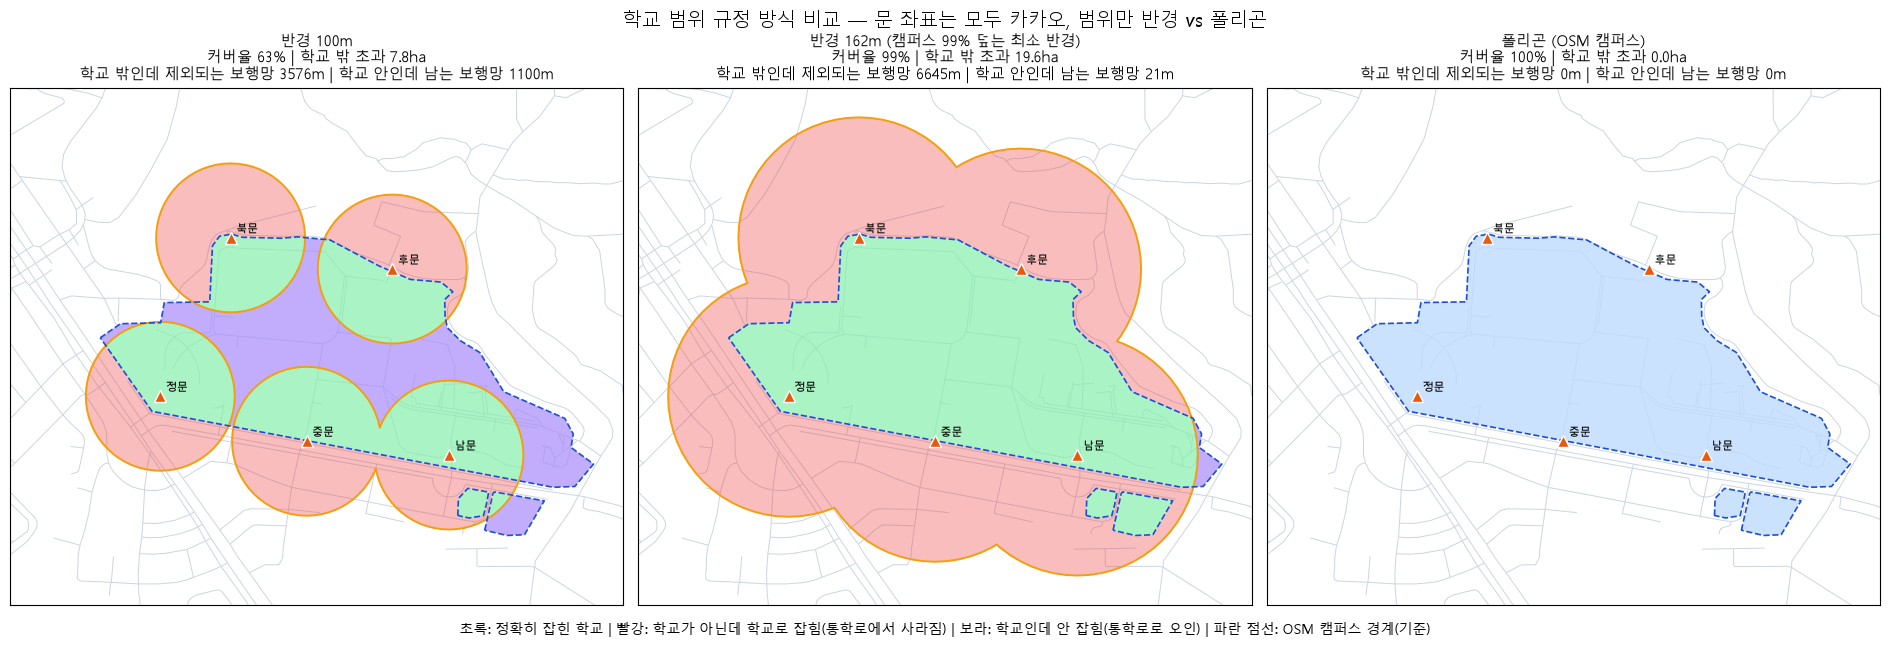

In [6]:
import matplotlib.pyplot as plt
from shapely.ops import unary_union

edges = viz.load_walk_edges()  # OSM 보행망 (EPSG:5186, 800m 원보다 150m 넓게)
gate_pts = list(kakao_gates.values())
r_cover = viz.cover_radius(gate_pts, campus)
regions = {
    '반경 100m': viz.union_of_circles(gate_pts, 100),
    f'반경 {r_cover:.0f}m (캠퍼스 99% 덮는 최소 반경)': viz.union_of_circles(gate_pts, r_cover),
    '폴리곤 (OSM 캠퍼스)': campus,
}
compare = pd.DataFrame({k: viz.evaluate(v, campus, edges) for k, v in regions.items()}).T.round(1)
display(compare)

bx0, by0, bx1, by1 = unary_union(list(regions.values())).bounds
extent = (bx0 - 40, by0 - 40, bx1 + 40, by1 + 40)  # 세 패널을 같은 축척·범위로

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, (name, region) in zip(axes, regions.items()):
    r = compare.loc[name]
    title = (f"{name}\n커버율 {r['캠퍼스 커버율(%)']:.0f}% | 학교 밖 초과 {r['학교 밖 초과 면적(ha)']:.1f}ha\n"
             f"학교 밖인데 제외되는 보행망 {r['학교 밖인데 제외되는 보행망(m)']:.0f}m | 학교 안인데 남는 보행망 {r['학교 안인데 통학로로 남는 보행망(m)']:.0f}m")
    if region is campus:
        viz.draw_map(ax, title, edges, campus, extent, gates=kakao_gates, gate_color='#ea580c')
    else:
        viz.draw_map(ax, title, edges, campus, extent, region, gates=kakao_gates, gate_color='#ea580c')
fig.suptitle('학교 범위 규정 방식 비교 — 문 좌표는 모두 카카오, 범위만 반경 vs 폴리곤', fontsize=14)
fig.text(0.5, 0.02, '초록: 정확히 잡힌 학교 | 빨강: 학교가 아닌데 학교로 잡힘(통학로에서 사라짐) | 보라: 학교인데 안 잡힘(통학로로 오인) | 파란 점선: OSM 캠퍼스 경계(기준)',
         ha='center', fontsize=10)
plt.tight_layout(rect=(0, 0.04, 1, 0.94))
plt.show()

### 1단계 정리

- 학교 범위 = OSM 캠퍼스 폴리곤, 출입구 = 카카오 문 좌표로 규정한다. 반경 방식은 커버율을 올릴수록 학교 밖 길이 함께 제외되어(1-4 참고) 채택하지 않는다.
- 기준점 = 카카오맵 "숭실대학교" 검색 지점(캠퍼스 대표점), 반경 = 800m로 확정.
- 대표점은 정문에서 동쪽으로 약 300m 떨어져 있어, 원의 서쪽 경계가 정문 앞 상권 바로 바깥까지만 닿는다. (위 지도·표 참고)
- **팀 확인 필요:** 중앙대는 기존에 정문(OSM) 기준으로 분석했다. 비교 대시보드에서 기준점 규칙(중앙대=정문 / 숭실대=대표점)이 다르면 비교가 어긋날 수 있다.
- 다음: 2단계에서 이 원 안의 보행망을 노드·엣지로 만들고, 통학로를 어떻게 규정할지(원 안 전체 vs 출발점→출입구 경로, 직선 vs 보행 800m) 정한다.


---
## 2. 구간·거리 규정

**구간 정의** (구현: `soongsil_network.py`)

- 구간의 최소 단위는 OSM 보행망의 **엣지**(교차점~교차점)다. 두 지점 사이 구간은 최단경로로 계산한다.
- 800m 원(직선) 안에서 **학교 폴리곤 안쪽 엣지**(엣지 길이의 50% 이상이 폴리곤 안)를 지운다. 남은 그래프가 학교 밖 보행망이다.
- **문**(카카오 5개)은 남은 그래프의 가장 가까운 노드에 **가상 연결선**(직선거리)으로 붙인다. 연결선이 25m를 넘으면 경고한다.
- 문마다 보행 최단경로를 계산해, 학교 밖 모든 노드가 **보행거리로 가장 가까운 문**과 그 거리를 갖게 한다.
- 엣지는 양 끝 노드의 가장 가까운 문이 같으면 그 문 소속, 다르면 `경계`. **최단경로 중첩수** = 원 안 노드들이 가장 가까운 문으로 가는 최단경로가 그 엣지에서 겹치는 횟수. 실제 통행량이 아니라, 모든 노드를 같은 비중으로 보고 최단경로로 걷는다고 가정한 값이다.
- 원 밖 150m 여유 구간은 우회 경로 계산에만 쓰고, 원 안 결과 집계에서는 뺀다.

**규칙 변경 기록**: 앞서 "출입구 25m 안 엣지는 지우지 않는다"로 정했으나, 이 조건에 걸린 엣지 중 104~165m나 학교 안으로 뻗은 도로가 있어 통째로 남기면 학교 내부 도로가 통학로에 섞인다. 대신 가상 연결선으로 문이 끊기지 않게 했다.

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import soongsil_network as sn

res = sn.run()
campus, circle, gates = res['campus'], res['circle'], res['gates']
nodes, edges, removed = res['nodes'], res['edges'], res['removed']
G_full, G_cut = res['G_full'], res['G_cut']

print(f"OSM 보행망(원+150m): 노드 {len(G_full):,}, 엣지 {G_full.number_of_edges():,}")
print(f"학교 내부 엣지 제거: {len(removed)}개, {removed.geometry.length.sum():,.0f}m -> 남은 그래프 노드 {len(G_cut):,}, 엣지 {G_cut.number_of_edges():,}")
print(f"연결 요소 수: {nx.number_connected_components(G_cut)}  (1이면 학교 밖 보행망이 한 덩어리로 이어짐)")
origins = nodes[nodes['출발노드']]
print(f"출발 노드(원 안·학교 밖): {len(origins)}개, 문에 도달 못 하는 노드: {origins['가까운_문'].isna().sum()}개")
display(res['gate_table'])

OSM 보행망(원+150m): 노드 797, 엣지 1,122
학교 내부 엣지 제거: 71개, 3,109m -> 남은 그래프 노드 738, 엣지 1,051
연결 요소 수: 1  (1이면 학교 밖 보행망이 한 덩어리로 이어짐)
출발 노드(원 안·학교 밖): 400개, 문에 도달 못 하는 노드: 0개


,문,연결_노드,연결선_m,경고
0,정문,11413637697,23.5,False
1,후문,4686503139,2.7,False
2,남문,13149390531,21.4,False
3,북문,2825714913,11.1,False
4,중문,13149390530,4.2,False


-> '연결요소 수 1 ' -> 학교 밖의 구간들이 하나로 묶임을 의미. -> 이를 통해 학교 밖의 모든 구간들을 통학로로 규정할 수가 있는 것임. 

In [8]:
ein = edges[edges['원_안'] & (edges['highway'] != 'gate_connector')]
by_gate = origins.groupby('가까운_문').agg(
    노드수=('node', 'size'), 평균_보행거리_m=('문까지_보행_m', 'mean'), 최대_보행거리_m=('문까지_보행_m', 'max')).round(0)
by_gate['엣지수(원 안)'] = ein.groupby('소속_문').size()
by_gate['엣지길이_km'] = (ein.assign(l=ein.geometry.length).groupby('소속_문')['l'].sum() / 1000).round(2)
display(by_gate.sort_values('노드수', ascending=False))
print('경계 엣지(양 끝이 서로 다른 문 소속):', int((ein['소속_문'] == '경계').sum()), '개')

mis = origins['가까운_문'] != origins['직선_최근접_문']
print(f"직선으로 가장 가까운 문과 보행으로 가장 가까운 문이 다른 노드: {mis.sum()}개 / {len(origins)}개 ({mis.mean() * 100:.1f}%)")
close = origins['1-2순위_차이_m'] < 50
print(f"1순위와 2순위 문의 보행거리 차이가 50m 미만인 노드(어느 문이든 비슷한 곳): {close.sum()}개 ({close.mean() * 100:.1f}%)")

,노드수,평균_보행거리_m,최대_보행거리_m,엣지수(원 안),엣지길이_km
가까운_문,,,,,
정문,171,457.0,1384.0,250,13.44
중문,78,594.0,915.0,102,4.75
남문,76,611.0,1564.0,100,8.12
북문,47,470.0,795.0,67,3.98
후문,28,545.0,972.0,34,3.54


경계 엣지(양 끝이 서로 다른 문 소속): 34 개
직선으로 가장 가까운 문과 보행으로 가장 가까운 문이 다른 노드: 60개 / 400개 (15.0%)
1순위와 2순위 문의 보행거리 차이가 50m 미만인 노드(어느 문이든 비슷한 곳): 51개 (12.8%)


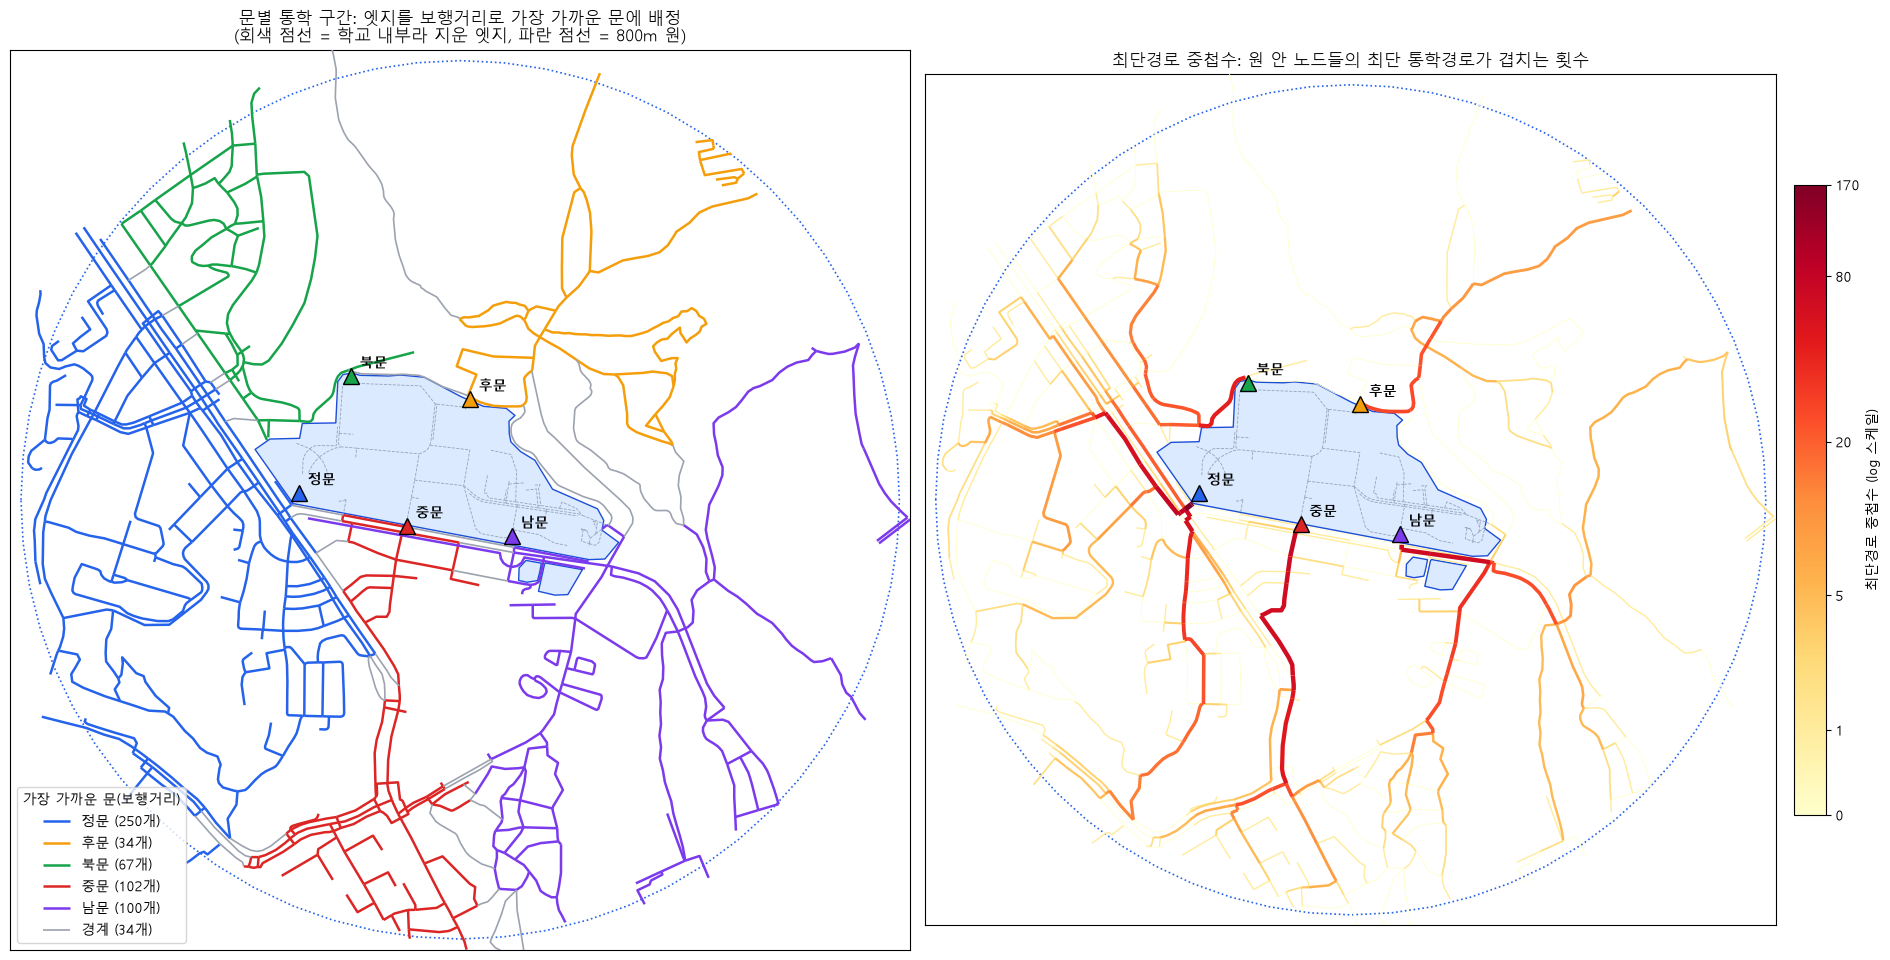

In [9]:
GATE_COLORS = {'정문': '#2563eb', '후문': '#f59e0b', '북문': '#16a34a', '중문': '#dc2626', '남문': '#7c3aed', '경계': '#9ca3af'}
minx, miny, maxx, maxy = circle.bounds

fig, axes = plt.subplots(1, 2, figsize=(19, 9.5))
for ax in axes:
    gpd.GeoSeries([campus]).plot(ax=ax, color='#dbeafe', edgecolor='#1d4ed8', linewidth=1, zorder=1)
    removed.plot(ax=ax, color='#94a3b8', linewidth=0.6, linestyle='--', zorder=2)
    gpd.GeoSeries([circle]).boundary.plot(ax=ax, color='#2563eb', linestyle=':', linewidth=1.2, zorder=2)
    for name, p in gates.items():
        ax.plot(p.x, p.y, '^', ms=11, color=GATE_COLORS[name], markeredgecolor='black', zorder=6)
        ax.annotate(name, (p.x, p.y), fontsize=10, fontweight='bold', xytext=(6, 6), textcoords='offset points', zorder=7)
    ax.set_xlim(minx - 20, maxx + 20); ax.set_ylim(miny - 20, maxy + 20)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

for name in ['정문', '후문', '북문', '중문', '남문', '경계']:
    sub = ein[ein['소속_문'] == name]
    if len(sub):
        sub.plot(ax=axes[0], color=GATE_COLORS[name], linewidth=1.8 if name != '경계' else 1.2, zorder=4, label=f'{name} ({len(sub)}개)')
axes[0].legend(loc='lower left', fontsize=10, title='가장 가까운 문(보행거리)')
axes[0].set_title('문별 통학 구간: 엣지를 보행거리로 가장 가까운 문에 배정\n(회색 점선 = 학교 내부라 지운 엣지, 파란 점선 = 800m 원)', fontsize=12)

use = ein.sort_values('최단경로_중첩수')
norm = plt.Normalize(0, np.log1p(use['최단경로_중첩수'].max()))
use.plot(ax=axes[1], color=plt.cm.YlOrRd(norm(np.log1p(use['최단경로_중첩수']))), linewidth=0.6 + 3.2 * norm(np.log1p(use['최단경로_중첩수'])), zorder=4)
sm = plt.cm.ScalarMappable(norm=norm, cmap='YlOrRd'); sm.set_array([])
cb = fig.colorbar(sm, ax=axes[1], fraction=0.035, pad=0.02); cb.set_label('최단경로 중첩수 (log 스케일)')
ticks = [0, 1, 5, 20, 80, 170]; ticks = [t for t in ticks if t <= use['최단경로_중첩수'].max()]
cb.set_ticks([np.log1p(t) for t in ticks]); cb.set_ticklabels([str(t) for t in ticks])
axes[1].set_title('최단경로 중첩수: 원 안 노드들의 최단 통학경로가 겹치는 횟수', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
out = sn.save(res)
print('저장:', out.name, '(layers: edges, nodes | 좌표계 EPSG:4326)')

top = (ein.assign(길이_m=ein.geometry.length.round(1))
       .sort_values('최단경로_중첩수', ascending=False)
       [['u', 'v', 'highway', '길이_m', '소속_문', '문까지_최소_m', '최단경로_중첩수']].head(10))
print('\n최단경로_중첩수 상위 10개 엣지')
display(top)
print('\nhighway 종류별 원 안 엣지 수·길이(km)')
display(ein.assign(l=ein.geometry.length).groupby('highway').agg(엣지수=('l', 'size'), 길이_km=('l', lambda s: round(s.sum() / 1000, 2))).sort_values('길이_km', ascending=False).head(10))

저장: soongsil_network.gpkg (layers: edges, nodes | 좌표계 EPSG:4326)

최단경로_중첩수 상위 10개 엣지


,u,v,highway,길이_m,소속_문,문까지_최소_m,최단경로_중첩수
1042,11413637697,13149390528,footway,2.9,정문,23.5,170
631,13528976148,13149390528,footway,14.7,정문,26.5,168
36,11413637825,13528976148,footway,11.9,정문,41.1,83
37,11413637825,11413637566,footway,5.7,정문,53.0,79
389,11413637556,11413637566,footway,68.2,정문,58.7,78
411,2890319200,13149390530,service,11.0,중문,4.2,76
827,2890319302,13149390531,service,9.3,남문,21.4,74
401,2824550301,2890319200,service,51.5,중문,15.2,71
541,5746089412,2890319302,primary,55.3,남문,30.8,68
399,2824550301,4620932579,service,29.8,중문,66.8,68



highway 종류별 원 안 엣지 수·길이(km)


,엣지수,길이_km
highway,,
service,206,12.71
residential,116,7.74
footway,124,5.69
path,32,4.48
primary,53,3.47
tertiary,44,2.28
"['steps', 'path']",3,0.90
"['service', 'path']",2,0.79
steps,4,0.19


구간들이 중첩되는 정도를 나타낸 것은 실제 그 구간들을 사람들이 통학로로 얼마나 이용하는가에 대한 예측의 차원임.

### 2단계 정리

- **산출물**: `data/soongsil_network.gpkg` (layers `edges`, `nodes`, 좌표계 EPSG:4326, 노드는 `lon`·`lat` 열 포함). 엣지마다 소속 문, 문까지 보행거리(최소/최대), 최단경로 중첩수, highway 종류가 붙어 있다. 3단계에서 경사도·음향신호기·사고다발지역 등을 이 엣지에 겹친다.
- **읽는 법**: 통학 구간 = "원 안 학교 밖 노드가 가장 가까운 문으로 가는 최단경로". 캠퍼스를 가로지르는 지름길은 제외된다(학교 안쪽 엣지를 지웠기 때문).
- **한계**
  - 학교 폴리곤·보행망이 OSM이라 경계와 도로 표기의 정확도에 의존한다.
  - 문은 보행자 출입구인지 확인하지 않았다(차량 전용 문이면 통학 구간이 왜곡될 수 있음).
  - 창의관·정보과학관 부지(작은 조각 2개)에는 문이 없어 주변 길은 가까운 다른 문으로 배정된다.
  - 1순위와 2순위 문의 거리 차이가 작은 노드는 배정이 민감하다(위 2-2 참고).
  - 방향·계단·횡단 여부는 아직 반영하지 않았다(3단계에서 엣지 속성으로 검토).


---
## 중앙대 1. 대학가 규정 (숭실대와 같은 기준)

비교가 어긋나지 않도록 중앙대도 숭실대와 똑같이 **카카오 학교 대표점 중심 반경 800m**를 대학가로 본다. 학교 범위는 OSM 캠퍼스 폴리곤, 출입문은 공식 안내에서 이름을 확인한 카카오 좌표(정문·중문·후문)를 쓴다.

- 계산 좌표계: EPSG:5186(미터)
- 저장·표시 좌표계: EPSG:4326
- 기존 중앙대 분석의 OSM 정문 기준점은 비교표에 남겨 기준 변경의 영향을 확인한다.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import folium
from shapely.geometry import Point
from shapely.ops import unary_union
from pathlib import Path

import chungang_config as ccfg
import chungang_network as cn
import viz_campus_definition as viz

DATA_DIR = Path('data')

cau_center = viz.to_proj(Point(ccfg.CENTER_LON, ccfg.CENTER_LAT))
cau_circle = cau_center.buffer(ccfg.RADIUS_M)
cau_campus = viz.to_proj(cn.load_campus_polygon())
cau_gates_ll = cn.load_gates_ll()
cau_gates = cn.load_gates()

print(f'중앙대 카카오 대표점: {ccfg.CENTER_LAT:.7f}, {ccfg.CENTER_LON:.7f}')
print(f'반경: {ccfg.RADIUS_M}m | 캠퍼스 OSM ID: {cn.OSM_RELATION_ID}')

중앙대 카카오 대표점: 37.5051494, 126.9571734
반경: 800m | 캠퍼스 OSM ID: 284355223


### 중앙대 1-2. 후보 지점 비교 (대표점·정문·출입구)

카카오 대표점, 공식 명칭이 확인된 카카오 출입문 3곳, 기존 분석의 OSM 정문을 같은 표에서 비교한다. 거리와 800m 원의 겹침(IoU)은 EPSG:5186에서 계산한다.

In [2]:
rows = [{'후보': 'KAKAO 대표점', '장소명': '중앙대학교 서울캠퍼스', 'lat': ccfg.CENTER_LAT, 'lon': ccfg.CENTER_LON}]
rows += [{'후보': f'KAKAO {r.문}', '장소명': f'중앙대학교 서울캠퍼스 {r.문}', 'lat': r.lat, 'lon': r.lon}
         for r in cau_gates_ll.itertuples()]
rows += [{'후보': '기존 OSM 정문', '장소명': '중앙대학교 정문(기존 기준점)',
          'lat': ccfg.OLD_MAIN_GATE_LAT, 'lon': ccfg.OLD_MAIN_GATE_LON}]
cau_candidates = pd.DataFrame(rows)
cau_points = gpd.GeoSeries([Point(r.lon, r.lat) for r in cau_candidates.itertuples()], crs='EPSG:4326').to_crs('EPSG:5186')
ref = cau_points.iloc[0]
cau_candidates['대표점과의거리_m'] = [round(p.distance(ref), 1) for p in cau_points]
base_circle = ref.buffer(ccfg.RADIUS_M)
cau_candidates['대표점_원과_IoU'] = [round(p.buffer(ccfg.RADIUS_M).intersection(base_circle).area /
                                           p.buffer(ccfg.RADIUS_M).union(base_circle).area, 3) for p in cau_points]
cau_candidates.to_csv(DATA_DIR / 'chungang_center_candidates.csv', index=False, encoding='utf-8-sig')
display(cau_candidates)

,후보,장소명,lat,lon,대표점과의거리_m,대표점_원과_IoU
0,KAKAO 대표점,중앙대학교 서울캠퍼스,37.505149,126.957173,0.0,1.000
1,KAKAO 정문,중앙대학교 서울캠퍼스 정문,37.506756,126.958470,212.0,0.712
2,KAKAO 중문,중앙대학교 서울캠퍼스 중문,37.505943,126.957223,88.2,0.869
3,KAKAO 후문,중앙대학교 서울캠퍼스 후문,37.504920,126.954065,276.1,0.641
4,기존 OSM 정문,중앙대학교 정문(기존 기준점),37.507042,126.959152,273.4,0.644


### 중앙대 1-3. 학교 범위 규정 — 카카오 문 좌표 + OSM 캠퍼스 폴리곤

공식 안내에서 확인되는 중앙대 서울캠퍼스 문은 정문·중문·후문 3곳이다. 병원 문과 부속학교 문은 캠퍼스 문에서 제외한다. 아래에서 문 좌표가 OSM 경계와 얼마나 가까운지 확인한다.

In [3]:
cau_campus_ll = gpd.GeoSeries([cau_campus], crs='EPSG:5186').to_crs('EPSG:4326').iloc[0]
cau_circle_ll = gpd.GeoSeries([cau_circle], crs='EPSG:5186').to_crs('EPSG:4326').iloc[0]
gate_rows = []
for name, p in cau_gates.items():
    gate_rows.append({'문': name, 'lat': float(cau_gates_ll.loc[cau_gates_ll['문'].eq(name), 'lat'].iloc[0]),
                      'lon': float(cau_gates_ll.loc[cau_gates_ll['문'].eq(name), 'lon'].iloc[0]),
                      '폴리곤': '안' if cau_campus.covers(p) else '밖', '경계까지_m': round(p.distance(cau_campus.boundary), 1),
                      '기준점과의거리_m': round(p.distance(cau_center))})
cau_gate_table = pd.DataFrame(gate_rows).sort_values('경계까지_m')
display(cau_gate_table)
print(f'캠퍼스 폴리곤: {cau_campus.area / 1e4:.1f}ha')
print(f'대학가 영역(반경 800m): {cau_circle.area / 1e6:.2f}km², 그중 캠퍼스 {cau_campus.intersection(cau_circle).area / cau_circle.area * 100:.1f}%')

mc = folium.Map(location=[ccfg.CENTER_LAT, ccfg.CENTER_LON], zoom_start=15, tiles='OpenStreetMap')
folium.GeoJson(cau_circle_ll.__geo_interface__, style_function=lambda _: {'color': '#2563eb', 'weight': 2, 'fillOpacity': 0.03}, tooltip='대학가 영역 800m').add_to(mc)
folium.GeoJson(cau_campus_ll.__geo_interface__, style_function=lambda _: {'color': '#1d4ed8', 'weight': 2, 'fillColor': '#60a5fa', 'fillOpacity': 0.3}, tooltip='OSM 캠퍼스 폴리곤').add_to(mc)
for r in cau_gate_table.itertuples():
    folium.CircleMarker([r.lat, r.lon], radius=6, color='#dc2626', fill=True, fill_opacity=.9,
                        tooltip=f'카카오 {r.문} | 경계까지 {r.경계까지_m}m').add_to(mc)
folium.Marker([ccfg.CENTER_LAT, ccfg.CENTER_LON], tooltip='카카오 중앙대학교 서울캠퍼스 대표점', icon=folium.Icon(color='blue')).add_to(mc)
mc

,문,lat,lon,폴리곤,경계까지_m,기준점과의거리_m
0,정문,37.506756,126.958470,안,2.2,212
2,후문,37.504920,126.954065,안,10.0,276
1,중문,37.505943,126.957223,안,20.6,88


캠퍼스 폴리곤: 14.5ha
대학가 영역(반경 800m): 2.01km², 그중 캠퍼스 7.2%


### 중앙대 1-4. 학교 범위 규정 방식 비교 — 단순 반경 vs 폴리곤

숭실대 1-4와 같은 네 지표로 비교한다. 문 주변 원은 캠퍼스 모양을 근사하는 방식이고, OSM 폴리곤은 학교 안쪽 엣지를 제외하기 위한 기준이다.

,캠퍼스 커버율(%),학교 밖 초과 면적(ha),학교 밖인데 제외되는 보행망(m),학교 안인데 통학로로 남는 보행망(m)
반경 100m,30.1,4.5,1316.2,1504.9
반경 379m (캠퍼스 99% 덮는 최소 반경),99.0,63.7,14866.4,0.0
폴리곤 (OSM 캠퍼스),100.0,0.0,0.0,0.0


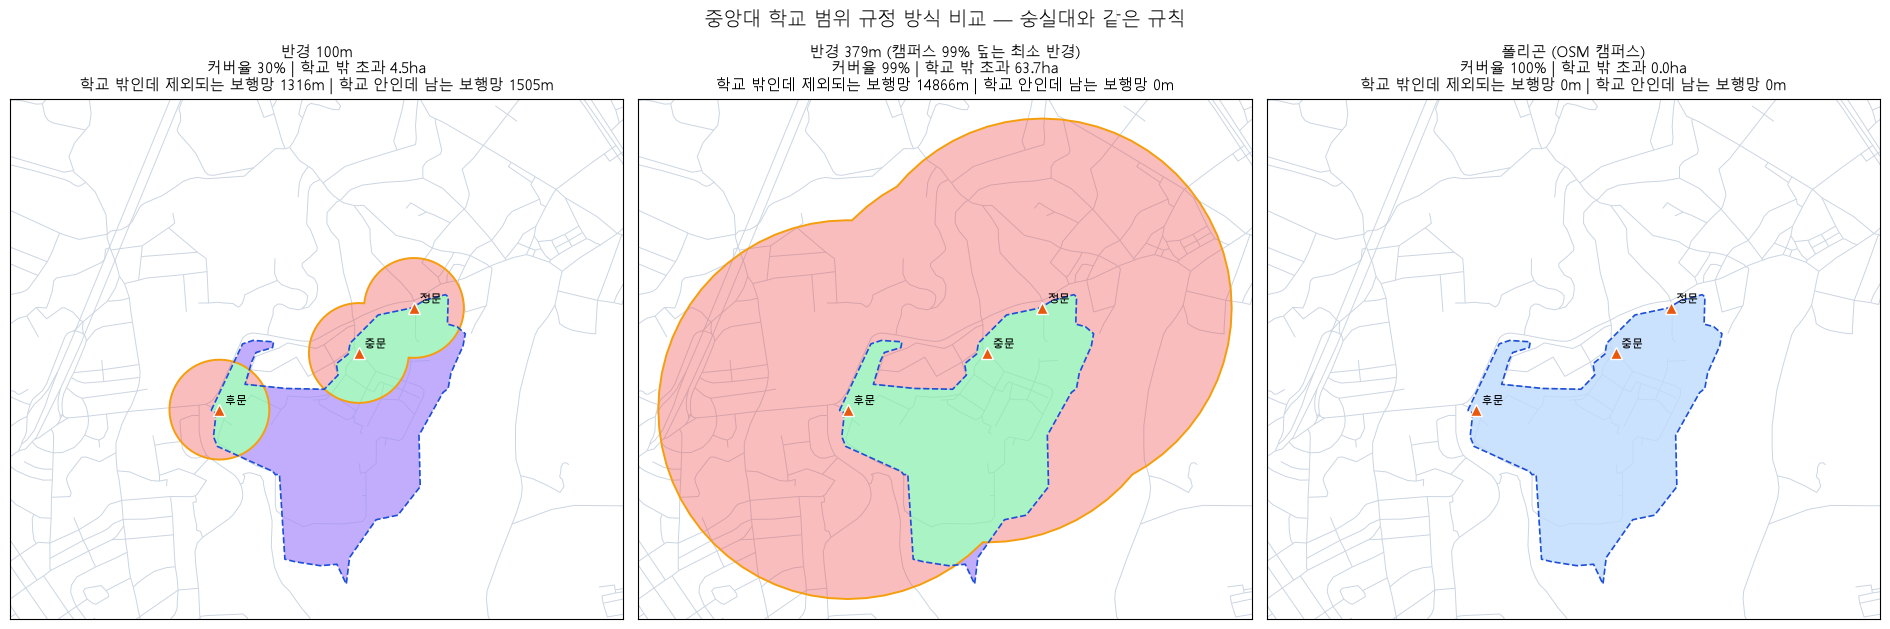

In [4]:
cau_walk_edges = cn.load_walk_edges()
cau_r_cover = viz.cover_radius(list(cau_gates.values()), cau_campus)
cau_regions = {'반경 100m': viz.union_of_circles(list(cau_gates.values()), 100),
               f'반경 {cau_r_cover:.0f}m (캠퍼스 99% 덮는 최소 반경)': viz.union_of_circles(list(cau_gates.values()), cau_r_cover),
               '폴리곤 (OSM 캠퍼스)': cau_campus}
cau_compare = pd.DataFrame({k: viz.evaluate(v, cau_campus, cau_walk_edges) for k, v in cau_regions.items()}).T.round(1)
display(cau_compare)

bx0, by0, bx1, by1 = unary_union(list(cau_regions.values())).bounds
extent = (bx0 - 40, by0 - 40, bx1 + 40, by1 + 40)
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, (name, region) in zip(axes, cau_regions.items()):
    r = cau_compare.loc[name]
    title = (f"{name}\n커버율 {r['캠퍼스 커버율(%)']:.0f}% | 학교 밖 초과 {r['학교 밖 초과 면적(ha)']:.1f}ha\n"
             f"학교 밖인데 제외되는 보행망 {r['학교 밖인데 제외되는 보행망(m)']:.0f}m | 학교 안인데 남는 보행망 {r['학교 안인데 통학로로 남는 보행망(m)']:.0f}m")
    viz.draw_map(ax, title, cau_walk_edges, cau_campus, extent, None if region is cau_campus else region,
                 gates=cau_gates, gate_color='#ea580c')
fig.suptitle('중앙대 학교 범위 규정 방식 비교 — 숭실대와 같은 규칙', fontsize=14)
plt.tight_layout(rect=(0, 0, 1, .94)); plt.show()

### 중앙대 1단계 정리

- 비교 기준을 통일해 **카카오 ‘중앙대학교 서울캠퍼스’ 대표점 + 반경 800m**를 사용한다.
- 학교 범위는 OSM 캠퍼스 폴리곤, 출입문은 공식 명칭이 확인된 카카오 정문·중문·후문 좌표다.
- 기존 중앙대 정문 기준 분석과 중심점이 다르므로, 기존 1km 결과와 이번 비교용 800m 결과를 혼용하지 않는다.

---
## 중앙대 2. 구간·거리 규정

숭실대와 같은 규칙으로 OSM 보행망을 만든다. 800m 원보다 150m 넓게 받은 뒤 캠퍼스 내부 비율이 50% 이상인 엣지를 제거하고, 각 문을 가장 가까운 외부 노드에 가상 연결한다. 원 안·학교 밖 노드에서 보행거리상 가장 가까운 문까지의 최단경로와 엣지별 최단경로 중첩수를 계산한다.

OSM 보행망(원+150m): 노드 696, 엣지 996
학교 내부 엣지 제거: 41개, 2,580m -> 남은 노드 663, 엣지 955
연결 요소 수: 1
출발 노드: 333개, 문에 도달 못 하는 노드: 0개


,문,연결_노드,연결선_m,경고
0,정문,2890319153,14.7,False
1,중문,4613243825,14.8,False
2,후문,436883219,30.2,True


,노드수,평균_보행거리_m,최대_보행거리_m,엣지수(원 안),엣지길이_km
가까운_문,,,,,
후문,172,521.0,1334.0,255,16.50
정문,156,594.0,1586.0,226,15.71
중문,5,113.0,268.0,7,0.60


직선 최근접 문과 보행 최근접 문이 다른 노드: 17개 / 333개 (5.1%)
1·2순위 문 거리 차이가 50m 미만: 7개 (2.1%)


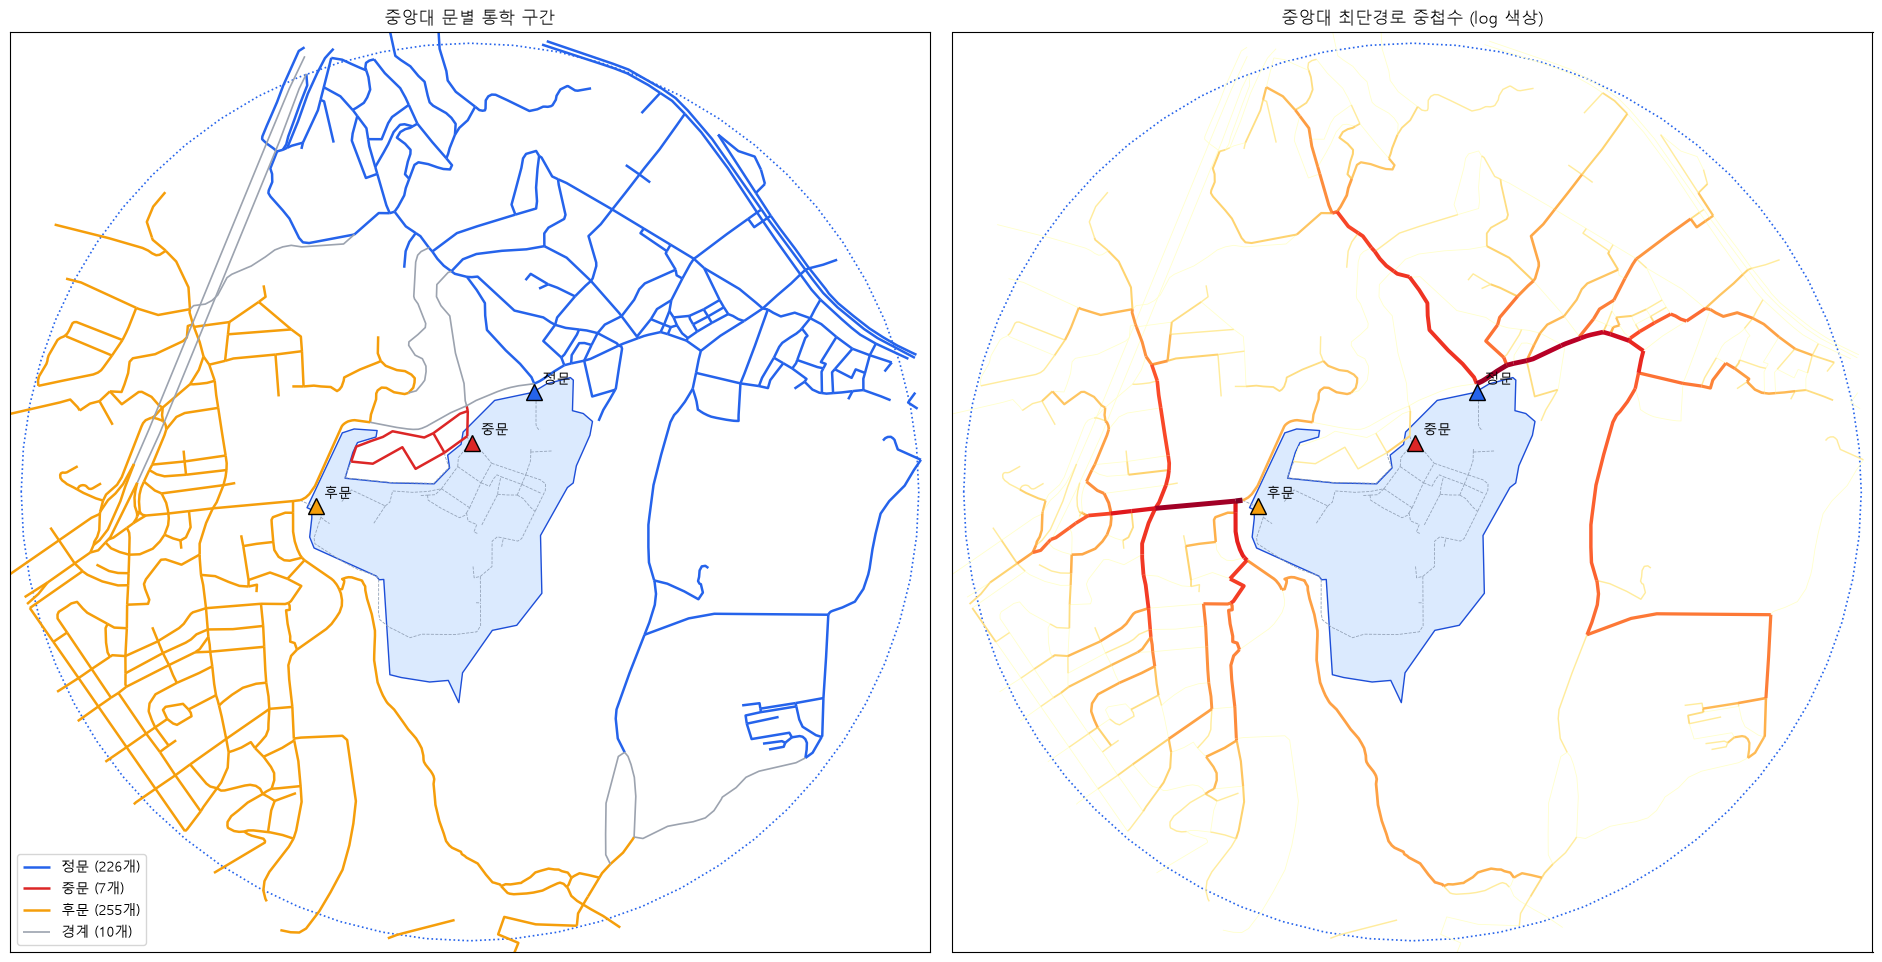

저장: chungang_network.gpkg (layers: edges, nodes | EPSG:4326)


In [5]:
cau_res = cn.run()
cau_nodes, cau_edges, cau_removed = cau_res['nodes'], cau_res['edges'], cau_res['removed']
cau_origins = cau_nodes[cau_nodes['출발노드']]
cau_ein = cau_edges[cau_edges['원_안'] & (cau_edges['highway'] != 'gate_connector')]
print(f"OSM 보행망(원+150m): 노드 {len(cau_res['G_full']):,}, 엣지 {cau_res['G_full'].number_of_edges():,}")
print(f"학교 내부 엣지 제거: {len(cau_removed)}개, {cau_removed.geometry.length.sum():,.0f}m -> 남은 노드 {len(cau_res['G_cut']):,}, 엣지 {cau_res['G_cut'].number_of_edges():,}")
print(f"연결 요소 수: {nx.number_connected_components(cau_res['G_cut'])}")
print(f"출발 노드: {len(cau_origins)}개, 문에 도달 못 하는 노드: {cau_origins['가까운_문'].isna().sum()}개")
display(cau_res['gate_table'])

cau_by_gate = cau_origins.groupby('가까운_문').agg(노드수=('node', 'size'), 평균_보행거리_m=('문까지_보행_m', 'mean'), 최대_보행거리_m=('문까지_보행_m', 'max')).round(0)
cau_by_gate['엣지수(원 안)'] = cau_ein.groupby('소속_문').size()
cau_by_gate['엣지길이_km'] = (cau_ein.assign(l=cau_ein.geometry.length).groupby('소속_문')['l'].sum() / 1000).round(2)
display(cau_by_gate.sort_values('노드수', ascending=False))
mis = cau_origins['가까운_문'] != cau_origins['직선_최근접_문']
close = cau_origins['1-2순위_차이_m'] < 50
print(f'직선 최근접 문과 보행 최근접 문이 다른 노드: {mis.sum()}개 / {len(cau_origins)}개 ({mis.mean()*100:.1f}%)')
print(f'1·2순위 문 거리 차이가 50m 미만: {close.sum()}개 ({close.mean()*100:.1f}%)')

cau_colors = {'정문': '#2563eb', '중문': '#dc2626', '후문': '#f59e0b', '경계': '#9ca3af'}
minx, miny, maxx, maxy = cau_res['circle'].bounds
fig, axes = plt.subplots(1, 2, figsize=(19, 9.5))
for ax in axes:
    gpd.GeoSeries([cau_res['campus']]).plot(ax=ax, color='#dbeafe', edgecolor='#1d4ed8', linewidth=1)
    cau_removed.plot(ax=ax, color='#94a3b8', linewidth=.6, linestyle='--')
    gpd.GeoSeries([cau_res['circle']]).boundary.plot(ax=ax, color='#2563eb', linestyle=':', linewidth=1.2)
    for name, p in cau_res['gates'].items():
        ax.plot(p.x, p.y, '^', ms=11, color=cau_colors[name], markeredgecolor='black', zorder=6); ax.annotate(name, (p.x, p.y), xytext=(6,6), textcoords='offset points')
    ax.set(xlim=(minx-20,maxx+20), ylim=(miny-20,maxy+20)); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
for name in ['정문','중문','후문','경계']:
    sub = cau_ein[cau_ein['소속_문'] == name]
    if len(sub): sub.plot(ax=axes[0], color=cau_colors[name], linewidth=1.8 if name != '경계' else 1.2, label=f'{name} ({len(sub)}개)')
axes[0].legend(loc='lower left'); axes[0].set_title('중앙대 문별 통학 구간')
use = cau_ein.sort_values('최단경로_중첩수'); norm = plt.Normalize(0, np.log1p(use['최단경로_중첩수'].max()))
use.plot(ax=axes[1], color=plt.cm.YlOrRd(norm(np.log1p(use['최단경로_중첩수']))), linewidth=.6 + 3.2*norm(np.log1p(use['최단경로_중첩수'])))
axes[1].set_title('중앙대 최단경로 중첩수 (log 색상)'); plt.tight_layout(); plt.show()

cau_out = cn.save(cau_res)
print('저장:', cau_out.name, '(layers: edges, nodes | EPSG:4326)')

### 중앙대 2단계 정리

- 산출물: `data/chungang_network.gpkg` (`edges`, `nodes`, EPSG:4326).
- 통학 구간의 뜻과 최단경로 중첩수의 한계는 숭실대 2단계와 같다. 실제 통행량이 아니라 원 안 노드들이 가장 가까운 문으로 향한다고 가정한 경로 중첩이다.
- 후문 가상 연결선이 25m를 넘으면 경고로 남긴다. 이는 OSM 보행망 또는 캠퍼스 경계의 누락 가능성을 뜻하므로 현장·지도 확인 대상이다.
- 병원·부속학교 출입구는 중앙대 캠퍼스 문에서 제외했다.

---
## 3. 시각화·가설 설정

먼저 3단계에 쓸 데이터를 하나씩 살펴본다(3-0 ~ 3-8). 3-0에서는 로딩 직후 결측·이상을 확인하고 처리한다. **분석·가설이 아니라 데이터의 구성, 결측, 분포, 숭실대 800m 안의 표본 크기를 확인하는 단계**다. 시각화·가설 설정은 이 결과를 바탕으로 이어서 진행한다.

| 번호 | 데이터 | 여기서 보는 것 |
|---|---|---|
| 3-0 | 3단계 전체 데이터 | 로딩·인벤토리, **결측·이상 확인과 처리**(3-0-1 ~ 3-0-10) |
| 3-1 | 보행자 사고다발지역 | 컬럼 구성·분포, 컬럼 간 관계 |
| 3-2 | 서울시 경사도 (등고선·표고점) | 자료 성격, 숭실대 엣지 경사 분포 |
| 3-3 | 교차로·횡단보도 | 구성, 보행등 유무 |
| 3-4 | 음향신호기 | 결측 구조, 횡단보도와의 좌표 정합 |
| 3-5 | 장애인편의시설 | 시설유형 구성 |
| 3-6 | 시각장애인 현황(장애유형별) | 표 구조, 자치구별 규모 |
| 3-7 | 인구수 | 보류 (대학이라 행정동 인구가 이용자를 대표하지 못한다는 판단) |
| 3-8 | 교통약자 다발지점(보행자) | 구성, 한계 |

색: 파랑 = 서울 전체·일반, 주황 = 동작구(숭실대 소재) 강조.

In [11]:
import sys
import warnings
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import rcParams
from shapely.geometry import Point, shape

warnings.filterwarnings('ignore')

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'data').exists():
    PROJECT_DIR = PROJECT_DIR / 'DartB_TOYPROJECT'
sys.path.insert(0, str(PROJECT_DIR))
import soongsil_config as cfg
import viz_campus_definition as viz

DATA_DIR = PROJECT_DIR / 'data'
PROJ = 'EPSG:5186'  # 중부원점 TM (m)

# 3단계 공통 설정. 색: 파랑 = 기본, 주황 = 강조(동작구·숭실대). 글자는 시리즈 색이 아니라 텍스트 색을 쓴다.
BLUE, ORANGE, INK, MUTED, GRID, SURFACE = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#e5e5e2', '#fcfcfb'
rcParams.update({
    'font.family': 'Malgun Gothic', 'axes.unicode_minus': False,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#c9c8c2',
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.titlecolor': INK, 'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7, 'axes.axisbelow': True,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
})

center = viz.to_proj(Point(cfg.CENTER_LON, cfg.CENTER_LAT))
circle = center.buffer(cfg.RADIUS_M)   # 숭실대 800m 원 (EPSG:5186)
campus = viz.to_proj(viz.load_campus_polygon())

def read_csv_flexible(path, **kw):
    for enc in ('utf-8-sig', 'cp949'):
        try:
            return pd.read_csv(path, encoding=enc, **kw)
        except UnicodeDecodeError:
            continue
    raise ValueError(f'인코딩을 찾지 못함: {path}')

def to_gdf(df, x, y, crs):
    d = df.copy()
    d[x] = pd.to_numeric(d[x], errors='coerce'); d[y] = pd.to_numeric(d[y], errors='coerce')
    d = d.dropna(subset=[x, y])
    return gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(d[x], d[y]), crs=crs).to_crs(PROJ)

def barh_highlight(ax, series, highlight='동작구', title='', xlabel='', fmt='{:,.0f}'):
    """가로 막대: 하이라이트 항목만 주황, 나머지 파랑. 값은 막대 끝에 직접 표기."""
    s = series.sort_values()
    colors = [ORANGE if i == highlight else BLUE for i in s.index]
    ax.barh(s.index.astype(str), s.values, color=colors, height=0.7)
    for y, v in enumerate(s.values):
        ax.text(v, y, ' ' + fmt.format(v), va='center', fontsize=8, color=MUTED)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.grid(axis='y', visible=False)

print('설정 완료. 기준점:', (cfg.CENTER_LAT, cfg.CENTER_LON), '| 반경', cfg.RADIUS_M, 'm')

설정 완료. 기준점: (37.495853033944364, 126.95781764313084) | 반경 800 m


### 3-0. 데이터 로딩과 인벤토리

각 데이터의 규모, 좌표 유무, 기준 시점, **숭실대 800m 원 안 표본 크기**를 한 표로 정리한다. 기준 시점은 파일 안에서 확인되는 것만 적고, 확인되지 않으면 그렇게 적는다.

표의 `좌표` 열은 **원본 파일의 좌표계**다. 원본은 4326·5186·5174가 섞여 있어서, 읽을 때 모두 **EPSG:5186으로 바꿔 계산**한다(`to_gdf`). 결과물로 내보낼 때는 EPSG:4326으로 되돌린다.

In [12]:
# 1 사고다발지역
acc = read_csv_flexible(PROJECT_DIR / '보행자_사고_다발지역.csv')
acc_cols = ['사고건수', '사상자수', '사망자수', '중상자수', '경상자수', '부상신고자수']
acc[acc_cols] = acc[acc_cols].apply(pd.to_numeric, errors='coerce')
acc['자치구'] = acc['시도시군구명'].astype(str).str.extract(r'([가-힣]+구)')[0]
acc_seoul = acc[acc['시도시군구명'].astype(str).str.startswith('서울')].copy()  # 파일은 전국 자료라 서울만 따로 본다
acc_g = to_gdf(acc, '경도', '위도', 'EPSG:4326')

# 3 횡단보도 (엑셀 -> CSV 변환본)
cross = read_csv_flexible(PROJECT_DIR / '서울시_교차로_및_횡단보도_시설위치정보_20260824.csv')
cross_g = to_gdf(cross, 'X좌표', 'Y좌표', PROJ)

# 4 음향신호기
aud = read_csv_flexible(PROJECT_DIR / '음향신호기_현황.csv')
aud_g = to_gdf(aud, 'XCE', 'YCE', PROJ)

# 5 장애인편의시설
fac = read_csv_flexible(PROJECT_DIR / '서울시_장애인편의시설_목록정보(한국사회보장정보원)_.csv')
fac_ok = fac[pd.to_numeric(fac['시설위도'], errors='coerce').between(33, 39) & pd.to_numeric(fac['시설경도'], errors='coerce').between(124, 132)]
fac_g = to_gdf(fac_ok, '시설경도', '시설위도', 'EPSG:4326')

# 6 시각장애인 현황 (머리글 4행짜리 표)
disab_raw = read_csv_flexible(PROJECT_DIR / '장애인+현황(장애유형별_동별)_20260921153328.csv', header=None)

# 8 교통약자 다발지점(보행자)
vul = read_csv_flexible(PROJECT_DIR / '교통약자다발지점_보행자.csv')

inside = lambda g: int(g.geometry.within(circle).sum())
inventory = pd.DataFrame([
    ['1 보행자 사고다발지역', '보행자_사고_다발지역.csv', f'전국 {len(acc):,} (서울 {len(acc_seoul)})', '있음(경위도)', '파일에 없음(확인 필요)', inside(acc_g)],
    ['2 서울시 경사도', '서울시_경사도/ (등고선·표고점 shp)', '등고선 13,704 / 표고점 76,580', '있음(EPSG:5174)', '파일에 없음(수치지도 5000)', '엣지에 계산해 붙임'],
    ['3 교차로·횡단보도', '서울시_교차로_및_횡단보도_시설위치정보_20260824', len(cross), '있음(EPSG:5186)', '2026-08-24 (파일명)', inside(cross_g)],
    ['4 음향신호기', '음향신호기_현황.csv', len(aud), f'{len(aud_g) / len(aud) * 100:.0f}%만 있음(EPSG:5186)', '2026-05-28 (폴더명)', inside(aud_g)],
    ['5 장애인편의시설', '서울시_장애인편의시설_목록정보...csv', len(fac), f'{len(fac_g) / len(fac) * 100:.1f}% 유효(경위도)', '파일에 없음(확인 필요)', inside(fac_g)],
    ['6 시각장애인 현황', '장애인+현황(장애유형별_동별)...csv', '25개 자치구', '없음(자치구 단위)', '2025 (파일 내 머리글)', '동작구 1행'],
    ['7 인구수', '-', '-', '-', '보류', '-'],
    ['8 교통약자 다발지점(보행자)', '교통약자다발지점_보행자.csv', len(vul), '없음(지점명만)', '2024년 기준 3년간 (사용자 확인)', '지점명으로만 확인 가능'],
], columns=['데이터', '파일', '서울 규모', '좌표', '기준 시점', '숭실대 800m 안'])
display(inventory)

,데이터,파일,서울 규모,좌표,기준 시점,숭실대 800m 안
0,1 보행자 사고다발지역,보행자_사고_다발지역.csv,"전국 2,402 (서울 693)",있음(경위도),파일에 없음(확인 필요),3
1,2 서울시 경사도,서울시_경사도/ (등고선·표고점 shp),"등고선 13,704 / 표고점 76,580",있음(EPSG:5174),파일에 없음(수치지도 5000),엣지에 계산해 붙임
2,3 교차로·횡단보도,서울시_교차로_및_횡단보도_시설위치정보_20260824,21776,있음(EPSG:5186),2026-08-24 (파일명),69
3,4 음향신호기,음향신호기_현황.csv,21451,79%만 있음(EPSG:5186),2026-05-28 (폴더명),72
4,5 장애인편의시설,서울시_장애인편의시설_목록정보...csv,29153,82.6% 유효(경위도),파일에 없음(확인 필요),111
5,6 시각장애인 현황,장애인+현황(장애유형별_동별)...csv,25개 자치구,없음(자치구 단위),2025 (파일 내 머리글),동작구 1행
6,7 인구수,-,-,-,보류,-
7,8 교통약자 다발지점(보행자),교통약자다발지점_보행자.csv,750,없음(지점명만),2024년 기준 3년간 (사용자 확인),지점명으로만 확인 가능


---
### 3-0-1. 결측·이상 확인과 처리 — 기준과 도구

3-1부터 데이터를 살펴보기 **전에**, 3단계에서 쓰는 데이터를 하나씩 원본 상태에서 점검하고 처리한다(3-0-2 ~ 3-0-8). 3-0-9에서 처리 내역을 한 표로 모으고, 3-0-10에서 결과를 정리한다.

| 구분 | 기준 |
|---|---|
| 결측 | NaN과 공백 문자열을 모두 센다. 값이 하나뿐인 컬럼도 같이 보여준다(분석에 쓸 수 없는 컬럼이다). |
| 이상: 논리 오류 | 형식·범위·합계가 맞지 않는 값. 음수·소수 건수, 없는 날짜, 좌표가 (0, 0)이거나 서울 밖, 합계 불일치 등. |
| 이상: 분포상 드문 값 | IQR(사분위 범위) 1.5배 바깥. **검토 후보 표시일 뿐 삭제하지 않는다.** 선별된 자료나 고도처럼 큰 값이 정상인 경우가 많다. |
| 처리 | 원본 변수(`acc`, `cross`, `aud` …)는 바꾸지 않고 `*_clean` 변수에 새로 만든다. 행은 지우지 않는다(예외는 표에 명시). 결측은 임의로 채우지 않고 "알 수 없음"으로 둔다. 다른 컬럼으로 계산해서 확정되는 값만 예외로 채운다. |

처리한 내용은 `clean_log`에 쌓고 3-0-9에서 표로 보여준다.

In [ ]:
# 3-0-1 결측·이상 확인 공통 도구. 원본 변수는 바꾸지 않고, 처리 결과는 *_clean 변수에 새로 만든다.
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

clean_log = []  # 3-0-9에서 표로 모은다

def log_clean(dataset, finding, n, action, reason=''):
    clean_log.append({'데이터': dataset, '확인 결과': finding, '행 수': n, '처리': action, '근거': reason})

def show_missing(df, name):
    """NaN과 공백 문자열을 결측으로 센다. 결측이 있거나 값이 하나뿐인 컬럼만 표로 보여준다."""
    blank = df.apply(lambda s: s.map(lambda x: isinstance(x, str) and not x.strip()))
    m = df.isna() | blank
    t = pd.DataFrame({'결측수': m.sum(), '결측률_%': (m.mean() * 100).round(2), '고유값수': df.nunique(), 'dtype': df.dtypes.astype(str)})
    t = t[(t['결측수'] > 0) | (t['고유값수'] <= 1)]
    print(f'[{name}] {len(df):,}행 x {df.shape[1]}열 | 결측이 있거나 값이 하나뿐인 컬럼 {len(t)}개')
    if len(t):
        display(t)
    return t

def iqr_flag(s):
    """IQR 1.5배 바깥이면 True. 삭제 기준이 아니라 검토 후보 표시다. (표시, 하한, 상한)"""
    v = pd.to_numeric(s, errors='coerce')
    q1, q3 = v.quantile([.25, .75])
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    return (v < lo) | (v > hi), lo, hi

def to_date(s):
    """YYYYMMDD 숫자를 날짜로. 실제로 없는 날짜(예: 20201310)는 NaT."""
    t = pd.to_numeric(s, errors='coerce').astype('Int64').astype('string')
    return pd.to_datetime(t, format='%Y%m%d', errors='coerce')

SEOUL_BOX = dict(lon=(126.7, 127.3), lat=(37.4, 37.75))  # 서울을 넉넉히 감싸는 사각형. 행정경계 검사는 아니다.
print('준비 완료')

준비 완료


### 3-0-2. 보행자 사고다발지역

- **확인**: 결측, 건수의 음수·소수, `사상자수 = 세부 합계`, 경위도 범위, 폴리곤이 해석되고 유효한지·대표점을 포함하는지, 서울 구분(시도 표기와 법정동코드)이 서로 맞는지.
- **이상 후보**: 서울 기준 IQR 1.5배 바깥(사고건수·사상자수·사고당 사상자수)과 서울 안에서 앞선 행과 같은 경위도·폴리곤·지점명.
- **처리**: 행 삭제·합산은 하지 않는다. `사고다발지id`가 5종류뿐이라 반복 기록이 다른 기간·구분인지 확인할 수 없기 때문이다. 대신 `서울여부`, `반복_*`, `IQR후보_*` 표시 열을 붙인다.

In [ ]:
# 사고다발지역: 원본(acc)은 그대로 두고 acc_clean에 표시 열만 추가한다
show_missing(acc.drop(columns='자치구'), '사고다발지역')

num = acc[acc_cols]
detail = ['사망자수', '중상자수', '경상자수', '부상신고자수']
n_neg, n_frac = int((num < 0).sum().sum()), int((num % 1 != 0).sum().sum())
n_sum = int((acc['사상자수'] != acc[detail].sum(axis=1)).sum())
print(f'건수 컬럼: 숫자 변환 실패 {int(num.isna().sum().sum())} | 음수 {n_neg} | 소수 {n_frac} | 사상자수 != 세부 합계 {n_sum}')

sv = acc['시도시군구명'].astype(str).str.startswith('서울')
code11 = acc['법정동코드'].astype(str).str.startswith('11')
print(f'서울 구분: 시도 표기 {int(sv.sum())}행 / 법정동코드 11로 시작 {int(code11.sum())}행 / 두 기준이 다른 행 {int((sv != code11).sum())}')
print('서울 시도 표기 혼재:', acc.loc[sv, '시도시군구명'].str.extract(r'^(\S+)')[0].value_counts().to_dict())
lon_ok = acc['경도'].between(124, 132) & acc['위도'].between(33, 39)
sbox = acc.loc[sv, '경도'].between(*SEOUL_BOX['lon']) & acc.loc[sv, '위도'].between(*SEOUL_BOX['lat'])
print(f'경위도가 한반도 남부 범위 밖: {int((~lon_ok).sum())}행 | 서울 행 중 서울 사각형 밖: {int((~sbox).sum())}행')

def poly_check(row):
    try:
        g = shape(json.loads(row['다발지역폴리곤']))
        return g.is_valid and not g.is_empty, bool(g.covers(Point(row['경도'], row['위도'])))
    except Exception:
        return False, False
pc = pd.DataFrame([poly_check(r) for _, r in acc.iterrows()], columns=['도형_정상', '대표점_포함'], index=acc.index)
print(f"폴리곤: 해석 불가·무효 {int((~pc['도형_정상']).sum())}행 | 대표점을 포함하지 않음 {int((~pc['대표점_포함']).sum())}행")

acc_clean = acc.copy()
acc_clean['서울여부'] = sv
for nm, keys in [('경위도', ['경도', '위도']), ('폴리곤', ['다발지역폴리곤']), ('지점명', ['지점명'])]:
    col = f'반복_{nm}'
    acc_clean[col] = False
    acc_clean.loc[sv, col] = acc_clean.loc[sv].duplicated(keys)  # 서울 안에서 앞선 행과 같은 값
rep = {nm: int(acc_clean[f'반복_{nm}'].sum()) for nm in ['경위도', '폴리곤', '지점명']}
print('서울 반복 기록(첫 기록 이후 추가 행):', rep, '| 사고다발지id별 행 수:', acc.loc[sv, '사고다발지id'].value_counts().to_dict())

acc_clean['사고당_사상자수'] = acc_clean['사상자수'] / acc_clean['사고건수'].where(acc_clean['사고건수'] > 0)
iqr_rows = []
for col in ['사고건수', '사상자수', '사고당_사상자수']:
    flag, lo, hi = iqr_flag(acc_clean.loc[sv, col])
    acc_clean[f'IQR후보_{col}'] = False
    acc_clean.loc[sv, f'IQR후보_{col}'] = flag
    iqr_rows.append({'컬럼': col, '서울 상한': round(hi, 2), '후보 행': int(flag.sum()), '후보율_%': round(flag.mean() * 100, 1), '최댓값': round(acc_clean.loc[sv, col].max(), 2)})
print('서울 IQR 후보 (삭제하지 않음)'); display(pd.DataFrame(iqr_rows).set_index('컬럼'))
n_iqr = int(acc_clean[[c for c in acc_clean.columns if c.startswith('IQR후보_')]].any(axis=1).sum())

log_clean('사고다발지역', '결측·음수·소수·합계 불일치·폴리곤 오류', int(acc.drop(columns='자치구').isna().sum().sum() + n_neg + n_frac + n_sum + (~pc['도형_정상']).sum() + (~pc['대표점_포함']).sum()), '해당 없음', '모두 0건')
log_clean('사고다발지역', '서울 안 반복 기록(동일 경위도 / 폴리곤 / 지점명)', f"{rep['경위도']} / {rep['폴리곤']} / {rep['지점명']}", '삭제·합산 안 함, 반복_* 표시', '사고다발지id가 5종류뿐이라 같은 장소의 다른 기간인지 알 수 없음')
log_clean('사고다발지역', '서울 IQR 검토 후보(세 지표 중 하나라도)', n_iqr, '삭제 안 함, IQR후보_* 표시', '7건 이상만 뽑은 선별 자료라 큰 값이 정상일 수 있음')

[사고다발지역] 2,402행 x 15열 | 결측이 있거나 값이 하나뿐인 컬럼 0개
건수 컬럼: 숫자 변환 실패 0 | 음수 0 | 소수 0 | 사상자수 != 세부 합계 0
서울 구분: 시도 표기 693행 / 법정동코드 11로 시작 693행 / 두 기준이 다른 행 0
서울 시도 표기 혼재: {'서울': 502, '서울특별시': 191}
경위도가 한반도 남부 범위 밖: 0행 | 서울 행 중 서울 사각형 밖: 0행


폴리곤: 해석 불가·무효 0행 | 대표점을 포함하지 않음 0행
서울 반복 기록(첫 기록 이후 추가 행): {'경위도': 27, '폴리곤': 19, '지점명': 157} | 사고다발지id별 행 수: {2022040: 191, 2023060: 134, 2024051: 132, 2025083: 121, 2026122: 115}
서울 IQR 후보 (삭제하지 않음)


,서울 상한,후보 행,후보율_%,최댓값
컬럼,,,,
사고건수,9.50,112,16.2,22.00
사상자수,12.00,52,7.5,31.00
사고당_사상자수,1.31,29,4.2,4.43


### 3-0-3. 서울시 경사도 (등고선·표고점)

- **확인**: 속성 결측·숫자 형식(`HEIGHT`), 도형 결측·빈 도형·무효 도형, 중복(UFID·도형), 등고선 `HEIGHT`가 5m 간격의 배수이고 `CONT`와 같은지, 표고점 `NUME`과 `HEIGHT`가 같은지, 고도가 0 이하인 행.
- **이상 후보**: 고도가 0 이하인 행. 산지에서는 큰 고도가 정상이라 IQR은 쓰지 않는다. (표고점과 가장 가까운 등고선의 높이를 비교하는 방법도 시험해 봤다. 30m 안 표고점 48,315개 중 1,319개(2.7%)가 5m 넘게 달라 후보가 너무 많고 원인도 가려낼 수 없었으며, 계산에 6분이 걸려 뺐다.)
- **처리**: 등고선·표고점 자료는 고치지 않는다. 의심 행만 `elev_review`에 따로 모은다. 3-2와 4-3은 이 자료를 다시 읽어 쓴다.

In [ ]:
# 등고선(선)과 표고점(점): 서울시_경사도/ 전체를 읽어 점검한다. 수정하지 않고 의심 행만 elev_review에 모은다
_dir = PROJECT_DIR / '서울시_경사도'
elev_c = gpd.read_file(next(_dir.rglob('N3L_F001.shp')))
elev_s = gpd.read_file(next(_dir.rglob('N3P_F002.shp')))
review = []

for nm, g in [('등고선', elev_c), ('표고점', elev_s)]:
    h = pd.to_numeric(g['HEIGHT'], errors='coerce')
    geom = g.geometry
    print(f'[{nm}] {len(g):,}행 | HEIGHT 결측 {int(h.isna().sum())}, 무한 {int(np.isinf(h).sum())} | 도형 결측 {int(geom.isna().sum())}, 빈 도형 {int(geom.is_empty.sum())}, 무효 {int((~geom.is_valid).sum())} | UFID 중복 {int(g["UFID"].duplicated().sum())}, 도형 중복 {int(geom.to_wkb().duplicated().sum())}')
    show_missing(g.drop(columns='geometry'), nm)
    print(f'  HEIGHT 범위 {h.min():.2f} ~ {h.max():.2f} m | 0 이하 {int((h <= 0).sum())}행')
    low = g[h <= 0]
    rp = low.geometry.representative_point()
    for (_, r), p, pj in zip(low.iterrows(), rp.to_crs('EPSG:4326'), rp.to_crs(PROJ)):
        review.append({'레이어': nm, 'UFID': r['UFID'], 'HEIGHT': round(float(r['HEIGHT']), 2), 'lon': round(p.x, 4), 'lat': round(p.y, 4),
                       '숭실대 원까지_km': round(circle.distance(pj) / 1000, 1), '사유': 'HEIGHT 0 이하'})

hc = pd.to_numeric(elev_c['HEIGHT'], errors='coerce')
hs = pd.to_numeric(elev_s['HEIGHT'], errors='coerce')
n_cont = int((~np.isclose(pd.to_numeric(elev_c['CONT'], errors='coerce'), hc, atol=1e-3)).sum())
n_nume = int((~np.isclose(pd.to_numeric(elev_s['NUME'], errors='coerce'), hs, atol=1e-3)).sum())
print(f'등고선: HEIGHT가 5m 배수가 아닌 행 {int((hc % 5 != 0).sum())} | CONT와 HEIGHT가 다른 행 {n_cont} | 표고점: NUME과 HEIGHT가 다른 행 {n_nume}')
print(f'좌표 범위(경위도) 등고선 {np.round(elev_c.to_crs("EPSG:4326").total_bounds, 3).tolist()} / 표고점 {np.round(elev_s.to_crs("EPSG:4326").total_bounds, 3).tolist()}  (서울 밖 지역이 함께 들어 있음)')

elev_review = pd.DataFrame(review)
print('\n검토 목록 (elev_review)')
display(elev_review)

log_clean('경사도', '속성 결측·도형 오류·중복·5m 배수·CONT/NUME 불일치', int(elev_c['HEIGHT'].isna().sum() + elev_s['HEIGHT'].isna().sum() + (hc % 5 != 0).sum() + n_cont + n_nume + elev_c.geometry.is_empty.sum() + elev_s.geometry.is_empty.sum() + elev_c['UFID'].duplicated().sum() + elev_s['UFID'].duplicated().sum()), '해당 없음', '모두 0건')
log_clean('경사도', 'HEIGHT 0 이하(등고선 + 표고점)', int(len(elev_review[elev_review['사유'] == 'HEIGHT 0 이하'])), '수정 안 함, elev_review에 분리', f"하천·수면 높이일 수 있어 오류로 단정하지 않음. 숭실대 원까지 최소 {elev_review['숭실대 원까지_km'].min()}km")

[등고선] 13,704행 | HEIGHT 결측 0, 무한 0 | 도형 결측 0, 빈 도형 0, 무효 0 | UFID 중복 0, 도형 중복 0
[등고선] 13,704행 x 7열 | 결측이 있거나 값이 하나뿐인 컬럼 0개
  HEIGHT 범위 0.00 ~ 835.00 m | 0 이하 10행
[표고점] 76,580행 | HEIGHT 결측 0, 무한 0 | 도형 결측 0, 빈 도형 0, 무효 0 | UFID 중복 0, 도형 중복 0
[표고점] 76,580행 x 5열 | 결측이 있거나 값이 하나뿐인 컬럼 1개


,결측수,결측률_%,고유값수,dtype
SCLS,0,0.0,1,str


  HEIGHT 범위 -1.73 ~ 835.60 m | 0 이하 2행
등고선: HEIGHT가 5m 배수가 아닌 행 0 | CONT와 HEIGHT가 다른 행 0 | 표고점: NUME과 HEIGHT가 다른 행 0


좌표 범위(경위도) 등고선 [126.703, 37.25, 127.25, 37.75] / 표고점 [126.731, 37.402, 127.218, 37.728]  (서울 밖 지역이 함께 들어 있음)

검토 목록 (elev_review)


,레이어,UFID,HEIGHT,lon,lat,숭실대 원까지_km,사유
0,등고선,1000037705037F00110000000000147661,0.00,127.1532,37.6513,23.6,HEIGHT 0 이하
1,등고선,1000037705037F00110000000000147662,0.00,127.1533,37.6514,23.6,HEIGHT 0 이하
2,등고선,1000037705037F00110000000000147663,0.00,127.1565,37.6520,23.9,HEIGHT 0 이하
3,등고선,1000037705046F00110000000000147664,0.00,127.1483,37.6420,22.6,HEIGHT 0 이하
4,등고선,1000037705046F00110000000000147666,0.00,127.1342,37.6405,21.6,HEIGHT 0 이하
5,등고선,1000037705046F00110000000000147667,0.00,127.1401,37.6349,21.5,HEIGHT 0 이하
6,등고선,1000037705046F00110000000000147669,0.00,127.1402,37.6342,21.5,HEIGHT 0 이하
7,등고선,1000037705046F00110000000000147668,0.00,127.1401,37.6294,21.1,HEIGHT 0 이하
8,등고선,1000037705046F00110000000000147670,0.00,127.1480,37.6427,22.6,HEIGHT 0 이하
9,등고선,1000037608098F00110000000000263234,0.00,126.9376,37.5146,1.9,HEIGHT 0 이하


### 3-0-4. 교차로·횡단보도

- **확인**: 결측, 관리번호 중복, `보행등유무`의 허용값(유·무), 좌표를 경위도로 바꿔 서울 사각형 밖인지.
- **이상 후보**: 같은 교차로(`교차로관리번호`)에 속한 횡단보도끼리는 수십 m 안에 모여 있어야 한다. 교차로 중심(좌표 중앙값)에서 **1,000m 넘게** 떨어진 행은 좌표가 잘못 들어간 것으로 본다.
- **처리**: 좌표가 없거나 위치가 이상한 행은 지우지 않고 좌표만 비워 `좌표상태`에 이유를 적는다. 원래 좌표는 `X좌표_원본`, `Y좌표_원본`에 남긴다. 다른 교차로의 좌표로 대신 채우지는 않는다.

In [ ]:
show_missing(cross, '횡단보도')
print('관리번호 중복 행:', int(cross['횡단보도관리번호'].duplicated().sum()), '| 완전 중복 행:', int(cross.duplicated().sum()))
print('보행등유무 값:', cross['보행등유무'].value_counts(dropna=False).to_dict(), '| 허용값(유·무) 밖:', int((~cross['보행등유무'].isin(['유', '무'])).sum()))
print('횡단보도종류:', cross['횡단보도종류'].value_counts().to_dict())

cross_clean = cross.copy()
cross_clean['X좌표_원본'] = pd.to_numeric(cross_clean['X좌표'], errors='coerce')
cross_clean['Y좌표_원본'] = pd.to_numeric(cross_clean['Y좌표'], errors='coerce')
has_xy = cross_clean[['X좌표_원본', 'Y좌표_원본']].notna().all(axis=1)
ll = gpd.GeoSeries(gpd.points_from_xy(cross_clean.loc[has_xy, 'X좌표_원본'], cross_clean.loc[has_xy, 'Y좌표_원본']), index=cross_clean.index[has_xy], crs=PROJ).to_crs('EPSG:4326')
out_box = ~(ll.x.between(*SEOUL_BOX['lon']) & ll.y.between(*SEOUL_BOX['lat']))
print(f'좌표 없음 {int((~has_xy).sum())}행 | 서울 사각형 밖 {int(out_box.sum())}행')

# 교차로 중심(좌표 중앙값)에서 얼마나 떨어져 있는지
med = cross_clean.groupby('교차로관리번호')[['X좌표_원본', 'Y좌표_원본']].transform('median')
cross_clean['교차로중심까지_m'] = np.hypot(cross_clean['X좌표_원본'] - med['X좌표_원본'], cross_clean['Y좌표_원본'] - med['Y좌표_원본'])
d = cross_clean['교차로중심까지_m']
print(f'교차로 중심까지 거리(m): 중앙값 {d.median():.0f}, 99% {d.quantile(.99):.0f}, 99.9% {d.quantile(.999):.0f}, 최대 {d.max():,.0f}')
print(pd.Series({f'{t}m 초과': int((d > t).sum()) for t in [100, 150, 200, 500, 1000]}).to_string())
far = cross_clean[d > 150].sort_values('교차로중심까지_m', ascending=False)
n_by = cross_clean.groupby('교차로관리번호')['연번'].transform('size')
print('150m 넘는 행: 190~200m대는 큰 교차로, 1,000m 넘는 행은 좌표 오류로 보인다')
display(far[['자치구', '교차로관리번호', '교차로명', '교차로중심까지_m']].assign(교차로중심까지_m=far['교차로중심까지_m'].round(0), 교차로_횡단보도수=n_by[far.index]))

wrong = d > 1000
cross_clean['좌표상태'] = np.select([~has_xy, wrong], ['결측', '위치이상'], default='정상')
cross_clean.loc[~has_xy | wrong, ['X좌표', 'Y좌표']] = np.nan
in_circle = [Point(x, y).within(circle) for x, y in zip(cross_clean.loc[wrong, 'X좌표_원본'], cross_clean.loc[wrong, 'Y좌표_원본'])]
print(f"처리 후 좌표 상태: {cross_clean['좌표상태'].value_counts().to_dict()} | 위치이상 행 중 숭실대 800m 원 안: {sum(in_circle)}행")

log_clean('횡단보도', '좌표 결측', int((~has_xy).sum()), '좌표 비움 유지, 좌표상태=결측', '다른 값으로 채울 근거가 없음')
log_clean('횡단보도', '같은 교차로 중심에서 1,000m 넘게 떨어진 행', int(wrong.sum()), '좌표를 비우고 좌표상태=위치이상, 원래 값은 *_원본에 보존', f'교차로 안 횡단보도는 99.9%가 {d.quantile(.999):.0f}m 안에 모여 있음')
log_clean('횡단보도', '보행등유무 허용값 밖·관리번호 중복·서울 사각형 밖', int((~cross['보행등유무'].isin(['유', '무'])).sum() + cross['횡단보도관리번호'].duplicated().sum() + out_box.sum()), '해당 없음', '모두 0건')

[횡단보도] 21,776행 x 9열 | 결측이 있거나 값이 하나뿐인 컬럼 2개


,결측수,결측률_%,고유값수,dtype
X좌표,1,0.0,21775,float64
Y좌표,1,0.0,21775,float64


관리번호 중복 행: 0 | 완전 중복 행: 0
보행등유무 값: {'유': 13523, '무': 8253} | 허용값(유·무) 밖: 0
횡단보도종류: {'이단(화살표있음)': 11545, '일단(화살표없음)': 8526, '이단(화살표없음)': 707, '일단(화살표있음)': 677, '대각선횡단보도': 320, '삼단(화살표있음)': 1}
좌표 없음 1행 | 서울 사각형 밖 0행
교차로 중심까지 거리(m): 중앙값 13, 99% 56, 99.9% 104, 최대 18,054
100m 초과     23
150m 초과      6
200m 초과      4
500m 초과      4
1000m 초과     4
150m 넘는 행: 190~200m대는 큰 교차로, 1,000m 넘는 행은 좌표 오류로 보인다


,자치구,교차로관리번호,교차로명,교차로중심까지_m,교차로_횡단보도수
16605,양천구,8007,목동파크자이107동앞,18054.0,5
5468,광진구,8027,용곡삼거리(연등)1,17117.0,3
13963,성북구,7996,래미안아트리치,11277.0,5
13964,성북구,7996,래미안아트리치,11267.0,5
17666,영등포구,8330,보라매SK뷰아파트109동앞(경보),198.0,5
17668,영등포구,8330,보라매SK뷰아파트109동앞(경보),190.0,5


처리 후 좌표 상태: {'정상': 21771, '위치이상': 4, '결측': 1} | 위치이상 행 중 숭실대 800m 원 안: 0행


### 3-0-5. 음향신호기

- **확인**: 컬럼별 결측과 값이 하나뿐인 컬럼, 결측이 어느 작업단계(`WORK_CDE`)에 몰리는지, 코드 컬럼 분포, 좌표(짝 결측·서울 사각형 밖·중복·`geometry` 일치), 날짜(없는 날짜·기준일 이후·순서), 제조사 표기, 자리표시 값.
- **처리**: 좌표가 없는 행은 그대로 둔다(3-4에서 본 것처럼 결측이 무작위가 아니라서 "신호기 없음"으로 읽으면 안 된다). 내용이 없는 컬럼(`XGEO`, 99% 비어 있는 `MNG_AGEN`)은 처리본에서 뺀다. 날짜는 날짜형으로 바꾸고, 제조사 표기는 통일하고, `SL_NUM`의 자리표시 `'0'`은 결측으로 바꾼다. 상태·방향이 비어 있는 행은 `상태_미기재`, `방향_미기재`로 표시하고 "불량"이나 "0도"로 읽지 않는다.
- `CAE_YMD`의 뜻은 코드표로 확인하지 못했다. 그래서 열 이름에 뜻을 붙이지 않고 `ESB_날짜`, `CAE_날짜`로 쓴다.

In [ ]:
# 음향신호기: 원본(aud)은 그대로 두고 aud_clean을 새로 만든다
aud_raw = aud.drop(columns=[c for c in ['좌표결측', '작업단계', '기준연도'] if c in aud.columns])  # 3-4에서 붙는 열은 제외
miss_t = show_missing(aud_raw, '음향신호기')
print('MGRNU 중복 행:', int(aud_raw['MGRNU'].duplicated().sum()), '| 완전 중복 행:', int(aud_raw.duplicated().sum()))

# 결측이 어느 작업단계에 몰리는지
work_ = pd.to_numeric(aud_raw['WORK_CDE'], errors='coerce')
rows = []
for c in miss_t[miss_t['결측수'] > 0].index:
    m = aud_raw[c].isna()
    rows.append({'컬럼': c, '결측수': int(m.sum()), '결측 중 자료입력(WORK_CDE=1) 비율_%': round((work_[m] == 1).mean() * 100, 1),
                 '자료입력 행의 결측률_%': round(m[work_ == 1].mean() * 100, 1), '그 외 행의 결측률_%': round(m[work_ != 1].mean() * 100, 1)})
print('결측 구조: 자료입력 단계(WORK_CDE=1)에서 생기는가'); display(pd.DataFrame(rows).set_index('컬럼'))
print('코드 컬럼 분포')
for c in ['WORK_CDE', 'STAT_CDE', 'VIEW_CDE', 'A073_KND_C', 'FRM_CDE', 'DRN_CDE']:
    print(f'  {c}:', aud_raw[c].value_counts(dropna=False).to_dict())

# 좌표
ok = aud_raw[['XCE', 'YCE']].notna().all(axis=1)
ll = gpd.GeoSeries(gpd.points_from_xy(aud_raw.loc[ok, 'XCE'], aud_raw.loc[ok, 'YCE']), index=aud_raw.index[ok], crs=PROJ).to_crs('EPSG:4326')
out_box = ~(ll.x.between(*SEOUL_BOX['lon']) & ll.y.between(*SEOUL_BOX['lat']))
wkt = aud_raw.loc[ok, 'geometry'].str.extract(r'POINT \(([-\d.]+) ([-\d.]+)\)').astype(float)
geo_diff = int(((wkt[0] - aud_raw.loc[ok, 'XCE']).abs() > 1).sum() + ((wkt[1] - aud_raw.loc[ok, 'YCE']).abs() > 1).sum())
print(f"좌표: X·Y 한쪽만 결측 {int((aud_raw['XCE'].isna() != aud_raw['YCE'].isna()).sum())}행 | geometry와 결측 여부가 다른 행 {int((aud_raw['geometry'].isna() != aud_raw['XCE'].isna()).sum())} | geometry 좌표가 XCE·YCE와 1m 넘게 다른 값 {geo_diff}개 | 서울 사각형 밖 {int(out_box.sum())}행 | 같은 좌표 추가 행 {int(aud_raw.loc[ok].duplicated(['XCE', 'YCE']).sum())}")

aud_clean = aud_raw.drop(columns=['XGEO', 'MNG_AGEN']).copy()
aud_clean['좌표결측'] = ~ok
aud_clean['상태_미기재'] = aud_clean['STAT_CDE'].isna()
aud_clean['방향_미기재'] = aud_clean['DRN_CDE'].isna()

# 날짜
REF = pd.Timestamp('2026-05-28')  # 데이터 기준일(폴더명)
aud_clean['ESB_날짜'] = to_date(aud_clean['ESB_YMD'])
aud_clean['CAE_날짜'] = to_date(aud_clean['CAE_YMD'])
for raw_c, c in [('ESB_YMD', 'ESB_날짜'), ('CAE_YMD', 'CAE_날짜')]:
    fail = aud_clean[raw_c].notna() & aud_clean[c].isna()
    print(f"{raw_c}: 없는 날짜 {int(fail.sum())}개 | 범위 {aud_clean[c].min():%Y-%m-%d} ~ {aud_clean[c].max():%Y-%m-%d} | 기준일({REF:%Y-%m-%d}) 이후 {int((aud_clean[c] > REF).sum())}개")
aud_clean['ESB가_CAE보다_늦음'] = aud_clean['ESB_날짜'] > aud_clean['CAE_날짜']
print('ESB_YMD가 CAE_YMD보다 늦은 행:', int(aud_clean['ESB가_CAE보다_늦음'].sum()))

# 제조사 표기 통일, 자리표시 값
def norm_maker(x):
    return x if pd.isna(x) else re.sub(r'\(주\)|㈜|주식회사|\s', '', str(x))
aud_clean['제조사'] = aud_clean['MK_CPY'].map(norm_maker)
print(f"제조사 표기 {aud_clean['MK_CPY'].nunique()}종 -> 정리 후 {aud_clean['제조사'].nunique()}종 | 상위:", aud_clean['제조사'].value_counts().head(5).to_dict())
sl0 = aud_clean['SL_NUM'] == '0'
print(f"SL_NUM: 값이 '0'인 행 {int(sl0.sum())} (자리표시로 보이는 값) | 결측 {int(aud_clean['SL_NUM'].isna().sum())}")
aud_clean.loc[sl0, 'SL_NUM'] = np.nan

n_pos = int((aud_clean['좌표결측']).sum())
log_clean('음향신호기', '좌표(XCE·YCE) 결측', n_pos, '유지, 좌표결측=True 표시', '결측이 자료입력 단계·최근 등록에 몰려 있어 "신호기 없음"으로 읽으면 안 됨(3-4)')
log_clean('음향신호기', '방향(DRN_CDE)·POS 결측', int(aud_clean['방향_미기재'].sum()), '유지, 방향_미기재=True 표시', '자료입력 단계 행에만 있음. 0도로 채우면 안 됨')
log_clean('음향신호기', '상태(STAT_CDE) 결측', int(aud_clean['상태_미기재'].sum()), '유지, 상태_미기재=True 표시', '"양호"로 채우거나 "불량"으로 읽을 근거가 없음')
log_clean('음향신호기', '내용 없는 컬럼 XGEO, 99% 결측 컬럼 MNG_AGEN', 2, '처리본에서 컬럼 제외', 'XGEO는 객체 참조 문자열 / MNG_AGEN은 값이 거의 없음')
log_clean('음향신호기', '설치일이 CAE 날짜보다 늦은 행', int(aud_clean['ESB가_CAE보다_늦음'].sum()), '유지, ESB가_CAE보다_늦음 표시', 'CAE_YMD의 뜻을 몰라 어느 쪽이 틀렸는지 판단 불가')
log_clean('음향신호기', "제조사 표기 흔들림 / SL_NUM 자리표시 '0'", f"{aud_clean['MK_CPY'].nunique()}종 -> {aud_clean['제조사'].nunique()}종 / {int(sl0.sum())}", '제조사 열을 새로 만들어 통일 / SL_NUM 0을 결측으로', '(주)·㈜·주식회사·공백만 지운 것. 한길에이치씨/한길HC처럼 표기 자체가 다른 것은 합치지 않음')
log_clean('음향신호기', '서울 사각형 밖 좌표·같은 좌표 중복·MGRNU 중복·geometry 불일치', int(out_box.sum() + aud_raw.loc[ok].duplicated(['XCE', 'YCE']).sum() + aud_raw['MGRNU'].duplicated().sum() + geo_diff), '해당 없음', '모두 0건')

[음향신호기] 21,451행 x 22열 | 결측이 있거나 값이 하나뿐인 컬럼 16개


,결측수,결측률_%,고유값수,dtype
DRN_CDE,9314,43.42,8,float64
ESB_YMD,838,3.91,2646,float64
CAE_YMD,890,4.15,2485,float64
XCE,4604,21.46,16841,float64
YCE,4604,21.46,16842,float64
MK_CPY,2496,11.64,143,str
SL_NUM,18485,86.17,68,str
VIEW_CDE,0,0.00,1,int64
A073_KND_C,0,0.00,1,int64
SIXID,248,1.16,20153,float64


MGRNU 중복 행: 0 | 완전 중복 행: 0
결측 구조: 자료입력 단계(WORK_CDE=1)에서 생기는가


,결측수,결측 중 자료입력(WORK_CDE=1) 비율_%,자료입력 행의 결측률_%,그 외 행의 결측률_%
컬럼,,,,
DRN_CDE,9314,100.0,49.1,0.0
ESB_YMD,838,99.6,4.4,0.1
CAE_YMD,890,93.7,4.4,2.2
XCE,4604,100.0,24.3,0.0
YCE,4604,100.0,24.3,0.0
MK_CPY,2496,95.7,12.6,4.3
SL_NUM,18485,89.1,86.9,80.9
SIXID,248,96.4,1.3,0.4
STAT_CDE,25,100.0,0.1,0.0


코드 컬럼 분포
  WORK_CDE: {1: 18958, 6: 2322, 3: 171}
  STAT_CDE: {1.0: 21426, nan: 25}
  VIEW_CDE: {2: 21451}
  A073_KND_C: {1: 21451}
  FRM_CDE: {1.0: 11610, 2.0: 7765, 4.0: 1951, nan: 51, 6.0: 42, 5.0: 32}
  DRN_CDE: {180.0: 10536, nan: 9314, 0.0: 1030, 45.0: 208, 90.0: 123, 270.0: 83, 135.0: 71, 315.0: 59, 225.0: 27}


좌표: X·Y 한쪽만 결측 0행 | geometry와 결측 여부가 다른 행 0 | geometry 좌표가 XCE·YCE와 1m 넘게 다른 값 0개 | 서울 사각형 밖 0행 | 같은 좌표 추가 행 0


ESB_YMD: 없는 날짜 0개 | 범위 2000-01-01 ~ 2026-03-13 | 기준일(2026-05-28) 이후 0개
CAE_YMD: 없는 날짜 0개 | 범위 2000-01-01 ~ 2026-05-07 | 기준일(2026-05-28) 이후 0개
ESB_YMD가 CAE_YMD보다 늦은 행: 30
제조사 표기 143종 -> 정리 후 93종 | 상위: {'대한신호': 10829, '한길에이치씨': 3013, '신흥트래픽': 1004, '한길HC': 930, '신흥IND': 644}
SL_NUM: 값이 '0'인 행 2874 (자리표시로 보이는 값) | 결측 18485


**음향신호기 사용 여부: 보류**

- 쓸 만한 정보는 위치 좌표뿐이다. `STAT_CDE`는 값이 있는 행이 모두 '양호'라서 행을 구분하지 못한다.
- 그런데 좌표가 4,604행(21.5%) 결측이고, 결측이 자료입력 단계 행과 최근 등록분에 몰려 있다. 그래서 "근처에 신호기가 없다"를 "신호기 없음"으로 읽을 수 없다.
- 이 데이터를 분석에 쓸지는 결측 문제를 더 살펴본 뒤 정한다. 그때까지 좌표 결측 행은 채우지 않고 `좌표결측` 표시만 유지한다.

### 3-0-6. 장애인편의시설

- **확인**: 결측·값이 하나뿐인 컬럼, 좌표 (0, 0)·서울 사각형 밖·위도경도 뒤바뀜, 없는 설립일자, 시설ID·(이름, 유형, 주소) 중복, 시설유형의 깨진 문자.
- **처리**: 100% 비어 있는 `시설대표자성명`은 뺀다(개인 이름 컬럼이기도 하다). 좌표 (0, 0)은 "좌표 없음"이므로 결측으로 바꾸고 `좌표상태`에 적는다. 없는 설립일자는 결측으로 두고, 시설유형의 `?`는 `·`로 고친 `시설유형_정리`를 만든다. 같은 시설ID를 여러 행이 나눠 쓰는 경우는 삭제하지 않고 표시만 한다(한 건물에 용도가 여러 개일 수 있다).
- 주소는 모두 채워져 있어서, 좌표 없는 행은 나중에 주소로 좌표를 다시 구할 수 있다. 이번에는 하지 않는다.

In [ ]:
# 장애인편의시설: 원본(fac)은 그대로 두고 fac_clean을 새로 만든다
show_missing(fac, '장애인편의시설')
lat, lon = pd.to_numeric(fac['시설위도'], errors='coerce'), pd.to_numeric(fac['시설경도'], errors='coerce')
zero = (lat == 0) & (lon == 0)
in_box = lat.between(*SEOUL_BOX['lat']) & lon.between(*SEOUL_BOX['lon'])
swapped = lon.between(*SEOUL_BOX['lat']) & lat.between(*SEOUL_BOX['lon'])
print(f"좌표 (0, 0): {int(zero.sum()):,}행 ({zero.mean() * 100:.1f}%) | 한쪽만 0 {int(((lat == 0) != (lon == 0)).sum())} | 0이 아닌데 서울 사각형 밖 {int((~zero & ~in_box).sum())} | 위도·경도가 뒤바뀐 행 {int(swapped.sum())}")
print(f"(0, 0) 행 중 주소가 있는 행: {int((zero & fac['시설기본주소'].notna()).sum()):,} | 주소가 서울이 아닌 행: {int((~fac['시설기본주소'].astype(str).str.startswith('서울')).sum())}")

fac_clean = fac.drop(columns=['시설대표자성명']).copy()
fac_clean['좌표상태'] = np.where(zero, '없음(0,0)', np.where(in_box, '정상', '범위밖'))
fac_clean.loc[zero, ['시설위도', '시설경도']] = np.nan
fac_clean['설립일'] = to_date(fac_clean['설립일자'])
bad_date = fac_clean['설립일자'].notna() & fac_clean['설립일'].isna()
print(f"설립일자: 없는 날짜 {int(bad_date.sum())}행 (예: {fac.loc[bad_date, '설립일자'].head(6).tolist()}) | 범위 {fac_clean['설립일'].min():%Y-%m-%d} ~ {fac_clean['설립일'].max():%Y-%m-%d}")

dup_id = int(fac['시설ID'].duplicated().sum())
dup_key = int(fac.duplicated(['시설명', '시설유형', '시설기본주소']).sum())
print(f"중복: 순번 {int(fac['순번'].duplicated().sum())} | 시설ID {dup_id} | (시설명, 시설유형, 주소) {dup_key} | 순번을 뺀 완전 중복 {int(fac.drop(columns='순번').duplicated().sum())}")
fac_clean['시설ID_반복'] = fac_clean['시설ID'].duplicated(keep=False)
print('시설ID를 둘 이상의 행이 쓰는 행:', int(fac_clean['시설ID_반복'].sum()), '(같은 건물의 여러 시설·용도)')

q = fac['시설유형'].str.contains('?', regex=False)
fac_clean['시설유형_정리'] = fac_clean['시설유형'].str.replace('?', '·', regex=False)
print(f"시설유형에 '?'가 든 행 {int(q.sum())}행, 유형 {fac.loc[q, '시설유형'].nunique()}종. 정리 후 시설유형 {fac['시설유형'].nunique()}종 -> {fac_clean['시설유형_정리'].nunique()}종 (같은 유형이 합쳐지지는 않음)")
display(fac.loc[q, '시설유형'].drop_duplicates().to_frame().assign(정리=lambda t: t['시설유형'].str.replace('?', '·', regex=False)).head(4))

log_clean('장애인편의시설', '시설대표자성명 100% 결측', len(fac), '처리본에서 컬럼 제외', '값이 전혀 없음')
log_clean('장애인편의시설', '좌표 (0, 0)', int(zero.sum()), '좌표를 결측으로, 좌표상태="없음(0,0)"', '(0, 0)은 서울이 아니라 좌표 없음의 표기. 주소는 있어 나중에 지오코딩 가능')
log_clean('장애인편의시설', '없는 설립일자(예: 20201310)', int(bad_date.sum()), '설립일을 결측으로(설립일자 원본은 유지)', '존재하지 않는 날짜')
log_clean('장애인편의시설', '시설유형의 깨진 문자 "?"', int(q.sum()), '"·"로 고친 시설유형_정리 추가', '가운뎃점이 인코딩에서 깨진 것으로 보임(예: 병원?치과병원)')
log_clean('장애인편의시설', '같은 시설ID를 쓰는 행', int(fac_clean['시설ID_반복'].sum()), '삭제 안 함, 시설ID_반복 표시', f'(시설명, 유형, 주소)까지 같은 행은 {dup_key}개뿐. 나머지는 같은 건물의 다른 시설·용도')

[장애인편의시설] 29,153행 x 12열 | 결측이 있거나 값이 하나뿐인 컬럼 4개

,결측수,결측률_%,고유값수,dtype
시설대표자성명,29153,100.0,0,float64
영업상태구분코드,0,0.0,1,str
영업상태구분명,0,0.0,1,str
복지로관리시설구분코드,0,0.0,1,int64


좌표 (0, 0): 5,078행 (17.4%) | 한쪽만 0 0 | 0이 아닌데 서울 사각형 밖 0 | 위도·경도가 뒤바뀐 행 0
(0, 0) 행 중 주소가 있는 행: 5,078 | 주소가 서울이 아닌 행: 0
설립일자: 없는 날짜 42행 (예: [20000072, 20190230, 20003063, 20002100, 19984011, 20029119]) | 범위 1998-04-11 ~ 2023-08-28
중복: 순번 0 | 시설ID 469 | (시설명, 시설유형, 주소) 7 | 순번을 뺀 완전 중복 0
시설ID를 둘 이상의 행이 쓰는 행: 884 (같은 건물의 여러 시설·용도)
시설유형에 '?'가 든 행 1555행, 유형 9종. 정리 후 시설유형 67종 -> 67종 (같은 유형이 합쳐지지는 않음)


,시설유형,정리
22,"교육원(연수원등)?직업훈련소?학원(자동차학원, 무도학원 제외) 등","교육원(연수원등)·직업훈련소·학원(자동차학원, 무도학원 제외) 등"
84,도매시정?소매시장,도매시정·소매시장
190,수퍼마켓?일용품 등의 소매점,수퍼마켓·일용품 등의 소매점
813,의원?치과의원?한의원?조산소?산후조리원,의원·치과의원·한의원·조산소·산후조리원


### 3-0-7. 시각장애인 현황 (장애유형별, 자치구)

- **확인**: 머리글 4행을 풀어 만든 표에서 숫자로 바뀌지 않는 칸, 음수·소수, 그리고 합계 관계 세 가지 — 성별 `계 = 남자 + 여자`, 유형별 합 = `소계`, 자치구 합 = 서울 `소계`.
- **처리**: 숫자가 아닌 칸이 있으면, 같은 유형의 `계`와 다른 성별 값에서 계산으로 확정되는 경우에만 채운다. 확정되지 않으면 결측으로 둔다.

In [ ]:
# 시각장애인 현황: 머리글 4행짜리 표를 풀어 disab_clean을 만든다 (disab_raw는 그대로)
d_types = disab_raw.iloc[2, 2:].tolist()
d_sex = disab_raw.iloc[3, 2:].tolist()
d_body = disab_raw.iloc[4:].copy()
d_body.columns = ['광역', '자치구'] + [f'{t}|{s}' for t, s in zip(d_types, d_sex)]
val_cols = list(d_body.columns[2:])
d_num = d_body[val_cols].apply(pd.to_numeric, errors='coerce')

bad = d_num.isna() & d_body[val_cols].notna()
print(f'표 {d_body.shape[0]}행(서울 소계 1 + 자치구 {int((d_body["자치구"] != "소계").sum())}) x 값 컬럼 {len(val_cols)}개 | 숫자가 아닌 칸 {int(bad.values.sum())}개 | 음수 {int((d_num < 0).values.sum())} | 소수 {int((d_num.notna() & (d_num % 1 != 0)).values.sum())}')
for r, c in zip(*np.where(bad.values)):
    print(f"  숫자가 아닌 칸: {d_body['자치구'].iloc[r]} / {val_cols[c]} = {d_body[val_cols[c]].iloc[r]!r}")

types_only = [t for t in dict.fromkeys(d_types) if t != '소계']
def identity_report(num):
    gender = sum(int((num[f'{t}|계'] != num[f'{t}|남자'] + num[f'{t}|여자']).sum()) for t in dict.fromkeys(d_types))
    by_type = int((num['소계|계'] != num[[f'{t}|계' for t in types_only]].sum(axis=1)).sum())
    gu = ~d_body['자치구'].eq('소계')
    by_gu = int((num.loc[gu].sum() != num.loc[~gu].iloc[0]).sum())
    return {'성별 계 != 남+여 (행 수)': gender, '유형 합 != 소계 (행 수)': by_type, '자치구 합 != 서울 소계 (컬럼 수)': by_gu}
print('합계 관계 (처리 전):', identity_report(d_num))

# 계산으로 확정되는 칸만 채운다: 남자 + 여자 = 계
filled = []
for t in dict.fromkeys(d_types):
    tot, m, f = f'{t}|계', f'{t}|남자', f'{t}|여자'
    for target, a, b in [(f, tot, m), (m, tot, f)]:
        fix = d_num[target].isna() & d_num[a].notna() & d_num[b].notna()
        for i in d_num.index[fix]:
            d_num.loc[i, target] = d_num.loc[i, a] - d_num.loc[i, b]
            filled.append((d_body.loc[i, '자치구'], target, d_num.loc[i, target]))
print('계산으로 채운 칸:', filled)
print('합계 관계 (처리 후):', identity_report(d_num), '| 남은 결측 칸:', int(d_num.isna().values.sum()))

disab_clean = pd.concat([d_body[['광역', '자치구']], d_num], axis=1)
log_clean('시각장애인 현황', '숫자가 아닌 칸("-")', int(bad.values.sum()), '계 − 다른 성별로 계산해 채움' + (f' ({filled[0][0]} {filled[0][1]} = {int(filled[0][2])})' if filled else ''), '"-"는 0을 뜻하는 표기로 보이며, 계 = 남자 + 여자가 이를 확인해 줌')
log_clean('시각장애인 현황', '합계 관계 불일치(성별·유형·자치구)', sum(identity_report(d_num).values()), '해당 없음', '처리 후 모두 0건')

표 26행(서울 소계 1 + 자치구 25) x 값 컬럼 48개 | 숫자가 아닌 칸 1개 | 음수 0 | 소수 0
  숫자가 아닌 칸: 용산구 / 안면|여자 = '-'
합계 관계 (처리 전): {'성별 계 != 남+여 (행 수)': 1, '유형 합 != 소계 (행 수)': 0, '자치구 합 != 서울 소계 (컬럼 수)': 0}
계산으로 채운 칸: [('용산구', '안면|여자', np.float64(0.0))]
합계 관계 (처리 후): {'성별 계 != 남+여 (행 수)': 0, '유형 합 != 소계 (행 수)': 0, '자치구 합 != 서울 소계 (컬럼 수)': 0} | 남은 결측 칸: 0


### 3-0-8. 교통약자 다발지점 (보행자)

- **확인**: 결측·값이 하나뿐인 컬럼, 음수, 사망자수 > 발생건수, 구별 행 수(30씩인지), (구, 지점명) 중복과 완전 중복, 발생건수의 IQR 후보.
- **처리**: 전부 비어 있는 `보 기`와 값이 0 하나뿐인 `WALK_CNT`는 처리본에서 뺀다. 중복 행은 지우지 않고 표시한다. 구마다 30행이라는 구조(구별 상위 30곳)를 유지해야 하고, 같은 이름의 서로 다른 지점일 수 있기 때문이다. IQR 후보도 표시만 한다.

In [ ]:
# 교통약자 다발지점: 원본(vul)은 그대로 두고 vul_clean을 새로 만든다
show_missing(vul, '교통약자 다발지점')
cnt = vul[['발생건수', '사망자수']]
print(f"음수 {int((cnt < 0).sum().sum())} | 사망자수 > 발생건수 {int((vul['사망자수'] > vul['발생건수']).sum())} | 구별 행 수 {sorted(vul['지자체_기초'].value_counts().unique().tolist())} | 지점명 앞뒤 공백 {int((vul['지점명'] != vul['지점명'].str.strip()).sum())}")

vul_clean = vul.drop(columns=['보 기', 'WALK_CNT']).copy()
vul_clean['완전중복'] = vul.duplicated(keep=False)
vul_clean['구_지점명_반복'] = vul.duplicated(['지자체_기초', '지점명'], keep=False)
flag, lo, hi = iqr_flag(vul['발생건수'])
vul_clean['IQR후보_발생건수'] = flag
print(f"(구, 지점명) 반복 행 {int(vul_clean['구_지점명_반복'].sum())}개 (첫 기록 이후 추가 행 {int(vul.duplicated(['지자체_기초', '지점명']).sum())}) | 모든 컬럼이 같은 행 {int(vul_clean['완전중복'].sum())}개 | 발생건수 상한 {hi:.1f}, IQR 후보 {int(flag.sum())}행 (최댓값 {vul['발생건수'].max()})")
display(vul_clean.loc[vul_clean['완전중복'], ['지자체_기초', '지점명', '발생건수', '사망자수', 'MOTOCY_CNT', 'CYCLE_CNT', 'DRK']])

log_clean('교통약자 다발지점', "전부 결측인 '보 기' / 값이 0 하나뿐인 WALK_CNT", 2, '처리본에서 컬럼 제외', '정보가 없음')
log_clean('교통약자 다발지점', '(구, 지점명) 반복 행 / 그중 모든 컬럼이 같은 행', f"{int(vul_clean['구_지점명_반복'].sum())} / {int(vul_clean['완전중복'].sum())}", '삭제 안 함, 표시', '구마다 30행 구조 유지. 같은 이름의 다른 지점일 수 있음')
log_clean('교통약자 다발지점', '발생건수 IQR 후보', int(flag.sum()), '삭제 안 함, IQR후보_발생건수 표시', '구별 상위 30곳만 뽑은 자료라 큰 값이 정상일 수 있음')

[교통약자 다발지점] 750행 x 10열 | 결측이 있거나 값이 하나뿐인 컬럼 3개


,결측수,결측률_%,고유값수,dtype
지자체_광역,0,0.0,1,str
보 기,750,100.0,0,float64
WALK_CNT,0,0.0,1,int64


음수 0 | 사망자수 > 발생건수 0 | 구별 행 수 [30] | 지점명 앞뒤 공백 0
(구, 지점명) 반복 행 29개 (첫 기록 이후 추가 행 15) | 모든 컬럼이 같은 행 2개 | 발생건수 상한 14.0, IQR 후보 38행 (최댓값 35)


,지자체_기초,지점명,발생건수,사망자수,MOTOCY_CNT,CYCLE_CNT,DRK
330,동작구,성대약국,18,0,4,0,0
358,동작구,성대약국,18,0,4,0,0


### 3-0-9. 처리 요약

각 데이터에서 확인한 것과 처리한 것을 한 표로 모은다. 아래 표의 숫자는 위 셀 실행 결과에서 가져온 값이다.

In [ ]:
with pd.option_context('display.max_colwidth', 90, 'display.width', 260):
    display(pd.DataFrame(clean_log))

frames = [('사고다발지역', acc.drop(columns='자치구'), acc_clean.drop(columns='자치구')), ('횡단보도', cross, cross_clean), ('음향신호기', aud_raw, aud_clean),
          ('장애인편의시설', fac, fac_clean), ('시각장애인 현황', d_body, disab_clean), ('교통약자 다발지점', vul, vul_clean)]
shape_rows = [{'데이터': n, '원본 행': len(r), '처리본 행': len(c), '제외한 컬럼': ', '.join(sorted(set(r.columns) - set(c.columns))) or '-',
               '추가한 컬럼': ', '.join(c for c in c.columns if c not in r.columns) or '-'} for n, r, c in frames]
print('원본 -> 처리본 (행은 지우지 않았다)')
with pd.option_context('display.max_colwidth', 120, 'display.width', 260):
    display(pd.DataFrame(shape_rows).set_index('데이터'))

# 3-1 이후 셀은 원본 변수를 그대로 쓴다. 처리 때문에 달라질 수 있는 부분을 확인한다
wrong = cross_clean['좌표상태'] == '위치이상'
ok_pts = cross_clean[cross_clean['좌표상태'] == '정상']
n_circle_raw = int(cross_g.geometry.within(circle).sum())
n_circle_clean = int(gpd.GeoSeries(gpd.points_from_xy(ok_pts['X좌표'], ok_pts['Y좌표']), crs=PROJ).within(circle).sum())
bad_pts = gpd.GeoSeries(gpd.points_from_xy(cross_clean.loc[wrong, 'X좌표_원본'], cross_clean.loc[wrong, 'Y좌표_원본']), crs=PROJ)
seoul_poly = gpd.GeoSeries([shape(json.loads(s)) for s in acc_clean.loc[acc_clean['서울여부'], '다발지역폴리곤']], crs='EPSG:4326').to_crs(PROJ)
n_hit = int(sum(seoul_poly.buffer(200).intersects(p).sum() for p in bad_pts))  # 4-2는 폴리곤 100m 확장과 최근접 거리(최대 144m)까지 쓴다
print(f'숭실대 800m 안 횡단보도: 원본 {n_circle_raw}개 / 처리본 {n_circle_clean}개')
print(f'위치이상 횡단보도 {int(wrong.sum())}개 중 서울 사고다발지역 폴리곤(693)에서 200m 안에 든 (폴리곤, 점) 쌍: {n_hit}')
print(f"편의시설 3-0 로딩에서 쓴 좌표 유효 행 {len(fac_g):,} / 처리본에서 좌표가 있는 행 {int(fac_clean['시설위도'].notna().sum()):,}")

,데이터,확인 결과,행 수,처리,근거
0,사고다발지역,결측·음수·소수·합계 불일치·폴리곤 오류,0,해당 없음,모두 0건
1,사고다발지역,서울 안 반복 기록(동일 경위도 / 폴리곤 / 지점명),27 / 19 / 157,"삭제·합산 안 함, 반복_* 표시",사고다발지id가 5종류뿐이라 같은 장소의 다른 기간인지 알 수 없음
2,사고다발지역,서울 IQR 검토 후보(세 지표 중 하나라도),138,"삭제 안 함, IQR후보_* 표시",7건 이상만 뽑은 선별 자료라 큰 값이 정상일 수 있음
3,경사도,속성 결측·도형 오류·중복·5m 배수·CONT/NUME 불일치,0,해당 없음,모두 0건
4,경사도,HEIGHT 0 이하(등고선 + 표고점),12,"수정 안 함, elev_review에 분리",하천·수면 높이일 수 있어 오류로 단정하지 않음. 숭실대 원까지 최소 1.9km
5,횡단보도,좌표 결측,1,"좌표 비움 유지, 좌표상태=결측",다른 값으로 채울 근거가 없음
6,횡단보도,"같은 교차로 중심에서 1,000m 넘게 떨어진 행",4,"좌표를 비우고 좌표상태=위치이상, 원래 값은 *_원본에 보존",교차로 안 횡단보도는 99.9%가 104m 안에 모여 있음
7,횡단보도,보행등유무 허용값 밖·관리번호 중복·서울 사각형 밖,0,해당 없음,모두 0건
8,음향신호기,좌표(XCE·YCE) 결측,4604,"유지, 좌표결측=True 표시","결측이 자료입력 단계·최근 등록에 몰려 있어 ""신호기 없음""으로 읽으면 안 됨(3-4)"
9,음향신호기,방향(DRN_CDE)·POS 결측,9314,"유지, 방향_미기재=True 표시",자료입력 단계 행에만 있음. 0도로 채우면 안 됨


원본 -> 처리본 (행은 지우지 않았다)


,원본 행,처리본 행,제외한 컬럼,추가한 컬럼
데이터,,,,
사고다발지역,2402,2402,-,"서울여부, 반복_경위도, 반복_폴리곤, 반복_지점명, 사고당_사상자수, IQR후보_사고건수, IQR후보_사상자수, IQR후보_사고당_사상자수"
횡단보도,21776,21776,-,"X좌표_원본, Y좌표_원본, 교차로중심까지_m, 좌표상태"
음향신호기,21451,21451,"MNG_AGEN, XGEO","좌표결측, 상태_미기재, 방향_미기재, ESB_날짜, CAE_날짜, ESB가_CAE보다_늦음, 제조사"
장애인편의시설,29153,29153,시설대표자성명,"좌표상태, 설립일, 시설ID_반복, 시설유형_정리"
시각장애인 현황,26,26,-,-
교통약자 다발지점,750,750,"WALK_CNT, 보 기","완전중복, 구_지점명_반복, IQR후보_발생건수"


숭실대 800m 안 횡단보도: 원본 69개 / 처리본 69개
위치이상 횡단보도 4개 중 서울 사고다발지역 폴리곤(693)에서 200m 안에 든 (폴리곤, 점) 쌍: 0
편의시설 3-0 로딩에서 쓴 좌표 유효 행 24,075 / 처리본에서 좌표가 있는 행 24,075


### 3-0-10. 실행 결과 브리핑

| 데이터 | 결측 | 이상 | 처리 |
|---|---|---|---|
| 사고다발지역 (전국 2,402 / 서울 693) | 없음 | 음수·소수·합계 불일치·폴리곤 오류 없음. 서울 안 반복 기록은 같은 경위도 27행, 같은 폴리곤 19행, 같은 지점명 157행이다. IQR 후보는 세 지표를 합쳐 138행이며, 7건 이상만 뽑은 자료라 큰 값이 정상일 수 있다. | 삭제 없음. `서울여부`, `반복_*`, `IQR후보_*` 표시 |
| 경사도 (등고선 13,704 / 표고점 76,580) | 없음 | 도형·중복·5m 간격·`CONT`/`NUME` 불일치 없음. 고도 0 이하 12행(등고선 10, 표고점 2)은 숭실대 원에서 1.9km 이상 떨어져 있다. | 수정 없음. `elev_review`에 분리 |
| 횡단보도 (21,776) | 좌표 1행 | 같은 교차로 중심에서 11~18km 떨어진 좌표 4행(양천구·광진구·성북구). 허용값 밖·중복·서울 밖 좌표는 없다. | 좌표를 비우고 `좌표상태`에 표시. 원래 좌표는 `*_원본`에 보존 |
| 음향신호기 (21,451) | 좌표 21%, 방향 43%, 설치일 3.9% 등. 좌표·방향·상태 결측은 **100%가 자료입력 단계**(`WORK_CDE=1`) 행에 있다. | 없는 날짜·서울 밖 좌표·중복 없음. 설치일이 `CAE_YMD`보다 늦은 행 30개. 제조사 표기 143종. | 결측은 채우지 않고 표시. 컬럼 2개 제외. 제조사 93종으로 통일. `SL_NUM`의 `'0'`은 결측 |
| 장애인편의시설 (29,153) | 대표자성명 100%. 좌표 (0, 0) 5,078행(17.4%) | 없는 설립일자 42행, 시설유형의 `?` 1,555행, 같은 시설ID를 쓰는 884행 | 좌표 (0, 0)은 결측으로. 대표자성명 제외. `?`를 `·`로 고친 열 추가 |
| 시각장애인 현황 (25개 구) | `-` 1칸(용산구 안면 여자) | 합계 관계는 이 칸을 빼고 모두 일치 | `계 − 남자 = 0`으로 확정해 채움 |
| 교통약자 다발지점 (750) | `보 기` 100%, `WALK_CNT`는 0 하나뿐 | (구, 지점명) 반복 29행, 그중 모든 컬럼이 같은 행 2개(동작구 성대약국). 발생건수 IQR 후보 38행 | 두 컬럼 제외. 반복·후보는 삭제 없이 표시 |

**3-1 이후에 미치는 영향**

- 3-1 ~ 3-8과 4단계 셀은 이전처럼 **원본 변수**를 쓴다. 숭실대 800m 안 횡단보도는 원본과 처리본 모두 69개이고, 편의시설 좌표 유효 행도 24,075개로 같다. 위치이상 횡단보도 4개는 서울 사고다발지역 폴리곤 693개 어디에서도 200m 안에 없어서, 4-2의 횡단보도 결합(폴리곤 100m 확장, 최근접 거리 최대 144m)에도 들어가지 않는다.
- 시각화·가설 단계에서 새로 만드는 표는 `acc_clean`, `cross_clean`, `aud_clean`, `fac_clean`, `disab_clean`, `vul_clean`을 쓴다.
- 사고다발지역의 반복 기록(같은 경위도·폴리곤 반복)은 표시만 했다. 분석 단위를 정하려면 `사고다발지id` 5종류의 뜻과 자료의 집계 기간을 출처에서 확인해야 한다.

### 3-1. 보행자 사고다발지역

지점(다발지역 폴리곤의 대표 좌표)마다 사고 건수와 피해 정도가 들어 있다. 컬럼 간 관계와 분포부터 본다.

In [13]:
print(f'전국 {len(acc):,}행 (서울 {len(acc_seoul)}행) x {acc.shape[1] - 1}열 | 원본 컬럼 결측:', acc.drop(columns='자치구').isna().sum()[lambda s: s > 0].to_dict() or '없음')
print('시도 구분(전국 상위):', acc['시도시군구명'].astype(str).str[:2].value_counts().head(6).to_dict())
detail = ['사망자수', '중상자수', '경상자수', '부상신고자수']
print(f"사상자수 = 세부 피해 합계인 행: {(acc['사상자수'] == acc[detail].sum(axis=1)).mean() * 100:.1f}%")
print(f"사고건수 최솟값 전국 {acc['사고건수'].min()} / 서울 {acc_seoul['사고건수'].min()} | 정확히 7건인 지점 비율 전국 {(acc['사고건수'] == 7).mean() * 100:.0f}% / 서울 {(acc_seoul['사고건수'] == 7).mean() * 100:.0f}%")

def poly_ok(s):
    try:
        return shape(json.loads(s)).is_valid
    except Exception:
        return False
print(f"다발지역폴리곤 열: 해석 가능한 유효 도형 {acc['다발지역폴리곤'].apply(poly_ok).mean() * 100:.1f}%")
print()
print('[서울 693건 기준 기술통계]')
display(acc_seoul[acc_cols].describe().round(2).T)

전국 2,402행 (서울 693행) x 15열 | 원본 컬럼 결측: 없음
시도 구분(전국 상위): {'서울': 693, '경기': 493, '부산': 416, '경남': 127, '충남': 90, '대구': 82}
사상자수 = 세부 피해 합계인 행: 100.0%
사고건수 최솟값 전국 7 / 서울 7 | 정확히 7건인 지점 비율 전국 59% / 서울 57%
다발지역폴리곤 열: 해석 가능한 유효 도형 100.0%

[서울 693건 기준 기술통계]


,count,mean,std,min,25%,50%,75%,max
사고건수,693.0,8.14,1.93,7.0,7.0,7.0,8.0,22.0
사상자수,693.0,8.74,2.39,7.0,7.0,8.0,9.0,31.0
사망자수,693.0,0.32,0.56,0.0,0.0,0.0,1.0,3.0
중상자수,693.0,8.05,2.12,5.0,7.0,7.0,9.0,22.0
경상자수,693.0,0.32,0.96,0.0,0.0,0.0,0.0,18.0
부상신고자수,693.0,0.04,0.23,0.0,0.0,0.0,0.0,2.0


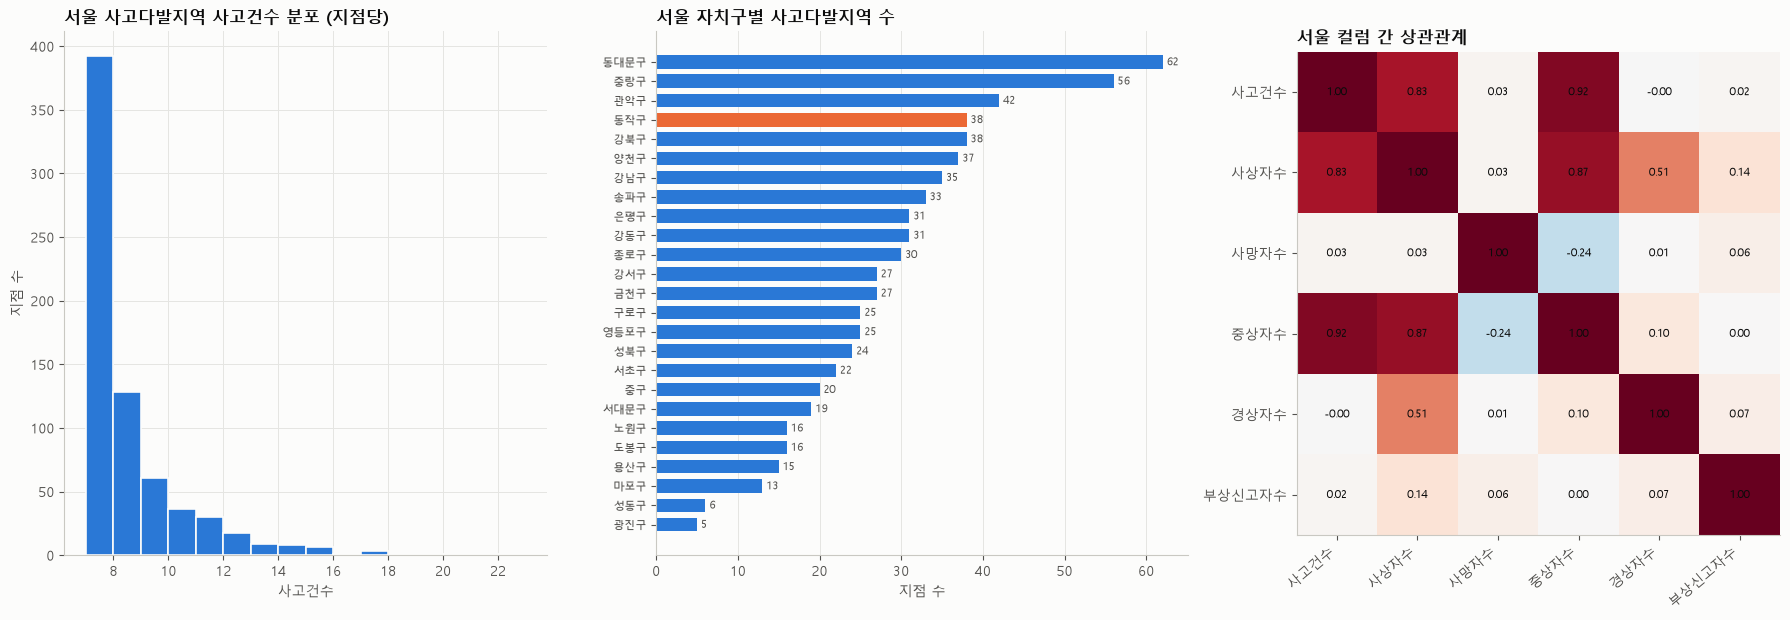

동작구 지점 수: 38 | 서울 25개 구 중 순위: 4


,지점명,사고건수,사상자수,사망자수,중상자수,경상자수,기준점까지_m
142,서울특별시 동작구 상도동(리치타운 부근),8,9,1,7,1,473.0
714,서울 동작구 상도동(상도1동주민센터 부근),7,7,1,6,0,514.0
1177,서울 동작구 상도동(구립로야어린이집 부근),8,8,1,7,0,540.0


In [14]:
gu = acc_seoul['자치구'].value_counts()
fig, axes = plt.subplots(1, 3, figsize=(18, 6.2), gridspec_kw={'width_ratios': [1, 1.1, 1]})

axes[0].hist(acc_seoul['사고건수'], bins=range(int(acc_seoul['사고건수'].min()), int(acc_seoul['사고건수'].max()) + 2), color=BLUE, edgecolor=SURFACE, linewidth=1.2)
axes[0].set_title('서울 사고다발지역 사고건수 분포 (지점당)'); axes[0].set_xlabel('사고건수'); axes[0].set_ylabel('지점 수')

barh_highlight(axes[1], gu, title='서울 자치구별 사고다발지역 수', xlabel='지점 수')
axes[1].tick_params(axis='y', labelsize=8)

corr = acc_seoul[acc_cols].corr()
im = axes[2].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_xticks(range(len(acc_cols))); axes[2].set_yticks(range(len(acc_cols)))
axes[2].set_xticklabels(acc_cols, rotation=40, ha='right'); axes[2].set_yticklabels(acc_cols)
for i in range(len(acc_cols)):
    for j in range(len(acc_cols)):
        axes[2].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8, color=INK)
axes[2].grid(False); axes[2].set_title('서울 컬럼 간 상관관계')
plt.tight_layout(); plt.show()

print('동작구 지점 수:', int(gu.get('동작구', 0)), f'| 서울 {len(gu)}개 구 중 순위:', int(gu.rank(ascending=False, method="min")['동작구']))
near = acc_g[acc_g.geometry.within(circle)].copy()
near['기준점까지_m'] = near.geometry.distance(center).round(0)
display(near[['지점명', '사고건수', '사상자수', '사망자수', '중상자수', '경상자수', '기준점까지_m']].sort_values('기준점까지_m'))

#### 3-1-1. 전국 사고다발지역 폴리곤과 결과 프로필

숭실대 반경 조건을 적용하지 않고, 전국 사고다발지역 전체를 하나의 분석 범위로 사용한다. 각 폴리곤을 사고 지점 단위로 보고, 사고·부상 컬럼을 공간의 결과 프로필로 변환한다.

In [58]:
import json
from shapely.geometry import shape

# 사고다발지역 폴리곤을 실제 분석 단위로 사용한다 (전국 2,402개 전체)
acc_poly = acc.copy()
acc_poly['geometry'] = acc_poly['다발지역폴리곤'].apply(
    lambda x: shape(json.loads(x) if isinstance(x, str) else x)
)
acc_poly_g = gpd.GeoDataFrame(acc_poly, geometry='geometry', crs='EPSG:4326')

# 공간 계산용 면적은 EPSG:5186에서 계산한다
acc_poly_proj = acc_poly_g.to_crs('EPSG:5186')
acc_profile = acc_poly_g.copy()
acc_profile['폴리곤_유효'] = acc_profile.geometry.is_valid
acc_profile['폴리곤_면적_m2'] = acc_poly_proj.geometry.area.round(1).to_numpy()

# 사고·부상 컬럼을 지점별 결과 프로필로 변환한다
acc_profile['사고_발생_규모'] = acc_profile['사고건수']
acc_profile['피해_규모'] = acc_profile['사상자수']
acc_profile['중대도_사망자수'] = acc_profile['사망자수']
acc_profile['중대도_중상자수'] = acc_profile['중상자수']
acc_profile['사고당_사상자수'] = acc_profile['사상자수'].div(acc_profile['사고건수']).round(3)
acc_profile['사고건수_대비_사상자수'] = acc_profile['사고당_사상자수']
acc_profile['사망자_비율'] = acc_profile['사망자수'].div(acc_profile['사상자수']).fillna(0).round(3)
acc_profile['중상자_비율'] = acc_profile['중상자수'].div(acc_profile['사상자수']).fillna(0).round(3)
acc_profile['경상자_비율'] = acc_profile['경상자수'].div(acc_profile['사상자수']).fillna(0).round(3)
acc_profile['부상신고자_비율'] = acc_profile['부상신고자수'].div(acc_profile['사상자수']).fillna(0).round(3)
acc_profile['사망자_발생'] = (acc_profile['사망자수'] > 0).astype(int)

print(f'전국 분석 범위: {len(acc_profile):,}개 사고다발지역 | 폴리곤 유효: {acc_profile["폴리곤_유효"].mean() * 100:.1f}%')
print('사고당 사상자수·부상 유형 비율을 추가한 결과 프로필')
display(acc_profile[['지점명', '시도시군구명', '사고_발생_규모', '피해_규모', '중대도_사망자수', '중대도_중상자수', '사망자_비율', '중상자_비율', '경상자_비율', '부상신고자_비율', '사고건수_대비_사상자수', '폴리곤_면적_m2']].head(10))

전국 분석 범위: 2,402개 사고다발지역 | 폴리곤 유효: 100.0%
사고당 사상자수·부상 유형 비율을 추가한 결과 프로필


,지점명,시도시군구명,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수,폴리곤_면적_m2
0,서울특별시 종로구 명륜2가(성균관대입구교차로 부근),서울특별시 종로구1,9,10,1,9,0.100,0.900,0.000,0.000,1.111,19569.1
1,서울특별시 종로구 낙원동(낙원상가 부근),서울특별시 종로구2,8,8,0,8,0.000,1.000,0.000,0.000,1.000,19574.9
2,서울특별시 종로구 세종로(세종로180 부근),서울특별시 종로구3,7,8,0,8,0.000,1.000,0.000,0.000,1.143,19575.9
3,서울특별시 종로구 숭인동(신설동역6번출구 부근),서울특별시 종로구4,7,8,0,7,0.000,0.875,0.125,0.000,1.143,19573.2
4,서울특별시 종로구 종로2가(종로2가교차로 부근),서울특별시 종로구5,7,8,0,7,0.000,0.875,0.000,0.125,1.143,19575.9
5,서울특별시 종로구 숭인동(신설동역11번출구 부근),서울특별시 종로구6,7,7,0,7,0.000,1.000,0.000,0.000,1.000,19573.6
6,서울특별시 중구 만리동2가(용산구마포구 부근),서울특별시 중구1,9,9,1,8,0.111,0.889,0.000,0.000,1.000,19585.4
7,서울특별시 중구 남대문로5가(서울역91번출구 부근),서울특별시 중구2,8,10,0,9,0.000,0.900,0.000,0.100,1.250,19583.6
8,서울특별시 중구 신당동(약수역앞교차로 부근),서울특별시 중구3,8,9,0,9,0.000,1.000,0.000,0.000,1.125,19583.7
9,서울특별시 중구 황학동(신당역서울6호선 부근),서울특별시 중구4,8,8,0,8,0.000,1.000,0.000,0.000,1.000,19578.1


### 3-2. 서울시 경사도

경사도 자체가 아니라 **등고선(선)과 표고점(점)** 이 들어 있는 배경 자료다. 숭실대 보행망의 각 엣지 경사는 양 끝 노드 높이를 등고선·표고점으로 보간해서 (높이차 ÷ 엣지 길이)로 계산한다.

In [59]:
import pyogrio
from scipy.interpolate import griddata

SLOPE_DIR = PROJECT_DIR / '서울시_경사도'
CONTOUR = SLOPE_DIR / '등고선 5000' / 'N3L_F001.shp'
SPOT = SLOPE_DIR / '표고 5000' / 'N3P_F002.shp'
for nm, p in [('등고선', CONTOUR), ('표고점', SPOT)]:
    info = pyogrio.read_info(p)
    print(f"{nm}: 피처 {info['features']:,}개 | CRS {info['crs']} | 필드 {list(info['fields'])}")

spot_all = gpd.read_file(SPOT)
print('\n서울 전체 표고점 HEIGHT(m):', spot_all['HEIGHT'].describe().round(1).to_dict())

def read_around(path, buffer_m=300):
    crs = pyogrio.read_info(path)['crs']
    b = gpd.GeoSeries([circle.buffer(buffer_m)], crs=PROJ).to_crs(crs).total_bounds
    return gpd.read_file(path, bbox=tuple(b)).to_crs(PROJ)

contours, spots = read_around(CONTOUR), read_around(SPOT)
levels = np.sort(contours['HEIGHT'].unique())
print(f'\n숭실대 주변(원+300m) 등고선 {len(contours)}개, 표고점 {len(spots)}개')
print('등고선 높이 간격(m):', np.unique(np.diff(levels)).tolist(), '| 높이 범위:', levels.min(), '~', levels.max(), 'm')

등고선: 피처 13,704개 | CRS EPSG:5174 | 필드 ['UFID', 'DIVI', 'CONT', 'SCLS', 'FMTA', 'HEIGHT', 'SHAPE_LEN']
표고점: 피처 76,580개 | CRS EPSG:5174 | 필드 ['UFID', 'NUME', 'SCLS', 'FMTA', 'HEIGHT']

서울 전체 표고점 HEIGHT(m): {'count': 76580.0, 'mean': 50.7, 'std': 75.2, 'min': -1.7, '25%': 17.0, '50%': 29.5, '75%': 52.1, 'max': 835.6}

숭실대 주변(원+300m) 등고선 170개, 표고점 355개
등고선 높이 간격(m): [5.0] | 높이 범위: 15.0 ~ 170.0 m


In [60]:
# 숭실대 엣지 경사 계산: 노드 높이 = 등고선 정점 + 표고점으로 선형 보간(볼록껍질 밖은 최근접값)
xs, ys, hs = [], [], []
for g, h in zip(contours.geometry, contours['HEIGHT']):
    for line in (g.geoms if g.geom_type.startswith('Multi') else [g]):
        for x, y, *_ in line.coords:
            xs.append(x); ys.append(y); hs.append(h)
for g, h in zip(spots.geometry, spots['HEIGHT']):
    xs.append(g.x); ys.append(g.y); hs.append(h)

# 2단계 산출물은 EPSG:4326으로 저장돼 있으므로, 높이 보간·길이·경사 계산을 위해 5186으로 바꾼다
net_nodes = gpd.read_file(DATA_DIR / 'soongsil_network.gpkg', layer='nodes').to_crs(PROJ)
net_edges = gpd.read_file(DATA_DIR / 'soongsil_network.gpkg', layer='edges').to_crs(PROJ)
px, py = net_nodes.geometry.x.values, net_nodes.geometry.y.values
elev = griddata((xs, ys), hs, (px, py), method='linear')
miss = np.isnan(elev)
elev[miss] = griddata((xs, ys), hs, (px[miss], py[miss]), method='nearest')
net_nodes['elev_m'] = elev
elev_of = dict(zip(net_nodes['node'], net_nodes['elev_m']))

ed = net_edges[(net_edges['highway'] != 'gate_connector') & (net_edges['원_안'].astype(bool))].copy()
ed['length_m'] = ed.geometry.length
ed['dh_m'] = (pd.to_numeric(ed['u'], errors='coerce').map(elev_of) - pd.to_numeric(ed['v'], errors='coerce').map(elev_of)).abs()
ed['slope_pct'] = ed['dh_m'] / ed['length_m'] * 100
ed = ed.dropna(subset=['slope_pct'])

print(f"노드 높이 추정: 최저 {net_nodes['elev_m'].min():.0f}m ~ 최고 {net_nodes['elev_m'].max():.0f}m | 볼록껍질 밖이라 최근접값으로 채운 노드 {int(miss.sum())}개")
print(f"서울 표고점 중 숭실대 노드 중앙 높이({net_nodes['elev_m'].median():.0f}m)보다 낮은 비율: {(spot_all['HEIGHT'] < net_nodes['elev_m'].median()).mean() * 100:.0f}%")

long_ed = ed[ed['length_m'] >= 20]  # 짧은 엣지는 높이 보간 오차가 경사에 크게 반영됨
w = long_ed['length_m']
def share(th): return (w[long_ed['slope_pct'] > th].sum() / w.sum() * 100)
print(f"\n원 안 엣지 {len(ed)}개 중 길이 20m 이상 {len(long_ed)}개 (길이 가중)")
print(f"경사도(%) 중앙값 {long_ed['slope_pct'].median():.1f}, 90분위 {long_ed['slope_pct'].quantile(.9):.1f}, 최대 {long_ed['slope_pct'].max():.1f}")
print(f"경사 5% 초과 {share(5):.0f}% | 8.3%(1/12) 초과 {share(100 / 12):.0f}% | 10% 초과 {share(10):.0f}%  (엣지 길이 기준)")

노드 높이 추정: 최저 25m ~ 최고 171m | 볼록껍질 밖이라 최근접값으로 채운 노드 0개
서울 표고점 중 숭실대 노드 중앙 높이(73m)보다 낮은 비율: 84%

원 안 엣지 587개 중 길이 20m 이상 424개 (길이 가중)
경사도(%) 중앙값 5.9, 90분위 14.3, 최대 36.1
경사 5% 초과 55% | 8.3%(1/12) 초과 33% | 10% 초과 23%  (엣지 길이 기준)


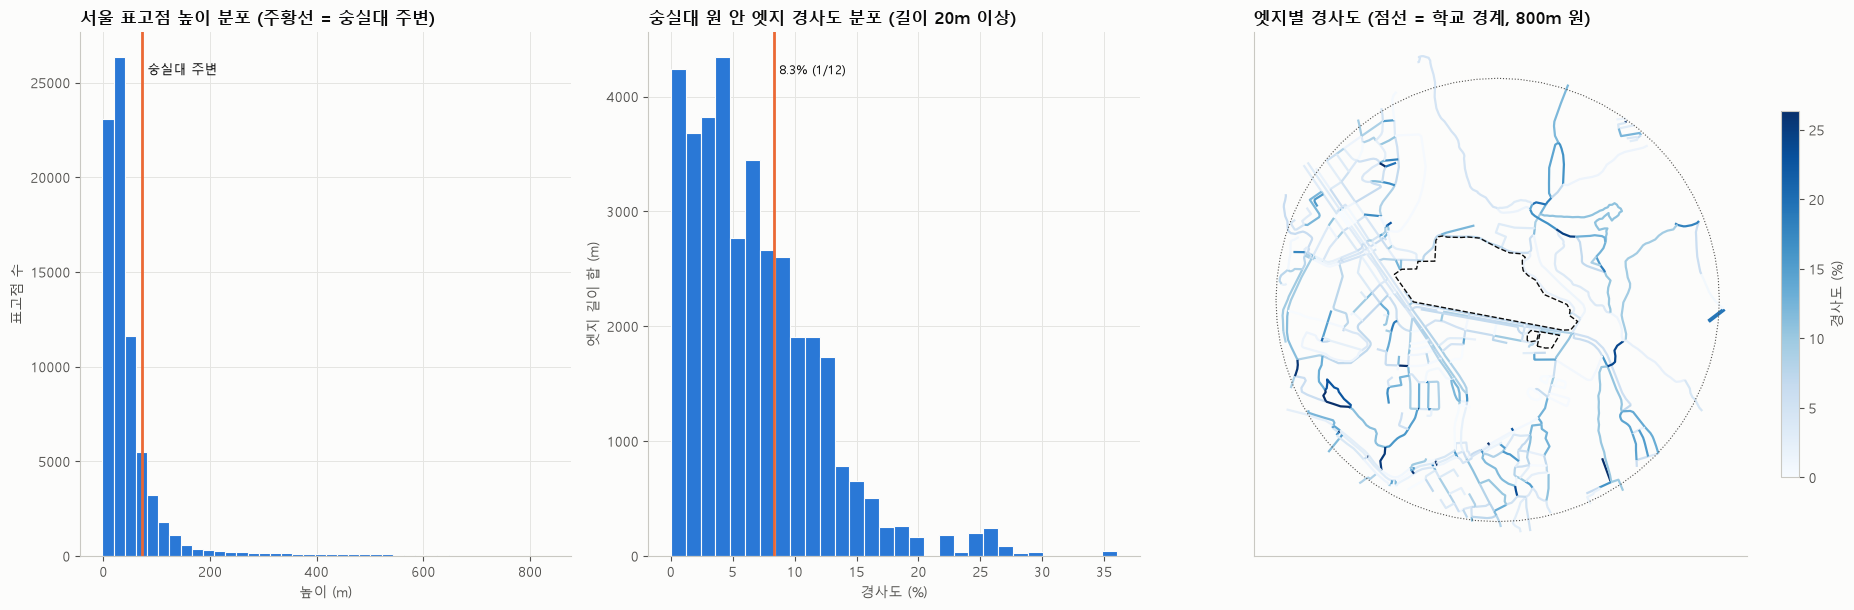

,엣지수,경사_중앙값,경사_90분위
highway,,,
service,206,5.6,15.4
footway,124,5.1,15.9
residential,116,6.7,14.4
primary,53,6.2,10.7
tertiary,44,4.1,10.4
path,32,9.9,23.9
steps,4,19.2,25.2
"['steps', 'path']",3,10.3,17.9


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.2), gridspec_kw={'width_ratios': [1, 1, 1.35]})

axes[0].hist(spot_all['HEIGHT'], bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.8)
axes[0].axvline(net_nodes['elev_m'].median(), color=ORANGE, linewidth=2)
axes[0].text(net_nodes['elev_m'].median(), axes[0].get_ylim()[1] * 0.92, ' 숭실대 주변', color=INK, fontsize=9)
axes[0].set_title('서울 표고점 높이 분포 (주황선 = 숭실대 주변)'); axes[0].set_xlabel('높이 (m)'); axes[0].set_ylabel('표고점 수')

axes[1].hist(long_ed['slope_pct'], bins=30, weights=long_ed['length_m'], color=BLUE, edgecolor=SURFACE, linewidth=0.8)
axes[1].axvline(100 / 12, color=ORANGE, linewidth=2)
axes[1].text(100 / 12, axes[1].get_ylim()[1] * 0.92, ' 8.3% (1/12)', color=INK, fontsize=9)
axes[1].set_title('숭실대 원 안 엣지 경사도 분포 (길이 20m 이상)'); axes[1].set_xlabel('경사도 (%)'); axes[1].set_ylabel('엣지 길이 합 (m)')

ed.plot(ax=axes[2], column='slope_pct', cmap='Blues', linewidth=1.6, vmin=0, vmax=ed['slope_pct'].quantile(.98), legend=True,
        legend_kwds={'label': '경사도 (%)', 'shrink': 0.7}, missing_kwds={'color': '#cccccc'})
gpd.GeoSeries([campus]).boundary.plot(ax=axes[2], color=INK, linewidth=1, linestyle='--')
gpd.GeoSeries([circle]).boundary.plot(ax=axes[2], color=MUTED, linewidth=0.8, linestyle=':')
axes[2].set_title('엣지별 경사도 (점선 = 학교 경계, 800m 원)'); axes[2].set_aspect('equal'); axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].grid(False)
plt.tight_layout(); plt.show()

display(ed.groupby('highway').agg(엣지수=('slope_pct', 'size'), 경사_중앙값=('slope_pct', 'median'), 경사_90분위=('slope_pct', lambda s: s.quantile(.9))).round(1).sort_values('엣지수', ascending=False).head(8))

### 3-3. 교차로·횡단보도

엑셀 파일을 CSV로 변환한 데이터다. 횡단보도 한 개가 한 행이고, 교차로 관리번호로 묶인다. `보행등유무`는 그 횡단보도에 보행자 신호등이 있는지를 뜻한다.

21,776행 | 자치구 25개 | 교차로 7,592개 | 교차로당 횡단보도 평균 2.9개
결측: {'X좌표': 1, 'Y좌표': 1} | 횡단보도관리번호 중복: 0

숭실대 800m 안: 횡단보도 69개, 교차로 27개


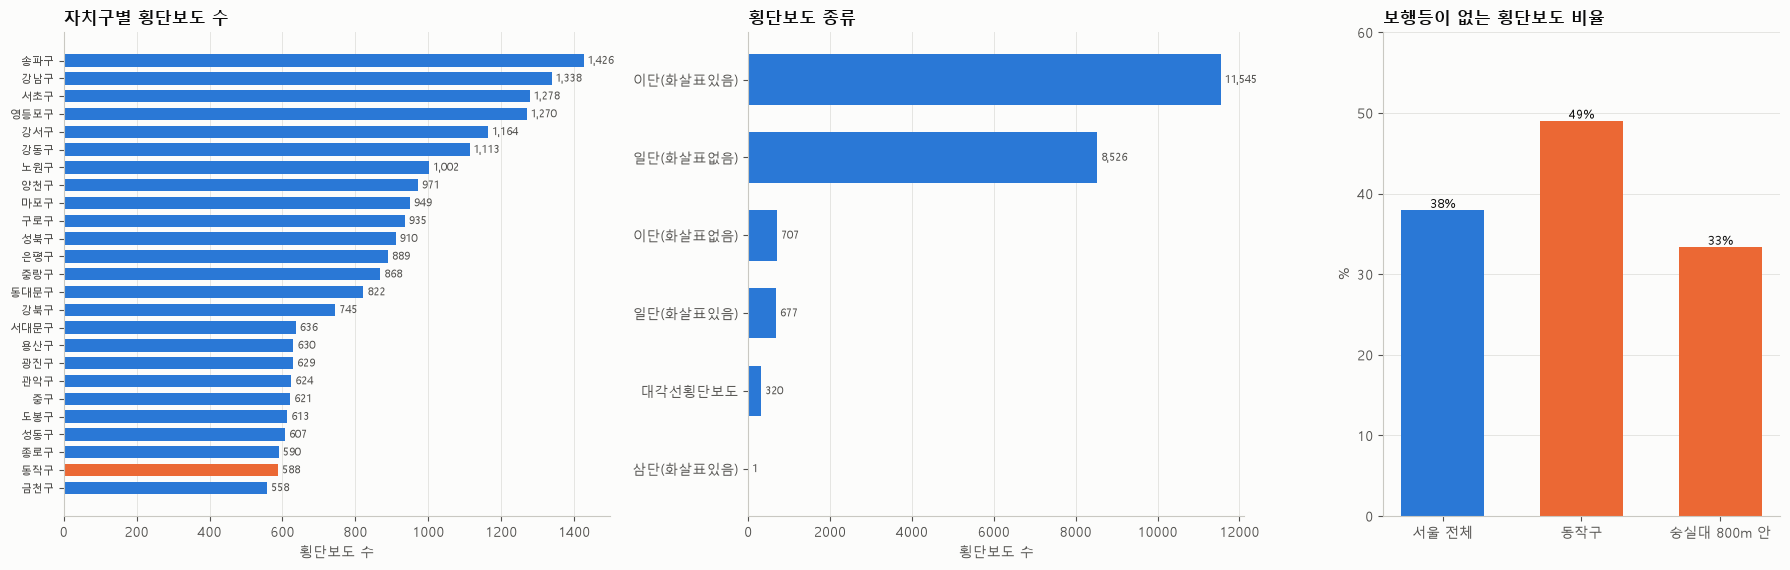

종류 코드(일단/이단/화살표 등)의 정확한 의미는 코드표 확인 필요


,자치구,횡단보도종류,보행등유무,개수
0,동작구,이단(화살표있음),유,24
1,동작구,일단(화살표없음),무,15
2,관악구,이단(화살표있음),유,9
3,동작구,일단(화살표없음),유,9
4,동작구,이단(화살표있음),무,5
5,관악구,일단(화살표없음),유,3
6,관악구,일단(화살표있음),무,1
7,관악구,이단(화살표있음),무,1


교차로·횡단보도 원본 데이터 미리보기 (상위 10행)


,연번,자치구,횡단보도관리번호,교차로관리번호,횡단보도종류,보행등유무,교차로명,X좌표,Y좌표
0,1,강남구,06-0000007287,5282,일단(화살표없음),무,한미은행양재,202870.870397,543092.856836
1,2,강남구,06-0000007538,1756,이단(화살표있음),유,싸리고개공원(연등)1,202924.986926,543395.671243
2,3,강남구,06-0000007539,1756,일단(화살표없음),무,싸리고개공원(연등)1,202951.244033,543420.333776
3,4,강남구,06-0000005695,2066,일단(화살표있음),유,선릉공원앞,204170.707704,545295.462984
4,5,강남구,06-0000009057,290,이단(화살표있음),유,강남세브란스,204141.977684,543833.013275
5,6,강남구,06-0000008077,5213,이단(화살표있음),무,학여울R(경보),206201.922760,544150.623840
6,7,강남구,06-0000047809,1980,이단(화살표있음),유,개포디에이치아너힐즈,206071.708744,542746.442510
7,8,강남구,06-0000005691,7819,일단(화살표없음),무,전기공제회관(연등),201812.581121,546029.358815
8,9,강남구,06-0000005032,8284,일단(화살표없음),무,역삼초교정문(경보),202868.297974,543636.256395
9,10,강남구,06-0000008336,1720,이단(화살표있음),유,강남세무서(연등)1,204230.266359,546548.629902


In [18]:
print(f'{len(cross):,}행 | 자치구 {cross["자치구"].nunique()}개 | 교차로 {cross["교차로관리번호"].nunique():,}개 | 교차로당 횡단보도 평균 {len(cross) / cross["교차로관리번호"].nunique():.1f}개')
print('결측:', cross.isna().sum()[lambda s: s > 0].to_dict(), '| 횡단보도관리번호 중복:', int(cross['횡단보도관리번호'].duplicated().sum()))

cross_g['원_안'] = cross_g.geometry.within(circle)
cross_g['동작구'] = cross_g['자치구'] == '동작구'
noled = lambda d: (d['보행등유무'] == '무').mean() * 100
scope = pd.Series({'서울 전체': noled(cross_g), '동작구': noled(cross_g[cross_g['동작구']]), '숭실대 800m 안': noled(cross_g[cross_g['원_안']])})
print(f"\n숭실대 800m 안: 횡단보도 {int(cross_g['원_안'].sum())}개, 교차로 {cross_g[cross_g['원_안']]['교차로관리번호'].nunique()}개")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), gridspec_kw={'width_ratios': [1.1, 1, 0.8]})
barh_highlight(axes[0], cross['자치구'].value_counts(), title='자치구별 횡단보도 수', xlabel='횡단보도 수')
axes[0].tick_params(axis='y', labelsize=8)
kinds = cross['횡단보도종류'].value_counts()
axes[1].barh(kinds.index[::-1], kinds.values[::-1], color=BLUE, height=0.65)
for y, v in enumerate(kinds.values[::-1]): axes[1].text(v, y, f' {v:,}', va='center', fontsize=8, color=MUTED)
axes[1].set_title('횡단보도 종류'); axes[1].set_xlabel('횡단보도 수'); axes[1].grid(axis='y', visible=False)
axes[2].bar(scope.index, scope.values, color=[BLUE, ORANGE, ORANGE], width=0.6)
for i, v in enumerate(scope.values): axes[2].text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontsize=9)
axes[2].set_title('보행등이 없는 횡단보도 비율'); axes[2].set_ylabel('%'); axes[2].set_ylim(0, 60); axes[2].grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

print('종류 코드(일단/이단/화살표 등)의 정확한 의미는 코드표 확인 필요')
display(cross_g[cross_g['원_안']][['자치구', '횡단보도종류', '보행등유무']].value_counts().rename('개수').reset_index().head(8))

print('교차로·횡단보도 원본 데이터 미리보기 (상위 10행)')
display(cross.head(10))

### 3-4. 음향신호기

결측 문제가 이 데이터의 핵심이다. **좌표가 없는 행**은 지도에 못 올리고, 나머지 결측 컬럼은 상태·설치 정보의 신뢰도를 좌우한다. 결측이 무작위인지 특정 조건에 몰려 있는지 먼저 본다.

21,451행 x 22열 | 좌표(XCE·YCE) 있는 행 16,847 (79%)


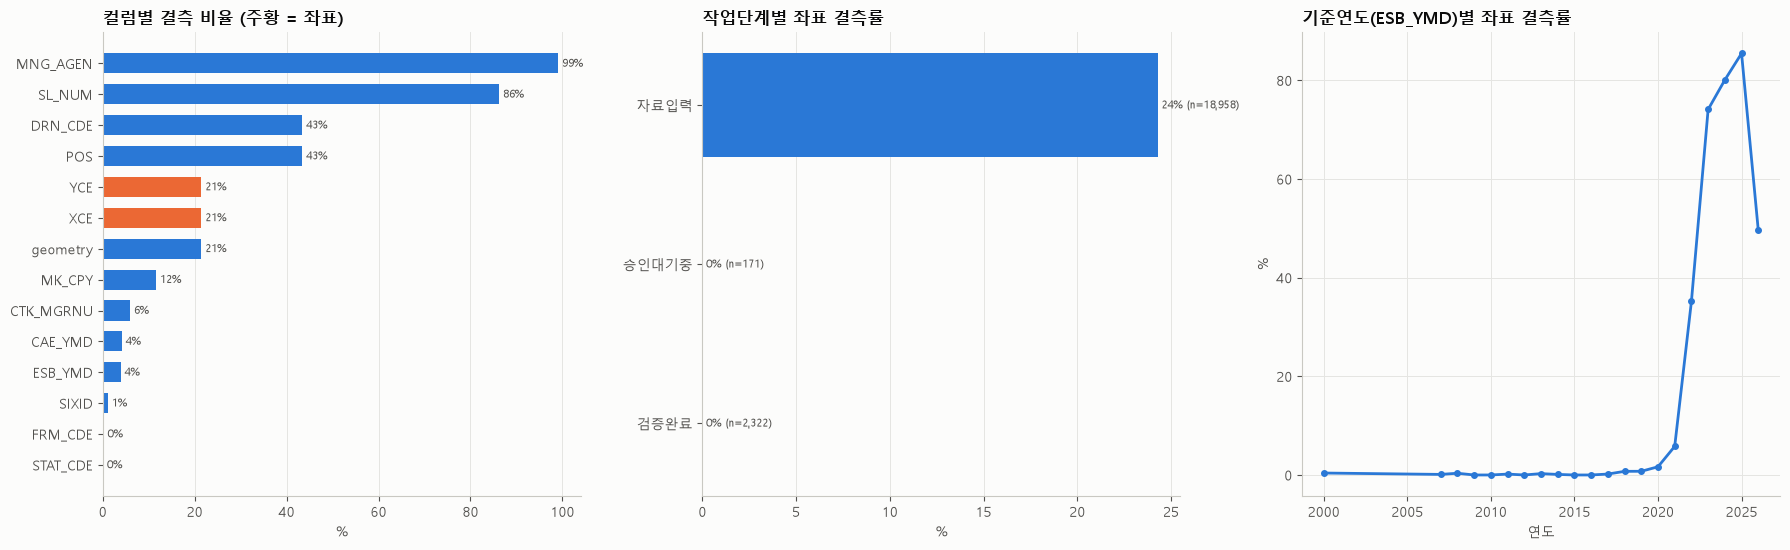

값이 하나뿐인 코드 컬럼 (좌표 유무와 무관하게 전체 행 기준)
  STAT_CDE 시설물 상태(1=양호): {1.0: 21426, nan: 25}
  VIEW_CDE 표출 구분(2=보기): {2: 21451}
  A073_KND_C 음향신호기 종류(1=버튼식): {1: 21451}

공사형태(FRM_CDE)와 작업단계(WORK_CDE) 분포


,공사형태,작업단계
검증완료,0,2322
교체,7765,0
도색,1951,0
미상,51,0
승인대기중,0,171
신설,11610,0
이설,42,0
자료입력,0,18958
재도색,32,0


In [19]:
miss = aud.isna().mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0]
print(f'{len(aud):,}행 x {aud.shape[1]}열 | 좌표(XCE·YCE) 있는 행 {len(aud_g):,} ({len(aud_g) / len(aud) * 100:.0f}%)')

# 코드표 (05 노트북에서 정리한 값)
status_map = {1: '양호', 2: '파손', 3: '도색', 4: '노후'}
work_map = {1: '자료입력', 2: '자료입력완료', 3: '승인대기중', 4: '부분완료', 5: '위치수정요망', 6: '검증완료', 7: '승인', 8: '경찰청승인',
            9: '시설물수정완료', 10: '내용수정요망', 11: '수정요망', 12: '센터입력중', 13: '중간저장', 14: '반려'}
aud['좌표결측'] = aud[['XCE', 'YCE']].isna().any(axis=1)
aud['작업단계'] = pd.to_numeric(aud['WORK_CDE'], errors='coerce').map(work_map).fillna('미상')
aud['기준연도'] = pd.to_numeric(aud['ESB_YMD'].astype(str).str[:4], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), gridspec_kw={'width_ratios': [1, 1, 1]})
axes[0].barh(miss.index[::-1], miss.values[::-1], color=[ORANGE if c in ('XCE', 'YCE') else BLUE for c in miss.index[::-1]], height=0.65)
for y, v in enumerate(miss.values[::-1]): axes[0].text(v, y, f' {v:.0f}%', va='center', fontsize=8, color=MUTED)
axes[0].set_title('컬럼별 결측 비율 (주황 = 좌표)'); axes[0].set_xlabel('%'); axes[0].grid(axis='y', visible=False)

by_work = aud.groupby('작업단계').agg(행수=('좌표결측', 'size'), 좌표결측률=('좌표결측', 'mean')).query('행수 >= 30').sort_values('좌표결측률')
by_work['좌표결측률'] *= 100
axes[1].barh(by_work.index, by_work['좌표결측률'], color=BLUE, height=0.65)
for y, (n, v) in enumerate(zip(by_work['행수'], by_work['좌표결측률'])): axes[1].text(v, y, f' {v:.0f}% (n={n:,})', va='center', fontsize=8, color=MUTED)
axes[1].set_title('작업단계별 좌표 결측률'); axes[1].set_xlabel('%'); axes[1].grid(axis='y', visible=False)

by_year = aud.groupby('기준연도')['좌표결측'].agg(['size', 'mean']).query('size >= 50')
axes[2].plot(by_year.index, by_year['mean'] * 100, color=BLUE, linewidth=2, marker='o', markersize=4)
axes[2].set_title('기준연도(ESB_YMD)별 좌표 결측률'); axes[2].set_xlabel('연도'); axes[2].set_ylabel('%')
plt.tight_layout(); plt.show()

print('값이 하나뿐인 코드 컬럼 (좌표 유무와 무관하게 전체 행 기준)')
for c, nm in [('STAT_CDE', '시설물 상태(1=양호)'), ('VIEW_CDE', '표출 구분(2=보기)'), ('A073_KND_C', '음향신호기 종류(1=버튼식)')]:
    print(f'  {c} {nm}:', aud[c].value_counts(dropna=False).to_dict())
construction_map = {1: '신설', 2: '교체', 3: '제거', 4: '도색', 5: '재도색', 6: '이설'}
print()
print('공사형태(FRM_CDE)와 작업단계(WORK_CDE) 분포')
display(pd.DataFrame({'공사형태': pd.to_numeric(aud['FRM_CDE'], errors='coerce').map(construction_map).fillna('미상').value_counts(),
                      '작업단계': aud['작업단계'].value_counts()}).fillna(0).astype(int))

#### 3-4-1. 음향신호기와 횡단보도의 좌표 정합

횡단보도마다 **가장 가까운 음향신호기까지의 거리**를 서울 전체에서 계산한다. 가까운 것이 곧 한 쌍은 아니지만, 짝짓기 기준 거리를 정하는 근거가 된다. 좌표가 없는 음향신호기(21%)는 빠져 있어서, 실제보다 멀게 나오는 쪽으로 치우친다.

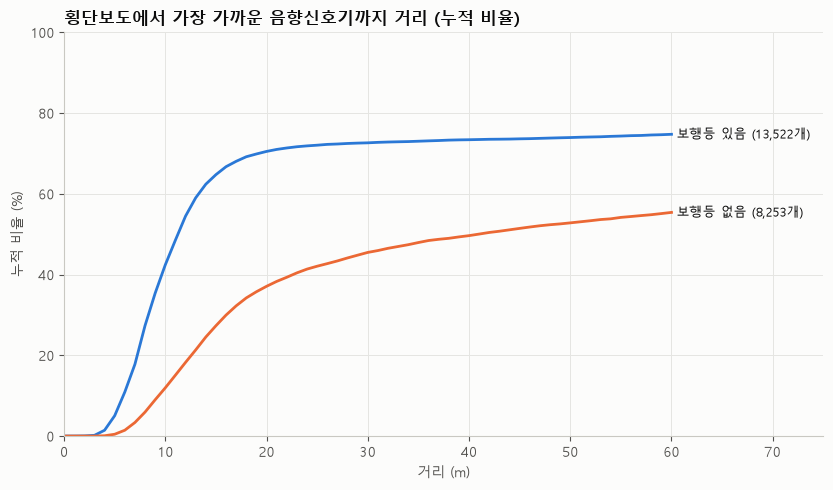

보행등 유무별 근접도


,중앙값_m,10m 이내(%),15m 이내(%),30m 이내(%)
보행등유무,,,,
무,40.9,11.9,27.3,45.5
유,11.2,42.4,64.7,72.6


숭실대 800m 안 횡단보도 69개: 15m 이내 음향신호기 40개 (58%), 30m 이내 50개


In [20]:
from scipy.spatial import cKDTree

tree = cKDTree(np.c_[aud_g.geometry.x, aud_g.geometry.y])
cross_g['음향신호기_최근접_m'], _ = tree.query(np.c_[cross_g.geometry.x, cross_g.geometry.y])

ths = np.arange(0, 61, 1)
fig, ax = plt.subplots(figsize=(8.5, 5))
for name, color in [('유', BLUE), ('무', ORANGE)]:
    d = cross_g.loc[cross_g['보행등유무'] == name, '음향신호기_최근접_m']
    y = [(d <= t).mean() * 100 for t in ths]
    ax.plot(ths, y, color=color, linewidth=2)
    ax.text(60.5, y[-1], f'보행등 {"있음" if name == "유" else "없음"} ({len(d):,}개)', va='center', fontsize=9, color=INK)
ax.set_xlim(0, 75); ax.set_ylim(0, 100)
ax.set_title('횡단보도에서 가장 가까운 음향신호기까지 거리 (누적 비율)'); ax.set_xlabel('거리 (m)'); ax.set_ylabel('누적 비율 (%)')
plt.tight_layout(); plt.show()

tab = cross_g.groupby('보행등유무')['음향신호기_최근접_m'].agg(
    중앙값_m='median', **{'10m 이내(%)': lambda s: (s <= 10).mean() * 100, '15m 이내(%)': lambda s: (s <= 15).mean() * 100, '30m 이내(%)': lambda s: (s <= 30).mean() * 100}).round(1)
print('보행등 유무별 근접도'); display(tab)
inn = cross_g[cross_g['원_안']]
print(f"숭실대 800m 안 횡단보도 {len(inn)}개: 15m 이내 음향신호기 {(inn['음향신호기_최근접_m'] <= 15).sum()}개 ({(inn['음향신호기_최근접_m'] <= 15).mean() * 100:.0f}%), 30m 이내 {(inn['음향신호기_최근접_m'] <= 30).sum()}개")

### 3-5. 장애인편의시설

건물(시설)별로 장애인 편의시설을 갖췄는지 기록한 목록이다. 시설 자체의 종류(시설유형)를 보고, 시각장애인 보행과 관련 있는 종류가 얼마나 되는지 가늠한다.

29,153행 | 컬럼: ['설립일자', '순번', '시설위도', '시설경도', '시설명', '시설유형', '시설기본주소', '영업상태구분코드', '영업상태구분명', '복지로관리시설구분코드', '시설ID']
위경도가 서울 범위 밖·결측이라 제외된 행: 5,078개 (17.4%)
영업상태: {'영업': 29153}


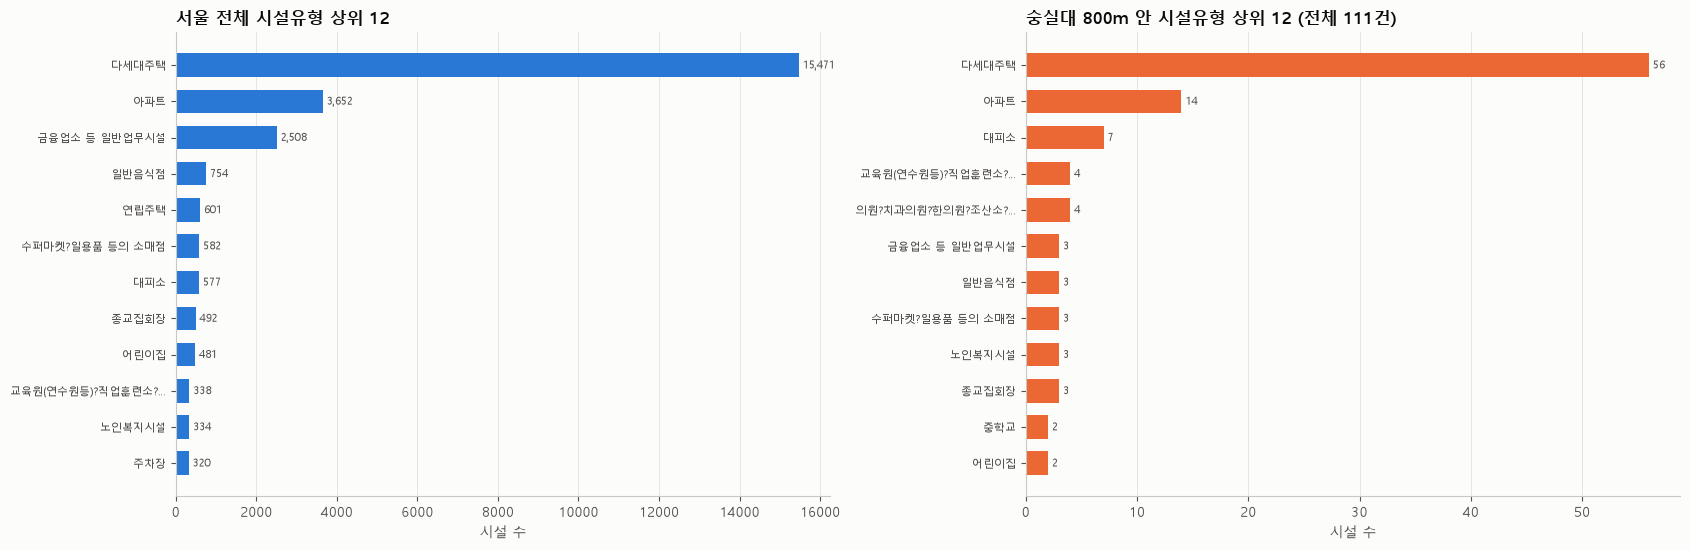

숭실대 800m 안 시설 중 주거 건물 비율: 64%


In [21]:
print(f'{len(fac):,}행 | 컬럼: {[c for c in fac.columns if c != "시설대표자성명"]}')
print(f'위경도가 서울 범위 밖·결측이라 제외된 행: {len(fac) - len(fac_ok):,}개 ({(1 - len(fac_ok) / len(fac)) * 100:.1f}%)')
print('영업상태:', fac['영업상태구분명'].value_counts(dropna=False).head(5).to_dict())

fac_g['원_안'] = fac_g.geometry.within(circle)
short = lambda s: (s[:16] + '…') if len(s) > 17 else s
top_all = fac['시설유형'].value_counts().head(12)
top_in = fac_g[fac_g['원_안']]['시설유형'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.6))
for ax, s, title, color in [(axes[0], top_all, '서울 전체 시설유형 상위 12', BLUE), (axes[1], top_in, f'숭실대 800m 안 시설유형 상위 12 (전체 {int(fac_g["원_안"].sum())}건)', ORANGE)]:
    s = s[::-1]
    ax.barh([short(i) for i in s.index], s.values, color=color, height=0.65)
    for y, v in enumerate(s.values): ax.text(v, y, f' {v:,}', va='center', fontsize=8, color=MUTED)
    ax.set_title(title); ax.set_xlabel('시설 수'); ax.grid(axis='y', visible=False); ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()
housing = fac_g[fac_g['원_안']]['시설유형'].isin(['다세대주택', '아파트', '연립주택', '단독주택', '다가구주택']).mean() * 100
print(f'숭실대 800m 안 시설 중 주거 건물 비율: {housing:.0f}%')

### 3-6. 서울시 시각장애인 현황

2025년 등록장애인 수를 장애유형·성별로 나눈 표다. 머리글이 4행이라 먼저 한 표로 풀어서 본다. 파일 이름은 "동별"이지만 **행은 서울 합계와 25개 자치구뿐**이라, 숭실대가 속한 동작구까지가 가장 세밀한 단위다. 인구 자료가 아니라 **등록 장애인 수**라서 비율은 "전체 등록장애인 중 시각장애인 비율"이다.

서울 등록장애인 384,934명 | 시각장애 40,062명 (10.4%) | 유형 16개, 행 25개 자치구
동작구: 시각장애 1,427명 (25개 구 중 16위), 전체 등록장애인 중 10.3% (16위)


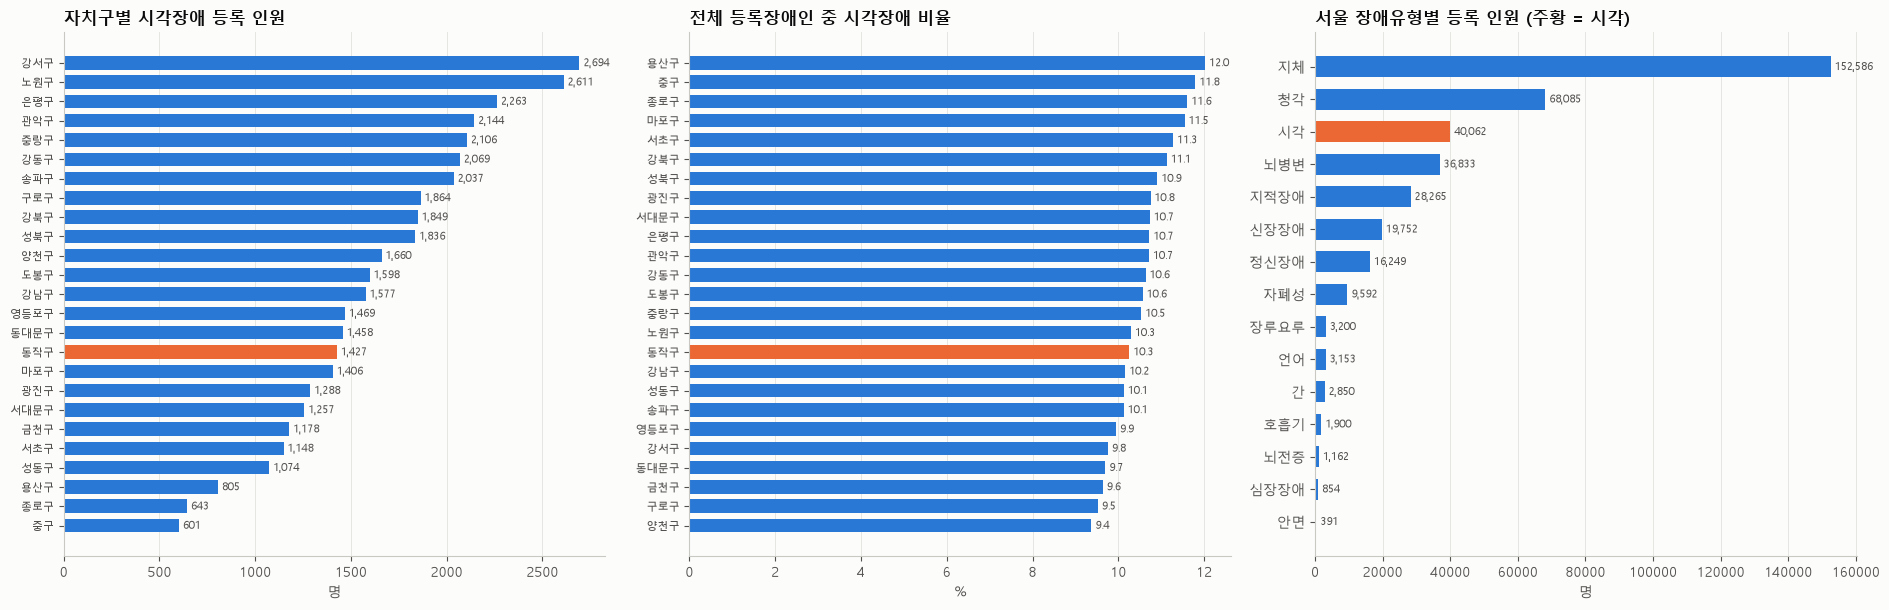

In [22]:
types = disab_raw.iloc[2, 2:].tolist(); sex = disab_raw.iloc[3, 2:].tolist()
body = disab_raw.iloc[4:].copy()
body.columns = ['광역', '자치구'] + [f'{t}|{s}' for t, s in zip(types, sex)]
for c in body.columns[2:]:
    body[c] = pd.to_numeric(body[c], errors='coerce')
seoul_total = body[body['자치구'] == '소계'].iloc[0]
gu_df = body[body['자치구'] != '소계'].set_index('자치구')

print(f'서울 등록장애인 {int(seoul_total["소계|계"]):,}명 | 시각장애 {int(seoul_total["시각|계"]):,}명 ({seoul_total["시각|계"] / seoul_total["소계|계"] * 100:.1f}%) | 유형 {len(set(types))}개, 행 {len(gu_df)}개 자치구')
vis = gu_df['시각|계']; ratio = (gu_df['시각|계'] / gu_df['소계|계'] * 100)
print(f'동작구: 시각장애 {int(vis["동작구"]):,}명 (25개 구 중 {int(vis.rank(ascending=False)["동작구"])}위), 전체 등록장애인 중 {ratio["동작구"]:.1f}% ({int(ratio.rank(ascending=False)["동작구"])}위)')

fig, axes = plt.subplots(1, 3, figsize=(19, 6.2), gridspec_kw={'width_ratios': [1, 1, 1]})
barh_highlight(axes[0], vis, title='자치구별 시각장애 등록 인원', xlabel='명')
barh_highlight(axes[1], ratio, title='전체 등록장애인 중 시각장애 비율', xlabel='%', fmt='{:.1f}')
tp = pd.Series({t: seoul_total[f'{t}|계'] for t in dict.fromkeys(types) if t != '소계'}).sort_values()
axes[2].barh(tp.index, tp.values, color=[ORANGE if t == '시각' else BLUE for t in tp.index], height=0.65)
for y, v in enumerate(tp.values): axes[2].text(v, y, f' {int(v):,}', va='center', fontsize=8, color=MUTED)
axes[2].set_title('서울 장애유형별 등록 인원 (주황 = 시각)'); axes[2].set_xlabel('명'); axes[2].grid(axis='y', visible=False)
for ax in axes[:2]: ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

### 3-8. 교통약자 다발지점 (보행자)

2024년 기준 3년간의 자료다. 지점명·발생건수·사망자수만 있는 표다. 좌표와 장애 유형 컬럼이 없어서 **시각장애인만 골라낼 수 없고**, 숭실대 엣지에 직접 겹치려면 지점명을 좌표로 바꾸는 작업이 따로 필요하다.

750행 | 자치구 25개, 구별 행 수: [30] | 발생건수 합 5,068, 사망자수 합 106
결측 컬럼: {'보 기': 750} | 값이 모두 0인 컬럼: ['WALK_CNT']
(구, 지점명) 중복 행: 15 | 지점명에 '방향 ~M' 표기가 있는 비율 47%


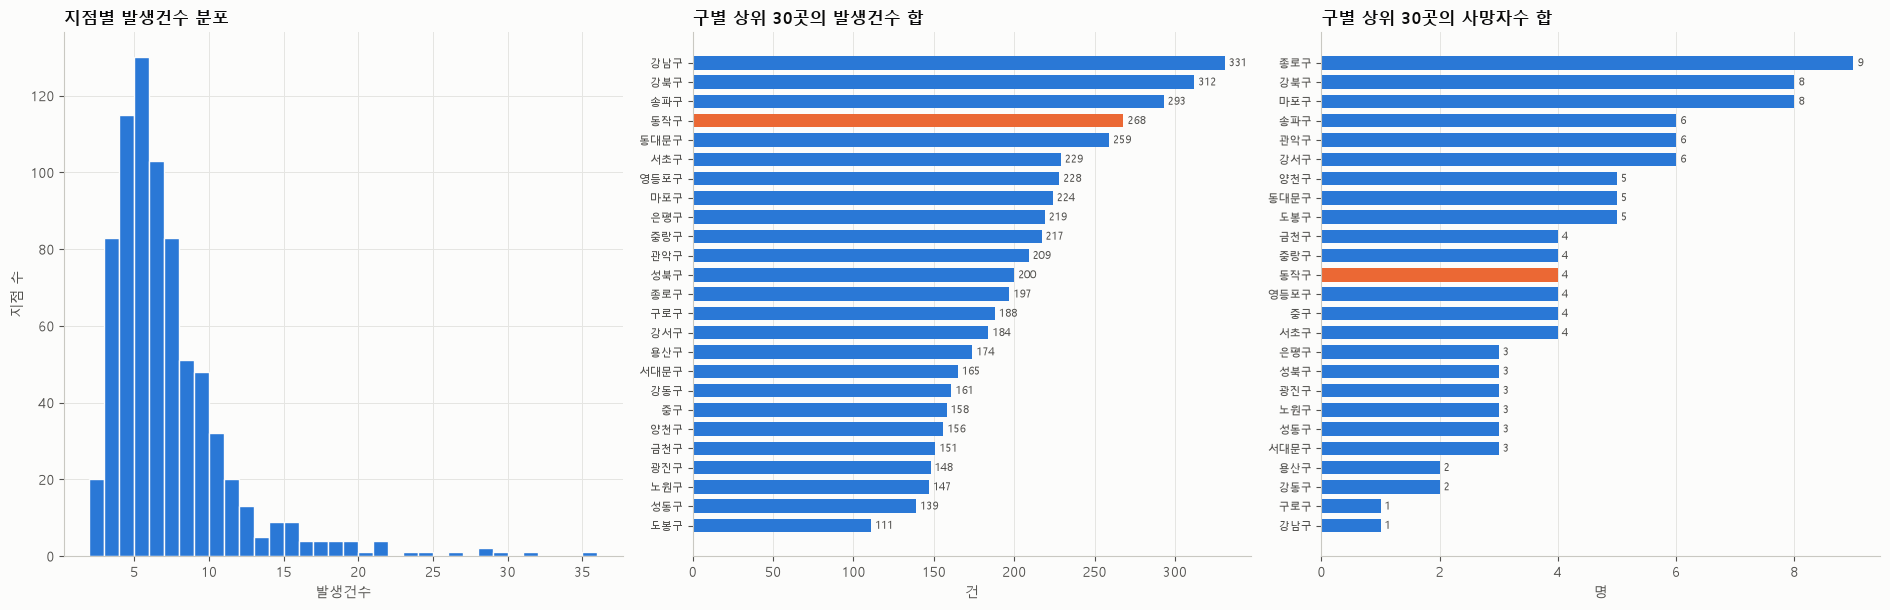

구마다 30행씩이라 구별 합계는 "각 구의 상위 30곳" 기준이다. 전체 다발지점의 구별 비교가 아니다.


,지점명,발생건수,사망자수
332,상도3동주민센터,19,0
330,성대약국,18,0
358,성대약국,18,0
336,중앙학원(남방향 121M),15,0
331,총신대입구역(서울4호선)(서방향 104M),14,0
333,명수대상가,13,0
334,신대방동빌딩,11,0
335,장승배기사거리(북방향 257M),10,1


In [23]:
print(f'{len(vul)}행 | 자치구 {vul["지자체_기초"].nunique()}개, 구별 행 수: {[int(x) for x in sorted(vul["지자체_기초"].value_counts().unique())]} | 발생건수 합 {int(vul["발생건수"].sum()):,}, 사망자수 합 {int(vul["사망자수"].sum())}')
print('결측 컬럼:', vul.isna().sum()[lambda s: s > 0].to_dict(), '| 값이 모두 0인 컬럼:', [c for c in ['MOTOCY_CNT', 'CYCLE_CNT', 'WALK_CNT', 'DRK'] if vul[c].sum() == 0])
print(f"(구, 지점명) 중복 행: {int(vul.duplicated(['지자체_기초', '지점명']).sum())} | 지점명에 '방향 ~M' 표기가 있는 비율 {vul['지점명'].str.contains(r'방향\s*\d+M').mean() * 100:.0f}%")

fig, axes = plt.subplots(1, 3, figsize=(19, 6.2), gridspec_kw={'width_ratios': [1, 1, 1]})
axes[0].hist(vul['발생건수'], bins=range(2, int(vul['발생건수'].max()) + 2), color=BLUE, edgecolor=SURFACE, linewidth=1)
axes[0].set_title('지점별 발생건수 분포'); axes[0].set_xlabel('발생건수'); axes[0].set_ylabel('지점 수')
barh_highlight(axes[1], vul.groupby('지자체_기초')['발생건수'].sum(), title='구별 상위 30곳의 발생건수 합', xlabel='건')
barh_highlight(axes[2], vul.groupby('지자체_기초')['사망자수'].sum(), title='구별 상위 30곳의 사망자수 합', xlabel='명')
for ax in axes[1:]: ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

print('구마다 30행씩이라 구별 합계는 "각 구의 상위 30곳" 기준이다. 전체 다발지점의 구별 비교가 아니다.')
display(vul[vul['지자체_기초'] == '동작구'].sort_values('발생건수', ascending=False)[['지점명', '발생건수', '사망자수']].head(8))

print('교통약자 다발지점 원본 데이터 미리보기 (상위 10행)')
display(vul.head(10))

### 3단계 데이터 EDA 요약

#### 데이터별 확인 결과

**3-1. 보행자 사고다발지역**
- 서울 자료가 아니라 **전국 자료**다(2,402곳 중 서울 693곳). 서울만 떼어 봐야 한다.
- 사고건수가 모든 지점에서 7건 이상이고, 서울 지점의 57%가 정확히 7건이다. 사고 7건 이상인 곳만 다발지역으로 뽑은 자료로 보인다(선정 기준은 출처 문서 확인 필요).
- 사상자수는 사망·중상·경상·부상신고의 합과 100% 일치한다. 지표에 사상자수와 세부 항목을 같이 넣으면 중복 계산이 된다.
- 사고건수와 중상자수의 상관이 0.92로, 두 열이 거의 같은 정보를 담고 있다. 사망자수는 사고건수와 관계가 거의 없다(0.03).
- 동작구는 38곳으로 서울 25개 구 중 4위다. 숭실대 800m 안에는 3곳이고, 3곳 모두 사망자가 1명씩 있다.
- 사고 기간(연도) 정보가 파일에 없다.

**3-2. 서울시 경사도**
- 경사도가 아니라 **등고선(5m 간격)과 표고점**이고, 좌표계가 EPSG:5174로 다른 데이터(5186)와 다르다.
- 숭실대 주변 노드 높이는 25~171m이고, 중앙값 73m는 서울 표고점의 84%보다 높다.
- 원 안 엣지(길이 20m 이상)의 경사도 중앙값은 5.9%다. 길이 기준으로 8.3%(1/12) 초과가 33%, 10% 초과가 23%다. 계단(steps)과 산책로(path)가 가장 가파르다.
- 5m 간격 등고선을 보간한 값이라 짧은 엣지에서는 오차가 크다. 8.3%는 참고선일 뿐, 시각장애인 보행의 기준으로 검증된 값은 아니다.

**3-3. 교차로·횡단보도**
- 서울 21,776개, 교차로 7,592개다. 결측은 좌표 1행뿐이다.
- 보행등이 없는 횡단보도 비율은 서울 38%, 동작구 49%, 숭실대 800m 안 33%다.
- 숭실대 800m 안에는 횡단보도 69개, 교차로 27개가 있다(동작구 55개, 관악구 14개).
- 횡단보도종류(일단/이단/화살표)의 정확한 뜻은 코드표 확인이 필요하다.

**3-4. 음향신호기**
- 좌표 결측이 21%이고, **무작위가 아니다.** 작업단계가 '자료입력'인 행에서만 결측이 생기고, 기준연도가 2021년 이후인 행에서 급격히 늘어난다(2023~2025년 70~85%). 최근에 설치·등록된 신호기일수록 지도에서 빠진다는 뜻이다.
- **상태 컬럼으로는 구분이 안 된다.** 시설물 상태(STAT_CDE)는 값이 있는 21,426행이 모두 '양호'이고, 표출 구분·종류 코드도 값이 하나뿐이다. 상태를 수치로 바꿔도 모든 신호기가 같은 값이 된다.
- 횡단보도에서 15m 안에 음향신호기가 있는 비율은 보행등이 있는 횡단보도 65%, 없는 횡단보도 27%다. 음향신호기는 보행등이 있는 곳에 주로 붙어 있다.
- 숭실대 800m 안 횡단보도 69개 중 40개(58%)가 15m 안에 음향신호기가 있다.

**3-5. 장애인편의시설**
- 29,153행 중 17.4%는 위경도가 비었거나 서울 밖이라 지도에 올릴 수 없다. 영업상태는 모두 '영업'이다.
- 숭실대 800m 안 111건 중 64%가 주거 건물(다세대주택·아파트 등)이다. 시각장애인이 걸어서 찾아가는 목적지로 보기 어려운 비중이 크다.
- 시설유형 이름에 '?'가 섞여 있다(예: `교육원(연수원등)?직업훈련소`). 원본 파일에서 구분 기호가 깨진 것으로 보인다.

**3-6. 시각장애인 현황**
- 2025년 등록장애인 수다. 파일 이름은 "동별"이지만 **행은 25개 자치구뿐**이라 동 단위로 나눌 수 없다.
- 서울 시각장애 등록인은 40,062명으로 전체 등록장애인의 10.4%다. 동작구는 1,427명(25개 구 중 16위), 비율 10.3%(16위)다.
- 구별 시각장애 비율이 9.4~12.0%로 차이가 작다. 이 비율을 가중치로 쓰면 구 사이에 거의 차이가 나지 않는다.
- 숭실대 800m 원은 동작구와 관악구에 걸쳐 있어서, 자치구 값 하나로 원을 대표하기 어렵다.

**3-8. 교통약자 다발지점(보행자)**
- 기준 시점: 2024년 기준 3년간의 자료다(파일에는 연도 정보가 없어 사용자가 다운로드 조건으로 확인).
- 자치구마다 정확히 30곳씩(750행)이라 구별 상위 30곳만 담긴 것으로 보인다. 좌표와 교통약자 유형 컬럼이 없다.
- `보 기`는 모두 비어 있고 `WALK_CNT`는 모두 0이다. (구, 지점명) 중복 행이 15개 있다.
- 동작구 상위 30곳의 발생건수 합은 268건으로 4위다.

#### 시각화·가설 설정 전에 정할 것

- **음향신호기 상태 수치화**: 상태 값이 하나뿐이라 지표 재료가 되지 않는다. 대신 "횡단보도에 음향신호기가 있는가(거리 기준)"를 쓰는 방향을 검토한다.
- **음향신호기 좌표 결측**: 최근 설치분이 빠지는 구조라, "신호기가 없다"와 "좌표가 없다"를 구분할 방법이 필요하다.
- **사고 자료의 범위**: 전국 자료에서 서울만 쓸지, 패턴 확인에는 전국을 쓸지 정한다.
- **편의시설**: 주거 건물을 뺄지, 목적지가 되는 시설유형만 남길지 정한다.
- **시각장애인 현황**: 자치구 단위라 엣지 가중치로 쓰기 어렵다. 서울 안 비교용 배경 자료로 둘지 정한다.
- **교통약자 다발지점**: 좌표가 없어 엣지에 겹치려면 지점명을 좌표로 바꿔야 한다. 참고 자료로만 둘지 정한다.

## 4. 서울 사고다발지역 × 횡단보도·지형 경사 탐색

서울 전체 자료의 관계를 먼저 관찰한 뒤 사용자가 선택한 관계를 가설로 정리하고 통계적으로 검증한다. 이번에는 지점별 결합, 품질 확인, 시각화까지 진행한다. 숭실대 반경 조건은 적용하지 않는다.

분석 대상은 **서울에서 이미 선정된 사고다발지역**이다. 일반 도로의 사고 발생 확률이나 인과관계를 나타내지는 않는다. 사고당 사상자수는 **한 건당 피해 규모**이며 시간적 반복성 지표가 아니다. 동일 자료를 보고 선정한 가설의 검정은 탐색적 검증으로 구분하며, 독립 기간·검증 표본에서의 재확인을 권장한다.

### 4-1. 서울 사고다발지역과 피해 지표

이하 셀은 위쪽 셀의 실행 상태와 무관하게 순서대로 실행할 수 있다. CSV의 실제 컬럼 `다발지역폴리곤`을 해석하고, 원본 행을 보존하는 `site_id`를 붙인다. 비율은 0~1, 시각화에서는 %로 표시한다. 분모가 0이거나 누락되면 비율을 결측으로 두며, 사망·중상 합계 비율도 피해 중대도의 탐색 지표로 추가한다.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape
from IPython.display import display

SEOUL_PROJECT = Path.cwd()
if not (SEOUL_PROJECT / '보행자_사고_다발지역.csv').exists():
    SEOUL_PROJECT = SEOUL_PROJECT / 'DartB_TOYPROJECT'
assert (SEOUL_PROJECT / '보행자_사고_다발지역.csv').exists(), '노트북 폴더 또는 상위 폴더에서 실행하세요.'
SEOUL_CRS = 'EPSG:5186'
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def seoul_read_csv(path):
    for enc in ('utf-8-sig', 'cp949', 'euc-kr'):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f'인코딩 확인 필요: {path}')

seoul_raw = seoul_read_csv(SEOUL_PROJECT / '보행자_사고_다발지역.csv')
seoul_raw['site_id'] = 'acc_row_' + seoul_raw.index.astype(str)
seoul_raw = seoul_raw.loc[seoul_raw['시도시군구명'].astype(str).str.startswith('서울')].copy()
seoul_counts = ['사고건수', '사상자수', '사망자수', '중상자수', '경상자수', '부상신고자수']
seoul_raw[seoul_counts] = seoul_raw[seoul_counts].apply(pd.to_numeric, errors='coerce')
seoul_sites = gpd.GeoDataFrame(
    seoul_raw, geometry=seoul_raw['다발지역폴리곤'].map(lambda x: shape(json.loads(x))),
    crs='EPSG:4326'
).to_crs(SEOUL_CRS).reset_index(drop=True)
assert seoul_sites.geometry.is_valid.all() and not seoul_sites.geometry.is_empty.any()
assert seoul_sites.site_id.is_unique
seoul_sites['면적_m2'] = seoul_sites.area
seoul_sites['사고당_사상자수'] = seoul_sites['사상자수'] / seoul_sites['사고건수'].where(seoul_sites['사고건수'] > 0)
for name in seoul_counts[2:]:
    seoul_sites[name.replace('수', '_비율')] = seoul_sites[name] / seoul_sites['사상자수'].where(seoul_sites['사상자수'] > 0)
seoul_sites['사망중상_비율'] = (seoul_sites['사망자수'] + seoul_sites['중상자수']) / seoul_sites['사상자수'].where(seoul_sites['사상자수'] > 0)
seoul_sites['사망자_발생'] = seoul_sites['사망자수'].gt(0).astype(int)
print(f'전국 원본 중 서울 사고다발지역: {len(seoul_sites):,}곳')
print('사상자 합계 일치:', seoul_sites['사상자수'].eq(seoul_sites[seoul_counts[2:]].sum(axis=1)).all())
display(seoul_sites[['site_id', '지점명'] + seoul_counts + ['사고당_사상자수', '사망중상_비율']].head(10))


전국 원본 중 서울 사고다발지역: 693곳
사상자 합계 일치: True
     site_id                           지점명  사고건수  ...  부상신고자수  사고당_사상자수  사망중상_비율
0  acc_row_0  서울특별시 종로구 명륜2가(성균관대입구교차로 부근)     9  ...       0  1.111111    1.000
1  acc_row_1        서울특별시 종로구 낙원동(낙원상가 부근)     8  ...       0  1.000000    1.000
2  acc_row_2      서울특별시 종로구 세종로(세종로180 부근)     7  ...       0  1.142857    1.000
3  acc_row_3    서울특별시 종로구 숭인동(신설동역6번출구 부근)     7  ...       0  1.142857    0.875
4  acc_row_4    서울특별시 종로구 종로2가(종로2가교차로 부근)     7  ...       1  1.142857    0.875
5  acc_row_5   서울특별시 종로구 숭인동(신설동역11번출구 부근)     7  ...       0  1.000000    1.000
6  acc_row_6     서울특별시 중구 만리동2가(용산구마포구 부근)     9  ...       0  1.000000    1.000
7  acc_row_7  서울특별시 중구 남대문로5가(서울역91번출구 부근)     8  ...       1  1.250000    0.900
8  acc_row_8      서울특별시 중구 신당동(약수역앞교차로 부근)     8  ...       0  1.125000    1.000
9  acc_row_9     서울특별시 중구 황학동(신당역서울6호선 부근)     8  ...       0  1.000000    1.000

[10 rows x 10 columns]


### 4-2. 횡단보도와 공간적으로 결합

폴리곤 내부 및 경계에 닿는 횡단보도를 포함한다. 폴리곤을 바깥으로 50m·100m 확장한 개수도 함께 계산해 범위 선택에 얼마나 민감한지 살펴본다. 최근접 거리는 **폴리곤부터 횡단보도까지**로, 내부에 있으면 0m다. 교차로 수는 관측된 횡단보도의 관리번호 고유 개수다.

보행등 없음 비율은 보행등 정보가 '유' 또는 '무'인 횡단보도를 분모로 쓴다. 횡단보도가 없는 곳은 비율 0이 아니라 결측이다. 겹치는 사고 폴리곤에는 같은 횡단보도가 여러 번 연결될 수 있으므로 지점별 수를 서울 전체 시설 수처럼 합산하지 않는다. [공간 결합 기준](https://geopandas.org/en/latest/docs/reference/api/geopandas.sjoin.html)

In [2]:
seoul_cross_raw = seoul_read_csv(SEOUL_PROJECT / '서울시_교차로_및_횡단보도_시설위치정보_20260824.csv')
xy = seoul_cross_raw[['X좌표', 'Y좌표']].apply(pd.to_numeric, errors='coerce')
xy_ok = np.isfinite(xy).all(axis=1)
seoul_cross = gpd.GeoDataFrame(
    seoul_cross_raw.loc[xy_ok].copy(),
    geometry=gpd.points_from_xy(xy.loc[xy_ok, 'X좌표'], xy.loc[xy_ok, 'Y좌표']),
    crs=SEOUL_CRS
)
seoul_cross['보행등유무'] = seoul_cross['보행등유무'].astype('string').str.strip()
assert not seoul_cross['횡단보도관리번호'].duplicated().any()
seoul_analysis = seoul_sites.copy()
for buffer_m in (0, 50, 100):
    areas = seoul_sites[['site_id', 'geometry']].copy()
    if buffer_m:
        areas.geometry = areas.buffer(buffer_m)
    joined = gpd.sjoin(seoul_cross, areas, how='inner', predicate='intersects')
    counts = joined.groupby('site_id').size()
    col = f'횡단보도수_{buffer_m}m'
    seoul_analysis[col] = seoul_analysis.site_id.map(counts).fillna(0).astype(int)
    if buffer_m == 0:
        signal = joined[joined['보행등유무'].isin(['유', '무'])].copy()
        unlit = signal['보행등유무'].eq('무').groupby(signal.site_id).mean()
        seoul_analysis['보행등없음_비율'] = seoul_analysis.site_id.map(unlit).astype(float)
        seoul_analysis['보행등정보_횡단보도수'] = seoul_analysis.site_id.map(signal.groupby('site_id').size()).fillna(0).astype(int)
        seoul_analysis['교차로수'] = seoul_analysis.site_id.map(joined.groupby('site_id')['교차로관리번호'].nunique()).fillna(0).astype(int)
nearest = gpd.sjoin_nearest(seoul_sites[['site_id', 'geometry']], seoul_cross[['geometry']], distance_col='거리_m')
seoul_analysis['최근접횡단보도_m'] = seoul_analysis.site_id.map(nearest.groupby('site_id')['거리_m'].min())
assert (seoul_analysis['횡단보도수_0m'] <= seoul_analysis['횡단보도수_50m']).all()
assert (seoul_analysis['횡단보도수_50m'] <= seoul_analysis['횡단보도수_100m']).all()
print(f'횡단보도 원본 {len(seoul_cross_raw):,}개 → 좌표 유효 {len(seoul_cross):,}개, 좌표 제외 {(~xy_ok).sum()}개')
cross_features = ['횡단보도수_0m', '횡단보도수_50m', '횡단보도수_100m', '교차로수', '보행등없음_비율', '최근접횡단보도_m']
display(seoul_analysis[['site_id', '지점명'] + cross_features].head(10))


횡단보도 원본 21,776개 → 좌표 유효 21,775개, 좌표 제외 1개
     site_id                           지점명  횡단보도수_0m  ...  교차로수  보행등없음_비율  최근접횡단보도_m
0  acc_row_0  서울특별시 종로구 명륜2가(성균관대입구교차로 부근)         7  ...     1  0.428571   0.000000
1  acc_row_1        서울특별시 종로구 낙원동(낙원상가 부근)         0  ...     0       NaN   0.430503
2  acc_row_2      서울특별시 종로구 세종로(세종로180 부근)         8  ...     1  0.250000   0.000000
3  acc_row_3    서울특별시 종로구 숭인동(신설동역6번출구 부근)        11  ...     3  0.545455   0.000000
4  acc_row_4    서울특별시 종로구 종로2가(종로2가교차로 부근)         6  ...     1  0.000000   0.000000
5  acc_row_5   서울특별시 종로구 숭인동(신설동역11번출구 부근)         3  ...     1  0.666667   0.000000
6  acc_row_6     서울특별시 중구 만리동2가(용산구마포구 부근)         9  ...     2  0.666667   0.000000
7  acc_row_7  서울특별시 중구 남대문로5가(서울역91번출구 부근)         9  ...     2  0.888889   0.000000
8  acc_row_8      서울특별시 중구 신당동(약수역앞교차로 부근)         9  ...     1  0.555556   0.000000
9  acc_row_9     서울특별시 중구 황학동(신당역서울6호선 부근)         5  ...     1  0.800000   0.000000

[10 rows x 8 columns]


### 4-2-1. 폴리곤 안 횡단보도의 개수와 종류

위 4-2에서 만든 결합 결과에 **횡단보도 종류와 보행등 유무(상태)** 를 더한다. 사고다발지역 폴리곤 안(경계 포함)의 횡단보도만 센다.

1. 지점마다 폴리곤 안에 횡단보도가 몇 개 있는지 본다(4-2의 `횡단보도수_0m`).
2. 종류(일단·이단·삼단 × 화살표 유무, 대각선)와 보행등 유·무별로 몇 개인지 세고, 지점마다 **가장 많은 종류**를 정한다. 개수가 같으면 `동률`, 횡단보도가 없으면 `횡단보도 없음`이다.
3. 종류별 비중은 서울 전체 횡단보도의 비중과 함께 놓고 본다. 폴리곤 안에서만 많은 종류가 있는지 알 수 있다. 같은 횡단보도가 겹친 폴리곤에 두 번 잡히지 않도록 이 표는 관리번호로 한 번씩만 센다. 지점별 개수는 겹친 폴리곤마다 따로 센다.
4. 사고 지표는 3-1-1 프로필과 같은 이름 9개(`사고_발생_규모`, `피해_규모`, `중대도_사망자수`, `중대도_중상자수`, `사망자_비율`, `중상자_비율`, `경상자_비율`, `부상신고자_비율`, `사고건수_대비_사상자수`)로 맞춘다. 4-1에서 만든 열을 그대로 복사한 것이다.

In [ ]:
# 횡단보도 종류·보행등(상태)별 개수: 사고다발지역 폴리곤 안(경계 포함)
TYPE_KEYS = {'일단(화살표없음)': '일단_화살표없음', '일단(화살표있음)': '일단_화살표있음', '이단(화살표없음)': '이단_화살표없음',
             '이단(화살표있음)': '이단_화살표있음', '삼단(화살표있음)': '삼단_화살표있음', '대각선횡단보도': '대각선'}
seoul_cross['횡단보도종류'] = seoul_cross['횡단보도종류'].astype('string').str.strip()
assert seoul_cross['횡단보도종류'].isin(TYPE_KEYS).all(), '정의하지 않은 횡단보도종류가 있음'
inside = gpd.sjoin(seoul_cross, seoul_sites[['site_id', 'geometry']], how='inner', predicate='intersects')

type_cols = ['횡단보도_' + v for v in TYPE_KEYS.values()]
by_type = inside.groupby(['site_id', '횡단보도종류']).size().unstack(fill_value=0).reindex(columns=list(TYPE_KEYS), fill_value=0)
by_type.columns = type_cols
by_signal = inside.groupby(['site_id', '보행등유무']).size().unstack(fill_value=0).reindex(columns=['유', '무'], fill_value=0)
by_signal.columns = ['보행등_유_수', '보행등_무_수']
counts_in = pd.concat([by_type, by_signal], axis=1).reindex(seoul_analysis['site_id'], fill_value=0)
for col in counts_in.columns:
    seoul_analysis[col] = counts_in[col].to_numpy()
assert seoul_analysis[type_cols].sum(axis=1).eq(seoul_analysis['횡단보도수_0m']).all()

share_cols = [c.replace('횡단보도_', '비중_') for c in type_cols]
for c, s in zip(type_cols, share_cols):
    seoul_analysis[s] = seoul_analysis[c] / seoul_analysis['횡단보도수_0m'].where(seoul_analysis['횡단보도수_0m'] > 0)
top = seoul_analysis[type_cols].max(axis=1)
n_top = seoul_analysis[type_cols].eq(top, axis=0).sum(axis=1)
seoul_analysis['최다_횡단보도종류'] = (seoul_analysis[type_cols].idxmax(axis=1).str.replace('횡단보도_', '')
                              .where(n_top.le(1), '동률').where(top.gt(0), '횡단보도 없음'))

# 사고 지표: 3-1-1 프로필의 열 이름으로 맞춘다 (4-1에서 만든 열을 그대로 복사)
outcome_map = {'사고_발생_규모': '사고건수', '피해_규모': '사상자수', '중대도_사망자수': '사망자수', '중대도_중상자수': '중상자수',
               '사망자_비율': '사망자_비율', '중상자_비율': '중상자_비율', '경상자_비율': '경상자_비율', '부상신고자_비율': '부상신고자_비율',
               '사고건수_대비_사상자수': '사고당_사상자수'}
for new, old in outcome_map.items():
    if new != old:
        seoul_analysis[new] = seoul_analysis[old]
acc_outcomes = list(outcome_map)

# 1. 폴리곤 안 횡단보도 수
n_in = seoul_analysis['횡단보도수_0m']
print(f'1. 사고다발지역 {len(n_in)}곳 중 폴리곤 안에 횡단보도가 있는 곳 {int((n_in > 0).sum())}곳, 없는 곳 {int((n_in == 0).sum())}곳')
print('   폴리곤 안 횡단보도 수:', n_in.describe().round(2).to_dict())
display(n_in.value_counts().sort_index().rename('지점 수').to_frame().T)

# 2. 어떤 종류가 많은가 (같은 횡단보도가 겹친 폴리곤에 여러 번 잡히지 않도록 관리번호로 한 번만 센다)
uniq = inside.drop_duplicates('횡단보도관리번호')
kinds = pd.DataFrame({'폴리곤 안 횡단보도(개)': uniq['횡단보도종류'].value_counts(),
                      '서울 전체 횡단보도(개)': seoul_cross['횡단보도종류'].value_counts()}).reindex(list(TYPE_KEYS)).fillna(0).astype(int)
kinds['폴리곤 안 비중_%'] = (kinds['폴리곤 안 횡단보도(개)'] / kinds['폴리곤 안 횡단보도(개)'].sum() * 100).round(1)
kinds['서울 전체 비중_%'] = (kinds['서울 전체 횡단보도(개)'] / kinds['서울 전체 횡단보도(개)'].sum() * 100).round(1)
print(f'2. 종류별 횡단보도 (폴리곤 안 {len(uniq):,}개: 서로 다른 관리번호 기준)')
display(kinds)
print('   지점별로 가장 많은 종류:')
display(seoul_analysis['최다_횡단보도종류'].value_counts().rename('지점 수').to_frame().T)
print('   보행등 유·무 (폴리곤 안):', uniq['보행등유무'].value_counts().to_dict(), '| 서울 전체:', seoul_cross['보행등유무'].value_counts().to_dict())

1. 사고다발지역 693곳 중 폴리곤 안에 횡단보도가 있는 곳 592곳, 없는 곳 101곳
   폴리곤 안 횡단보도 수: {'count': 693.0, 'mean': 3.62, 'std': 2.66, 'min': 0.0, '25%': 2.0, '50%': 3.0, '75%': 5.0, 'max': 13.0}


횡단보도수_0m,0,1,2,3,4,5,6,7,8,9,10,11,12,13
지점 수,101,61,87,113,99,89,42,36,29,17,9,6,2,2


2. 종류별 횡단보도 (폴리곤 안 1,430개: 서로 다른 관리번호 기준)


,폴리곤 안 횡단보도(개),서울 전체 횡단보도(개),폴리곤 안 비중_%,서울 전체 비중_%
횡단보도종류,,,,
일단(화살표없음),495,8526,34.6,39.2
일단(화살표있음),44,677,3.1,3.1
이단(화살표없음),58,706,4.1,3.2
이단(화살표있음),818,11545,57.2,53.0
삼단(화살표있음),0,1,0.0,0.0
대각선횡단보도,15,320,1.0,1.5


   지점별로 가장 많은 종류:


최다_횡단보도종류,이단_화살표있음,일단_화살표없음,횡단보도 없음,동률,일단_화살표있음,이단_화살표없음
지점 수,325,148,101,96,18,5


   보행등 유·무 (폴리곤 안): {'유': 881, '무': 549} | 서울 전체: {'유': 13522, '무': 8253}


### 4-2-2. 횡단보도 지표와 사고 지표 9개의 관계

횡단보도 지표와 사고 지표 9개 사이의 **Spearman 순위상관**을 히트맵과 표로 본다. 관계의 방향과 크기를 요약한 탐색 값이고 p값·유의성 판정은 하지 않는다.

- 왼쪽(개수 기준): 폴리곤 안 종류별·보행등 유무별 개수. 693곳 전체를 쓴다. 횡단보도가 없는 곳은 개수 0이다.
- 오른쪽(비중 기준): 지점 안 횡단보도 중 각 종류가 차지하는 비중. 종류별 개수는 전체 횡단보도 수와 함께 움직이기 때문에, 종류의 영향인지 개수의 영향인지 가리려고 함께 본다. 횡단보도가 없는 곳은 비중을 정할 수 없어 뺀다.
- `사망자_비율`·`중상자_비율`·`경상자_비율`·`부상신고자_비율`은 합이 1이라 서로 독립이 아니다.
- 삼단은 폴리곤 안에 하나도 없어서 뺀다. 가설 설정과 검정은 아직 하지 않는다.

값이 하나뿐이라 뺀 지표: ['횡단보도_삼단_화살표있음', '비중_삼단_화살표있음']


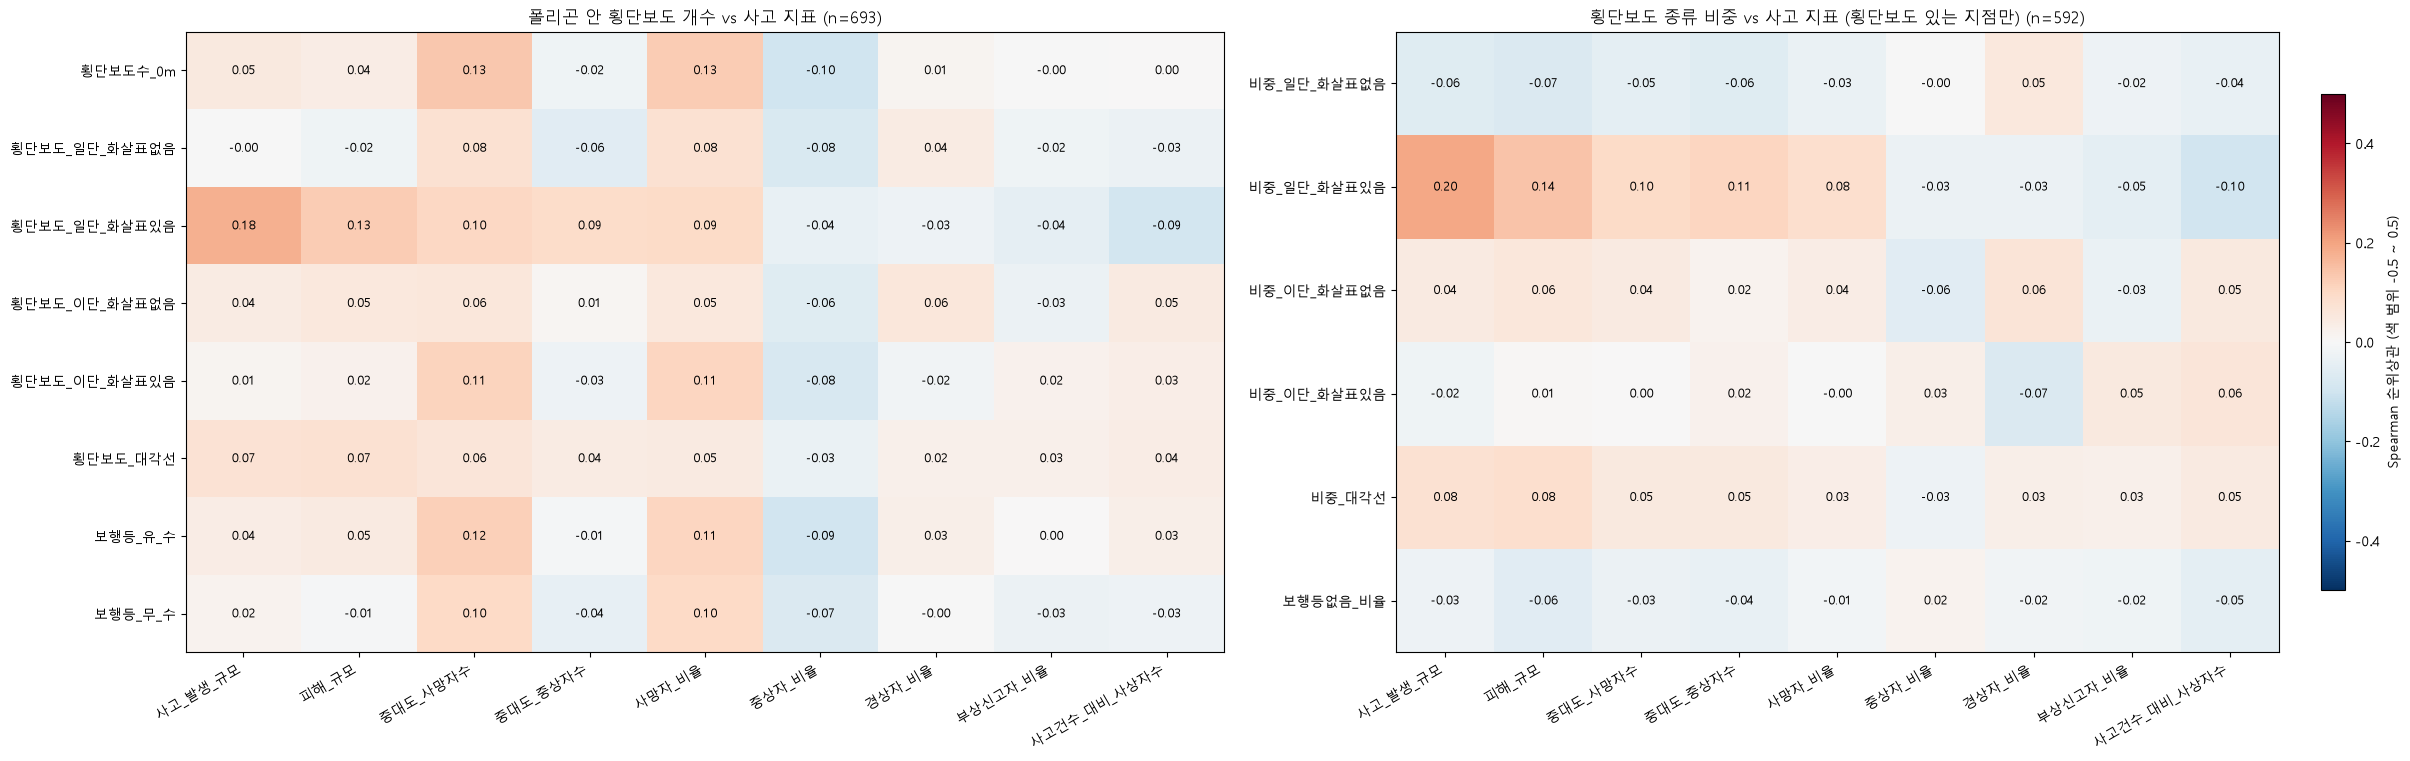

개수 기준 Spearman


,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
횡단보도수_0m,0.05,0.04,0.13,-0.02,0.13,-0.10,0.01,-0.00,0.00
횡단보도_일단_화살표없음,-0.00,-0.02,0.08,-0.06,0.08,-0.08,0.04,-0.02,-0.03
횡단보도_일단_화살표있음,0.18,0.13,0.10,0.09,0.09,-0.04,-0.03,-0.04,-0.09
횡단보도_이단_화살표없음,0.04,0.05,0.06,0.01,0.05,-0.06,0.06,-0.03,0.05
횡단보도_이단_화살표있음,0.01,0.02,0.11,-0.03,0.11,-0.08,-0.02,0.02,0.03
횡단보도_대각선,0.07,0.07,0.06,0.04,0.05,-0.03,0.02,0.03,0.04
보행등_유_수,0.04,0.05,0.12,-0.01,0.11,-0.09,0.03,0.00,0.03
보행등_무_수,0.02,-0.01,0.10,-0.04,0.10,-0.07,-0.00,-0.03,-0.03


비중 기준 Spearman


,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
비중_일단_화살표없음,-0.06,-0.07,-0.05,-0.06,-0.03,-0.00,0.05,-0.02,-0.04
비중_일단_화살표있음,0.20,0.14,0.10,0.11,0.08,-0.03,-0.03,-0.05,-0.10
비중_이단_화살표없음,0.04,0.06,0.04,0.02,0.04,-0.06,0.06,-0.03,0.05
비중_이단_화살표있음,-0.02,0.01,0.00,0.02,-0.00,0.03,-0.07,0.05,0.06
비중_대각선,0.08,0.08,0.05,0.05,0.03,-0.03,0.03,0.03,0.05
보행등없음_비율,-0.03,-0.06,-0.03,-0.04,-0.01,0.02,-0.02,-0.02,-0.05


가장 많은 횡단보도 종류별 사고 지표 중앙값


,지점 수,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
최다_횡단보도종류,,,,,,,,,,
이단_화살표있음,325,7.0,8.0,0.0,7.0,0.0,1.000,0.0,0.0,1.000
일단_화살표없음,148,7.0,8.0,0.0,7.0,0.0,1.000,0.0,0.0,1.000
횡단보도 없음,101,7.0,8.0,0.0,7.0,0.0,1.000,0.0,0.0,1.000
동률,96,7.5,8.0,0.0,7.0,0.0,1.000,0.0,0.0,1.000
일단_화살표있음,18,8.5,9.0,0.0,8.5,0.0,0.925,0.0,0.0,1.000
이단_화살표없음,5,7.0,9.0,0.0,7.0,0.0,0.929,0.0,0.0,1.167


In [ ]:
# 횡단보도 지표 x 사고 지표 9개의 Spearman 순위상관 (탐색용. p값·유의성 판정은 하지 않는다)
count_feats = ['횡단보도수_0m'] + type_cols + ['보행등_유_수', '보행등_무_수']
share_feats = share_cols + ['보행등없음_비율']
const = [c for c in count_feats + share_feats if seoul_analysis[c].nunique() <= 1]
print('값이 하나뿐이라 뺀 지표:', const)
count_feats = [c for c in count_feats if c not in const]
share_feats = [c for c in share_feats if c not in const]

def spearman_table(xs, ys):
    r = pd.DataFrame(index=xs, columns=ys, dtype=float)
    n = pd.DataFrame(index=xs, columns=ys, dtype=int)
    for x in xs:
        for y in ys:
            d = seoul_analysis[[x, y]].dropna()  # 두 값이 모두 있는 지점만
            n.loc[x, y] = len(d)
            r.loc[x, y] = d[x].corr(d[y], method='spearman') if d[x].nunique() > 1 and d[y].nunique() > 1 else np.nan
    return r, n

def draw_heatmap(ax, r, n, title):
    im = ax.imshow(r.to_numpy(dtype=float), cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(len(r.columns)), r.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(r.index)), r.index)
    for i in range(len(r.index)):
        for j in range(len(r.columns)):
            v = r.iloc[i, j]
            ax.text(j, i, '-' if pd.isna(v) else f'{v:.2f}', ha='center', va='center', fontsize=9)
    lo, hi = int(n.min().min()), int(n.max().max())
    ax.set_title(f"{title} (n={lo if lo == hi else f'{lo}~{hi}'})")
    ax.grid(False)
    return im

r_cnt, n_cnt = spearman_table(count_feats, acc_outcomes)
r_shr, n_shr = spearman_table(share_feats, acc_outcomes)
fig, axes = plt.subplots(1, 2, figsize=(24, 7.5), gridspec_kw={'width_ratios': [1, 0.85]}, layout='constrained')
draw_heatmap(axes[0], r_cnt, n_cnt, '폴리곤 안 횡단보도 개수 vs 사고 지표')
im = draw_heatmap(axes[1], r_shr, n_shr, '횡단보도 종류 비중 vs 사고 지표 (횡단보도 있는 지점만)')
fig.colorbar(im, ax=axes, label='Spearman 순위상관 (색 범위 -0.5 ~ 0.5)', shrink=0.8, pad=0.02)
plt.show()

print('개수 기준 Spearman'); display(r_cnt.round(2))
print('비중 기준 Spearman'); display(r_shr.round(2))

# 지점별로 가장 많은 종류에 따른 사고 지표 중앙값
grp = seoul_analysis.groupby('최다_횡단보도종류')
med = grp[acc_outcomes].median().round(3)
med.insert(0, '지점 수', grp.size())
print('가장 많은 횡단보도 종류별 사고 지표 중앙값')
display(med.sort_values('지점 수', ascending=False))

### 4-2-3. 폴리곤 안 횡단보도 수와 사고 지표의 관계

폴리곤 안에 횡단보도가 몇 개 있느냐(`횡단보도수_0m`)만 놓고, 사고 지표 9개와 어떤 관계인지 본다. 4-2-2 왼쪽 히트맵의 첫 행과 같은 값을 따로 뽑은 것이다.

- 표 1: 사고 지표별 Spearman 순위상관(방향과 크기를 요약한 탐색 값이며 p값은 없다).
- 표 2: 횡단보도 수를 0개, 1~2개, 3~4개, 5~6개, 7개 이상으로 나눠 구간별 지점 수와 사고 지표 평균을 본다. 구간은 보기 위한 것이며 기준값이 아니다.
- 그림: 점 하나가 사고다발지역 하나이고, 빨간 선은 횡단보도 수별 평균이다. 겹치는 점이 많아 좌우로 조금 흩어 그렸다. 지점이 5곳 미만인 횡단보도 수는 평균을 잇지 않는다.

폴리곤 안 횡단보도 수 vs 사고 지표 (Spearman 순위상관)


사고 지표,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
Spearman r,0.048,0.038,0.133,-0.02,0.126,-0.101,0.013,-0.004,0.003
n,693.000,693.000,693.000,693.00,693.000,693.000,693.000,693.000,693.000


횡단보도 수 구간별 사고 지표 평균


,지점 수,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
횡단보도수_0m,,,,,,,,,,
0개,101,8.188,8.832,0.178,8.347,0.020,0.949,0.028,0.003,1.078
1~2개,148,8.182,8.905,0.304,8.162,0.037,0.928,0.030,0.005,1.091
3~4개,212,8.000,8.495,0.340,7.825,0.042,0.925,0.028,0.005,1.064
5~6개,131,8.046,8.595,0.359,7.901,0.041,0.928,0.026,0.006,1.069
7개 이상,101,8.426,9.119,0.406,8.267,0.046,0.910,0.041,0.003,1.085


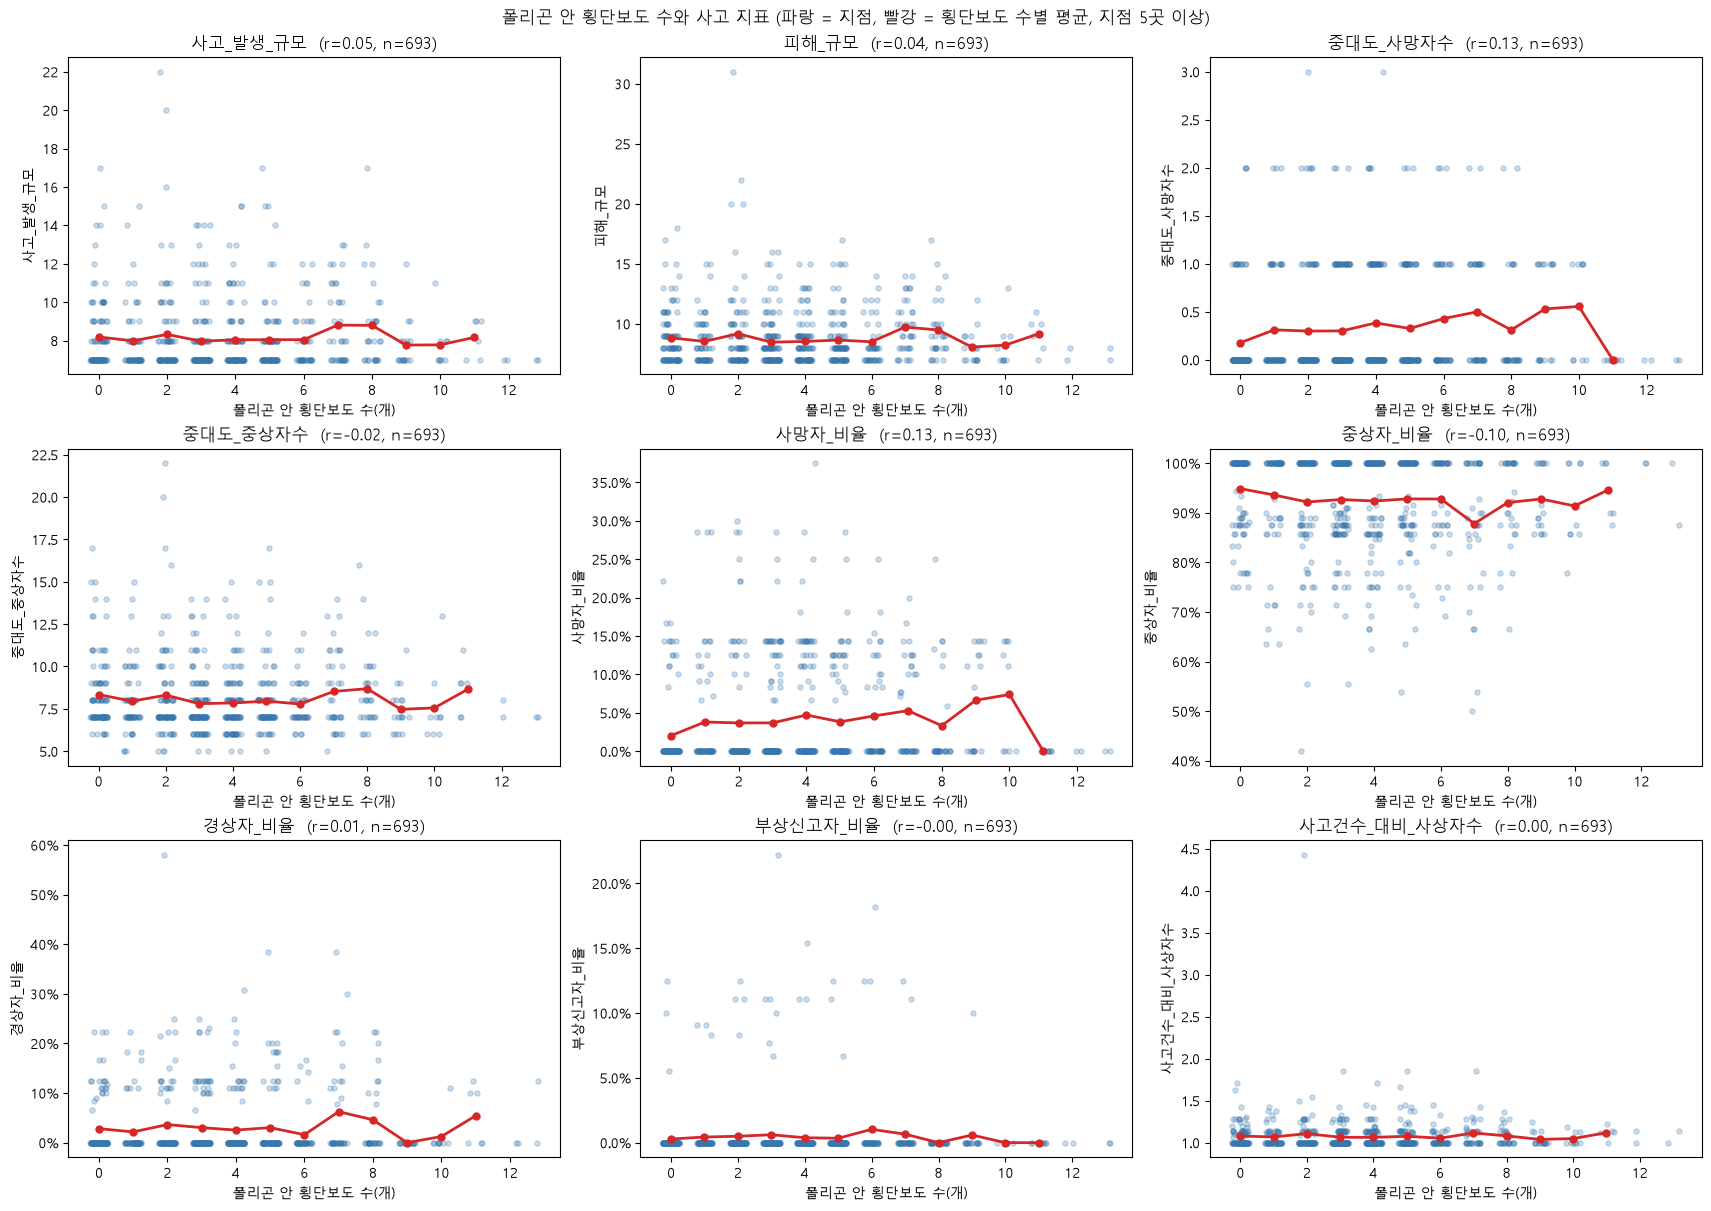

In [ ]:
# 폴리곤 안 횡단보도 수(횡단보도수_0m)와 사고 지표 9개의 관계. 통계검정은 하지 않는다
x = '횡단보도수_0m'
rows = []
for y in acc_outcomes:
    d = seoul_analysis[[x, y]].dropna()
    rows.append({'사고 지표': y, 'Spearman r': round(d[x].corr(d[y], method='spearman'), 3), 'n': len(d)})
print('폴리곤 안 횡단보도 수 vs 사고 지표 (Spearman 순위상관)')
display(pd.DataFrame(rows).set_index('사고 지표').T)

# 횡단보도 수 구간별 사고 지표 평균 (구간마다 지점 수를 함께 본다)
cnt_bin = pd.cut(seoul_analysis[x], [-1, 0, 2, 4, 6, np.inf], labels=['0개', '1~2개', '3~4개', '5~6개', '7개 이상'])
by_bin = seoul_analysis.groupby(cnt_bin, observed=True)[acc_outcomes].mean().round(3)
by_bin.insert(0, '지점 수', cnt_bin.value_counts().reindex(by_bin.index))
print('횡단보도 수 구간별 사고 지표 평균')
display(by_bin)

# 점 하나 = 사고다발지역 하나. 횡단보도 수마다 평균(빨강)을 이어 본다 (지점 5곳 이상인 수만)
rng = np.random.default_rng(0)
fig, axes = plt.subplots(3, 3, figsize=(17, 12), layout='constrained')
for ax, y in zip(axes.ravel(), acc_outcomes):
    d = seoul_analysis[[x, y]].dropna()
    ax.scatter(d[x] + rng.uniform(-0.25, 0.25, len(d)), d[y], alpha=.25, s=14, color='#3877ad')
    g = d.groupby(x)[y].agg(['mean', 'size'])
    g = g[g['size'] >= 5]
    ax.plot(g.index, g['mean'], color='#d62728', marker='o', linewidth=2, markersize=5)
    r = d[x].corr(d[y], method='spearman')
    ax.set(title=f'{y}  (r={r:.2f}, n={len(d)})', xlabel='폴리곤 안 횡단보도 수(개)', ylabel=y)
    if '비율' in y:
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
fig.suptitle('폴리곤 안 횡단보도 수와 사고 지표 (파랑 = 지점, 빨강 = 횡단보도 수별 평균, 지점 5곳 이상)')
plt.show()

- 솔직히 크게 유의미한 관계는 못발견함. ..

### 4-3. 서울 등고선·표고점에서 지형 경사 추정

현재 보유한 도로망은 대학 주변에 한정되어 있다. 이번 서울 비교에서는 **지형의 경사**를 추정한다. 도로 진행 방향의 경사나 횡단보도 경사를 직접 측정한 값은 아니다.

서울 전체 원본을 읽고 각 사고 폴리곤 주변 300m의 등고선 꼭짓점·표고점을 사용한다. 폴리곤 안 20m 간격 격자에서 선형 보간한 고도를 구하고, 동서·남북 ±10m 고도 차이로 경사(%)를 계산한다. 고도 관측점에서 100m 넘게 떨어졌거나 보간 범위 밖인 계산점은 제외한다. 유효 격자 비율 80% 이상이며 10개 이상인 지점만 비교에 사용한다. 이 수치는 탐색용 설정으로, 후속 검증에서 격자 간격과 주변 범위에 대한 민감도 점검이 필요하다.

산지·옹벽·도로 구조물 및 자료 제작 시점의 차이가 추정치에 영향을 줄 수 있다. 관측이 부족한 평지를 0%로 가정하지 않는다. [선형 보간과 범위 밖 결측 처리](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.LinearNDInterpolator.html)

In [3]:
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import cKDTree, QhullError
import shapely

seoul_contours = gpd.read_file(next((SEOUL_PROJECT / '서울시_경사도').rglob('N3L_F001.shp'))).to_crs(SEOUL_CRS)
seoul_spots = gpd.read_file(next((SEOUL_PROJECT / '서울시_경사도').rglob('N3P_F002.shp'))).to_crs(SEOUL_CRS)
print(f'서울 원본: 등고선 {len(seoul_contours):,}개, 표고점 {len(seoul_spots):,}개')
for layer in (seoul_contours, seoul_spots):
    layer['HEIGHT'] = pd.to_numeric(layer['HEIGHT'], errors='coerce')

def terrain_profile(poly):
    area = poly.buffer(300)
    chunks = []
    for layer in (seoul_contours, seoul_spots):
        subset = layer.iloc[layer.sindex.query(area, predicate='intersects')]
        coords, idx = shapely.get_coordinates(subset.geometry.array, return_index=True)
        heights = subset['HEIGHT'].to_numpy()[idx]
        keep = np.isfinite(heights) & np.isfinite(coords).all(axis=1)
        keep &= shapely.intersects_xy(area, coords[:, 0], coords[:, 1])
        chunks.append(np.column_stack([coords[keep], heights[keep]]))
    samples = np.concatenate(chunks)
    out = {'고도관측점수': len(samples), '격자수': 0, '유효격자수': 0, '경사_충족률': 0.,
           '지형경사_평균_pct': np.nan, '지형경사_p90_pct': np.nan,
           '지형경사_5pct초과비율': np.nan, '경사_상태': '관측부족'}
    if len(samples) < 3:
        return out
    # 동일 위치의 중복 고도는 평균으로 집계한다.
    samples = pd.DataFrame(samples, columns=['x', 'y', 'z']).groupby(['x', 'y'], as_index=False).z.mean()
    pts, z = samples[['x', 'y']].to_numpy(), samples.z.to_numpy()
    xmin, ymin, xmax, ymax = poly.bounds
    xx, yy = np.meshgrid(np.arange(np.ceil(xmin / 20) * 20, xmax, 20),
                         np.arange(np.ceil(ymin / 20) * 20, ymax, 20))
    q = np.column_stack([xx.ravel(), yy.ravel()])
    q = q[shapely.intersects_xy(poly, q[:, 0], q[:, 1])]
    out['격자수'] = len(q)
    if not len(q):
        return out
    try:
        interp = LinearNDInterpolator(pts, z)
    except QhullError:
        out['경사_상태'] = '보간불가'
        return out
    offsets = np.array([[10, 0], [-10, 0], [0, 10], [0, -10]])
    probes = q[:, None, :] + offsets
    heights = interp(probes.reshape(-1, 2)).reshape(-1, 4)
    distance = cKDTree(pts).query(probes.reshape(-1, 2))[0].reshape(-1, 4)
    ok = np.isfinite(heights).all(axis=1) & (distance <= 100).all(axis=1)
    out['유효격자수'] = int(ok.sum())
    out['경사_충족률'] = float(ok.mean())
    if ok.sum() < 10 or ok.mean() < .8:
        out['경사_상태'] = '격자충족부족'
        return out
    h = heights[ok]
    slope = np.hypot((h[:, 0] - h[:, 1]) / 20, (h[:, 2] - h[:, 3]) / 20) * 100
    out.update({'지형경사_평균_pct': float(slope.mean()), '지형경사_p90_pct': float(np.quantile(slope, .9)),
                '지형경사_5pct초과비율': float((slope > 5).mean()), '경사_상태': '사용가능'})
    return out

terrain_rows = []
for i, polygon in enumerate(seoul_sites.geometry):
    terrain_rows.append(terrain_profile(polygon))
    if (i + 1) % 100 == 0:
        print(f'지형 경사 계산: {i + 1}/{len(seoul_sites)}')
seoul_terrain = pd.DataFrame(terrain_rows, index=seoul_sites.index)
seoul_analysis[seoul_terrain.columns] = seoul_terrain
print('경사 자료 충족 상태')
display(seoul_analysis['경사_상태'].value_counts().rename('지점수').to_frame())
display(seoul_analysis[['site_id', '지점명'] + list(seoul_terrain.columns)].head(10))


서울 원본: 등고선 13,704개, 표고점 76,580개
지형 경사 계산: 100/693
지형 경사 계산: 200/693
지형 경사 계산: 300/693
지형 경사 계산: 400/693
지형 경사 계산: 500/693
지형 경사 계산: 600/693
경사 자료 충족 상태
        지점수
경사_상태      
사용가능    678
격자충족부족   15
     site_id                           지점명  ...  지형경사_5pct초과비율   경사_상태
0  acc_row_0  서울특별시 종로구 명륜2가(성균관대입구교차로 부근)  ...       0.076923    사용가능
1  acc_row_1        서울특별시 종로구 낙원동(낙원상가 부근)  ...       0.000000    사용가능
2  acc_row_2      서울특별시 종로구 세종로(세종로180 부근)  ...       0.000000    사용가능
3  acc_row_3    서울특별시 종로구 숭인동(신설동역6번출구 부근)  ...       0.000000    사용가능
4  acc_row_4    서울특별시 종로구 종로2가(종로2가교차로 부근)  ...       0.000000    사용가능
5  acc_row_5   서울특별시 종로구 숭인동(신설동역11번출구 부근)  ...       0.000000    사용가능
6  acc_row_6     서울특별시 중구 만리동2가(용산구마포구 부근)  ...       0.903846    사용가능
7  acc_row_7  서울특별시 중구 남대문로5가(서울역91번출구 부근)  ...       0.306122    사용가능
8  acc_row_8      서울특별시 중구 신당동(약수역앞교차로 부근)  ...       0.300000    사용가능
9  acc_row_9     서울특별시 중구 황학동(신당역서울6호선 부근)  ...            NaN  격자충족부족

[10 rows x 10 colu

### 4-3-1. 지형 경사와 사고 지표 9개: 같은 방향으로 움직이는가

4-3에서 추정한 지형 경사(평균, 90분위, 5% 초과 비율)와 사고 지표 9개가 **같은 방향으로 움직이는지**를 본다. 경사가 클수록 지표도 크면 `+`, 경사가 클수록 지표가 작으면 `-`이다.

- **Spearman**: 값의 순위가 같은 방향으로 움직이는 정도. 사고 건수처럼 같은 값이 많은 자료와 극단값에 덜 흔들린다.
- **Pearson**: 값 자체가 직선으로 같은 방향으로 움직이는 정도. 극단값의 영향을 받는다.
- 두 계수의 부호가 같으면 `+` 또는 `-`, 다르면 `엇갈림`으로 적는다. 계수가 0에 가까우면 부호가 우연히 정해졌을 수 있어 방향을 말하기 어렵다.
- 경사를 계산하지 못한 15곳은 뺀다. 이 15곳은 사고건수 중앙값이 10건으로, 계산한 지점의 7건보다 높다(4-4 참고). 경사 결측이 무작위가 아니라는 뜻이라 결과를 서울 전체로 일반화하기 어렵다.
- 통계검정과 가설 설정은 아직 하지 않는다.

경사를 계산한 지점 678곳 (전체 693곳)
Spearman (순위가 같은 방향으로 움직이는 정도)


,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
지형경사_평균_pct,-0.08,-0.06,-0.03,-0.06,-0.02,-0.03,0.04,0.05,-0.01
지형경사_p90_pct,-0.05,-0.02,-0.02,-0.03,-0.01,-0.03,0.04,0.04,-0.01
지형경사_5pct초과비율,-0.07,-0.03,-0.06,-0.03,-0.05,-0.01,0.06,0.04,0.01


Pearson (값 자체가 직선으로 같은 방향으로 움직이는 정도)


,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
지형경사_평균_pct,-0.07,-0.08,-0.02,-0.08,-0.01,-0.01,0.01,0.02,-0.03
지형경사_p90_pct,-0.01,-0.04,-0.01,-0.03,-0.01,0.01,-0.01,0.00,-0.04
지형경사_5pct초과비율,-0.09,-0.09,-0.06,-0.09,-0.05,0.01,0.03,0.03,-0.02


방향 (+ 경사가 클수록 지표도 큼 / - 경사가 클수록 지표는 작음 / 엇갈림 = 두 계수의 부호가 다름)


,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
지형경사_평균_pct,-,-,-,-,-,-,+,+,-
지형경사_p90_pct,-,-,-,-,-,엇갈림,엇갈림,+,-
지형경사_5pct초과비율,-,-,-,-,-,엇갈림,+,+,엇갈림


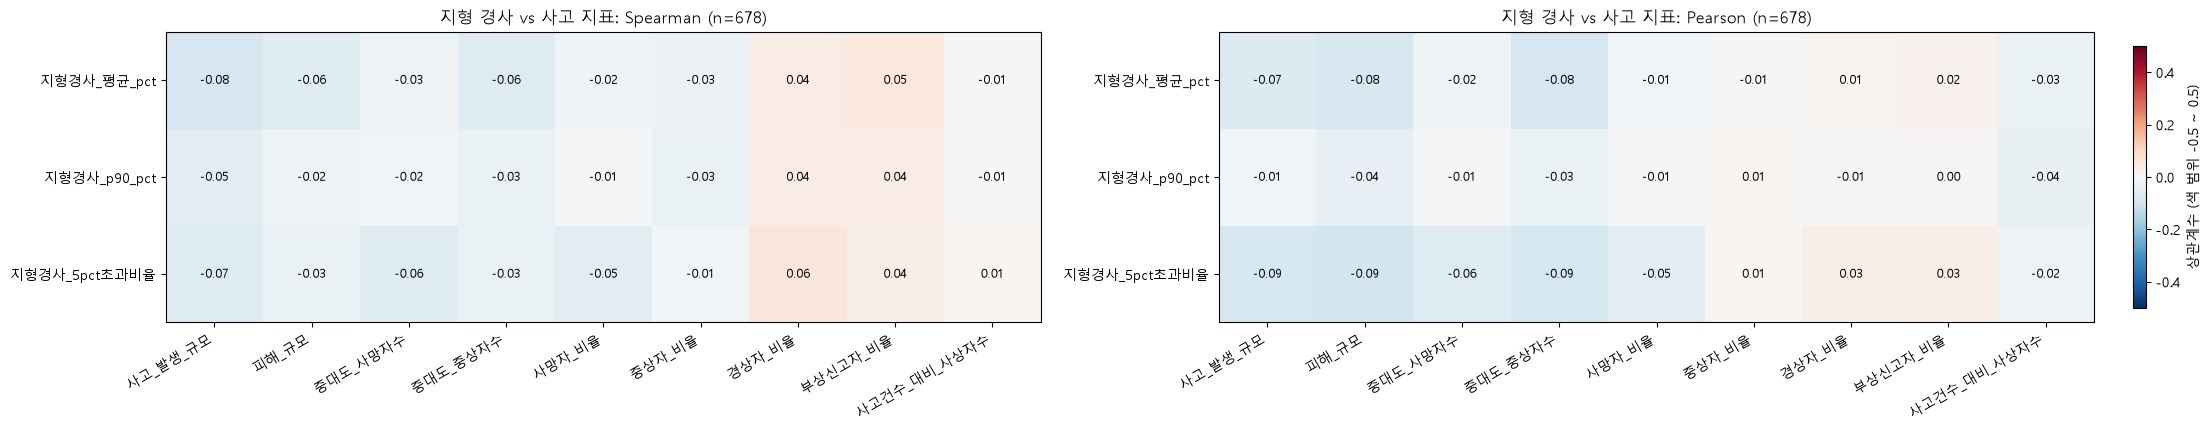

In [ ]:
# 지형 경사 지표 x 사고 지표 9개: 값이 같은 방향으로 움직이는지 본다 (통계검정은 하지 않는다)
slope_feats = ['지형경사_평균_pct', '지형경사_p90_pct', '지형경사_5pct초과비율']

def pair_corr(method):
    out = pd.DataFrame(index=slope_feats, columns=acc_outcomes, dtype=float)
    for x in slope_feats:
        for y in acc_outcomes:
            d = seoul_analysis[[x, y]].dropna()  # 경사가 있는 지점만
            out.loc[x, y] = d[x].corr(d[y], method=method) if d[x].nunique() > 1 and d[y].nunique() > 1 else np.nan
    return out

r_sp, r_pe = pair_corr('spearman'), pair_corr('pearson')

def direction(a, b):
    if np.isnan(a) or np.isnan(b):
        return '-'
    return '+' if a > 0 and b > 0 else ('-' if a < 0 and b < 0 else '엇갈림')
dir_tbl = pd.DataFrame({y: [direction(r_sp.loc[x, y], r_pe.loc[x, y]) for x in slope_feats] for y in acc_outcomes}, index=slope_feats)

n_slope = int(seoul_analysis[slope_feats[0]].notna().sum())
print(f'경사를 계산한 지점 {n_slope}곳 (전체 {len(seoul_analysis)}곳)')
print('Spearman (순위가 같은 방향으로 움직이는 정도)'); display(r_sp.round(2))
print('Pearson (값 자체가 직선으로 같은 방향으로 움직이는 정도)'); display(r_pe.round(2))
print('방향 (+ 경사가 클수록 지표도 큼 / - 경사가 클수록 지표는 작음 / 엇갈림 = 두 계수의 부호가 다름)'); display(dir_tbl)

fig, axes = plt.subplots(1, 2, figsize=(22, 4.2), layout='constrained')
for ax, r, title in [(axes[0], r_sp, 'Spearman'), (axes[1], r_pe, 'Pearson')]:
    im = ax.imshow(r.to_numpy(dtype=float), cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(len(r.columns)), r.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(r.index)), r.index)
    for i in range(len(r.index)):
        for j in range(len(r.columns)):
            ax.text(j, i, f'{r.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
    ax.set_title(f'지형 경사 vs 사고 지표: {title} (n={n_slope})')
    ax.grid(False)
fig.colorbar(im, ax=axes, label='상관계수 (색 범위 -0.5 ~ 0.5)', shrink=0.9, pad=0.02)
plt.show()

### 4-3-2. 평균 경사 구간별 사고 지표

평균 경사를 지점 수가 같도록 5개 구간으로 나누고, 구간마다 사고 지표 평균을 본다. 1구간이 가장 평평하고 5구간이 가장 가파르다. 구간 경계는 보기 위한 것이며 기준값이 아니다. 산점도의 빨간 선은 이 5개 구간의 평균을 이은 것이다.

평균 경사 구간별 사고 지표 평균 (1구간 = 가장 평평, 5구간 = 가장 가파름)


,평균경사_범위_%,지점 수,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
1구간,0.1~1.2,136,8.294,9.015,0.338,8.257,0.039,0.930,0.029,0.002,1.085
2구간,1.2~2.3,135,8.067,8.667,0.378,7.963,0.045,0.923,0.028,0.005,1.077
3구간,2.3~3.5,136,8.478,9.066,0.331,8.426,0.037,0.933,0.027,0.004,1.071
4구간,3.5~5.1,135,7.837,8.489,0.237,7.822,0.031,0.926,0.037,0.006,1.084
5구간,5.2~26.7,136,7.779,8.250,0.316,7.581,0.039,0.925,0.031,0.005,1.062


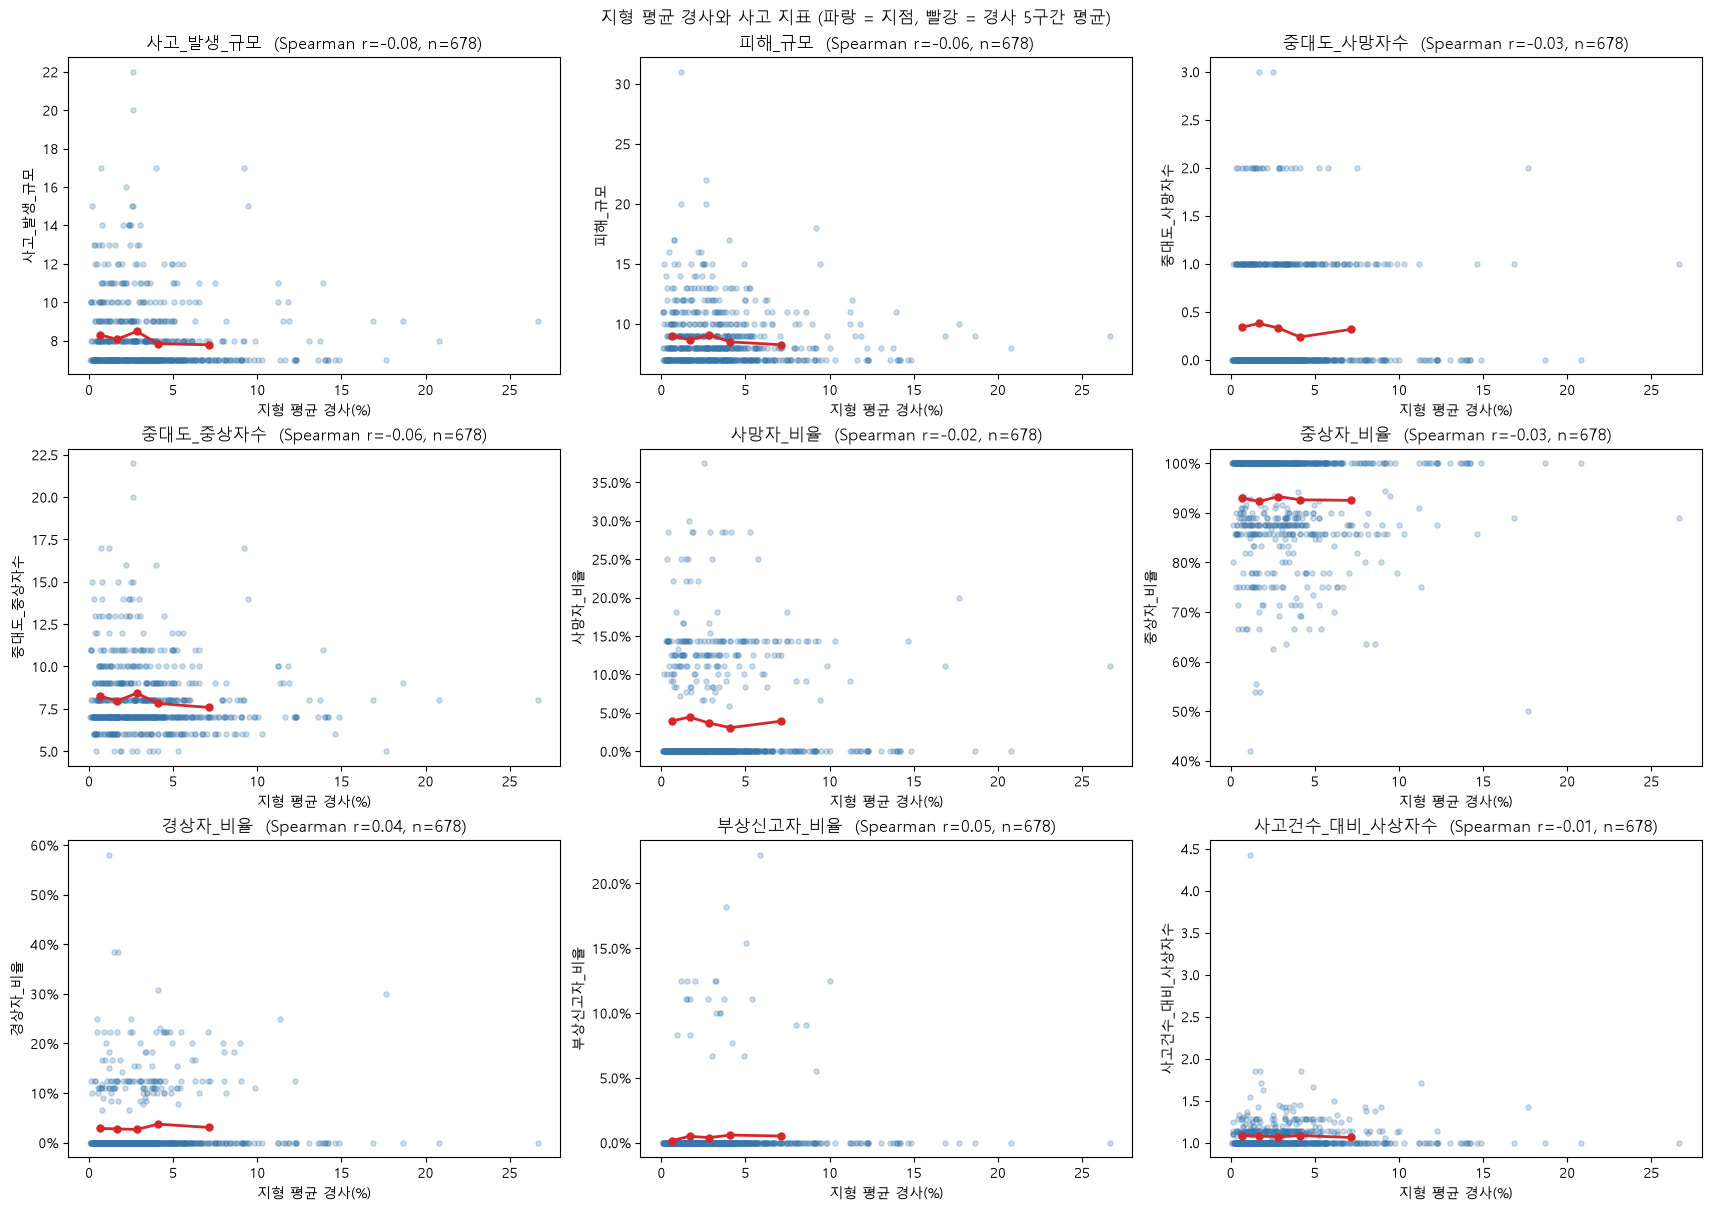

In [ ]:
# 평균 경사를 5개 구간(지점 수가 같도록 나눔)으로 나눠, 구간마다 사고 지표 평균이 어떻게 달라지는지 본다
xcol = '지형경사_평균_pct'
d0 = seoul_analysis.dropna(subset=[xcol])
qbin = pd.qcut(d0[xcol], 5, labels=False)
grp = d0.groupby(qbin)
tbl = grp[acc_outcomes].mean().round(3)
tbl.insert(0, '평균경사_범위_%', [f"{grp[xcol].min()[k]:.1f}~{grp[xcol].max()[k]:.1f}" for k in tbl.index])
tbl.insert(1, '지점 수', grp.size())
tbl.index = [f'{k + 1}구간' for k in tbl.index]
print('평균 경사 구간별 사고 지표 평균 (1구간 = 가장 평평, 5구간 = 가장 가파름)')
display(tbl)

# 점 하나 = 사고다발지역 하나. 빨간 선은 위 5개 구간의 평균
fig, axes = plt.subplots(3, 3, figsize=(17, 12), layout='constrained')
for ax, y in zip(axes.ravel(), acc_outcomes):
    ax.scatter(d0[xcol], d0[y], alpha=.25, s=14, color='#3877ad')
    ax.plot(grp[xcol].median(), grp[y].mean(), color='#d62728', marker='o', linewidth=2, markersize=5)
    ax.set(title=f"{y}  (Spearman r={r_sp.loc[xcol, y]:.2f}, n={len(d0)})", xlabel='지형 평균 경사(%)', ylabel=y)
    if '비율' in y:
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
fig.suptitle('지형 평균 경사와 사고 지표 (파랑 = 지점, 빨강 = 경사 5구간 평균)')
plt.show()

---
## 5. 다시 시도: 사고다발지역 안쪽과 주변 고리의 경사 비교

### 5-1. 봉착한 문제와 다시 시도하는 방법

**봉착한 문제**

4단계에서 사고다발지역 693곳의 횡단보도(수·종류·보행등)와 지형 경사를 사고 지표 9개(사고 규모, 피해 규모, 사망·중상 등)와 비교했지만 뚜렷한 관계가 나오지 않았다. 상관계수의 절댓값이 경사는 0.09 이하, 횡단보도는 0.20 이하였다. 관계가 없다고 단정할 수는 없고, 지금 데이터가 관계를 찾기 어려운 조건이라는 점이 문제로 보인다.

- 사고 7건 이상으로 **이미 뽑힌 곳만** 비교해서 사고 규모가 7~22건 사이로 좁다. 사고가 적은 곳과 비교할 수 없다.
- 보행자·교통량 같은 **노출량**이 없어서, 사고가 많은 이유가 위험해서인지 사람이 많아서인지 가릴 수 없다.
- 경사를 폴리곤 전체 평균으로 봐서 **희석**된다.
- 사고다발지id 5종류의 뜻을 몰라 **집계 기간**이 같은지 알 수 없다.

**다시 시도하는 방법**

1. 사고 규모의 크기를 보지 않고, **사고다발지역인 곳과 아닌 곳**이 경사에서 다른지 본다. 뽑힌 곳끼리만 비교하는 문제를 피한다.
2. 아닌 곳은 각 폴리곤 **바로 바깥 고리**(폭 100m, 200m)로 한다. 다른 사고다발지역은 고리에서 뺀다. 같은 동네끼리 짝지어 비교하므로 언덕이 많은 동네와 평지 동네의 차이가 섞이지 않는다.
3. 횡단보도 변수는 이번에는 쓰지 않고 **경사만** 본다.
4. 안쪽 경사에서 고리 경사를 뺀 값이 0보다 큰 지점이 많은지(안쪽이 더 가파른지) 본다. 통계검정은 하지 않는다.

**한계**: 노출량은 여전히 없다. 지형 경사이지 도로 경사가 아니고, 고리에는 건물·하천·공원처럼 걷지 않는 땅도 섞여 있다. 사고다발지역이라는 것은 "사고가 잦다"는 뜻이지 "위험하다"는 뜻이 아니다.

### 5-2. 안쪽과 고리의 경사 계산

4-3과 **같은 방법**으로 안쪽과 두 고리의 경사를 계산한다. 20m 간격 격자에서 동서·남북 ±10m 고도 차이로 경사(%)를 구하고, 고도 관측점에서 100m 넘게 떨어졌거나 보간 범위 밖인 점은 뺀다. 유효 격자가 10개 이상이고 80% 이상인 곳만 쓴다. 고리 끝 격자까지 이 검사를 하려고 고도 관측점은 폴리곤에서 310m 안까지 쓴다. 안쪽 경사는 4-3과 거의 같아야 하므로 차이도 함께 확인한다.

오래 걸리는 셀이다(693곳, 약 10분). 고리가 다른 다발지역에 모두 가려지거나 유효 격자가 모자라면 그 지점은 비교에서 빠진다.

In [ ]:
# 사고다발지역 안쪽과 바로 바깥 고리의 경사를 같은 방법으로 계산한다 (20m 격자, 동서·남북 ±10m 고도차, 4-3과 같은 유효 기준)
# 오래 걸리는 셀이다 (693곳, 약 10분)
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import cKDTree, QhullError
import shapely

RING_WIDTHS = (100, 200)                       # 고리 폭(m): 폴리곤 바깥 0~100m, 0~200m
SAMPLE_RADIUS = max(RING_WIDTHS) + 110         # 고리 끝 격자에서 고도 관측점까지 100m 검사를 하므로 여유를 둔다
OFFSETS = np.array([[10, 0], [-10, 0], [0, 10], [0, -10]])
hot_union = seoul_sites.geometry.union_all()   # 서울 사고다발지역 전체. 고리에서 다른 다발지역은 뺀다

def grid_points(area, step=20):
    xmin, ymin, xmax, ymax = area.bounds
    xx, yy = np.meshgrid(np.arange(np.ceil(xmin / step) * step, xmax, step), np.arange(np.ceil(ymin / step) * step, ymax, step))
    q = np.column_stack([xx.ravel(), yy.ravel()])
    return q[shapely.intersects_xy(area, q[:, 0], q[:, 1])]

def samples_around(poly, radius):
    area = poly.buffer(radius)
    chunks = []
    for layer in (seoul_contours, seoul_spots):
        subset = layer.iloc[layer.sindex.query(area, predicate='intersects')]
        coords, idx = shapely.get_coordinates(subset.geometry.array, return_index=True)
        heights = subset['HEIGHT'].to_numpy()[idx]
        keep = np.isfinite(heights) & np.isfinite(coords).all(axis=1)
        keep &= shapely.intersects_xy(area, coords[:, 0], coords[:, 1])
        chunks.append(np.column_stack([coords[keep], heights[keep]]))
    s = pd.DataFrame(np.concatenate(chunks), columns=['x', 'y', 'z'])
    return s.groupby(['x', 'y'], as_index=False).z.mean()  # 같은 위치의 중복 고도는 평균

EMPTY = {'격자수': 0, '유효격자수': 0, '경사_평균_pct': np.nan, '경사_p90_pct': np.nan, '경사_5pct초과비율': np.nan, '상태': '관측부족'}

def slope_summary(area, interp, tree):
    out = dict(EMPTY, 상태='면적없음')
    if area.is_empty:
        return out
    q = grid_points(area)
    out['격자수'] = len(q)
    if not len(q):
        return out
    probes = (q[:, None, :] + OFFSETS).reshape(-1, 2)
    h = interp(probes).reshape(-1, 4)
    dist = tree.query(probes)[0].reshape(-1, 4)
    ok = np.isfinite(h).all(axis=1) & (dist <= 100).all(axis=1)
    out['유효격자수'] = int(ok.sum())
    if ok.sum() < 10 or ok.mean() < .8:
        out['상태'] = '격자충족부족'
        return out
    hh = h[ok]
    s = np.hypot((hh[:, 0] - hh[:, 1]) / 20, (hh[:, 2] - hh[:, 3]) / 20) * 100
    out.update({'경사_평균_pct': float(s.mean()), '경사_p90_pct': float(np.quantile(s, .9)), '경사_5pct초과비율': float((s > 5).mean()), '상태': '사용가능'})
    return out

area_names = ['내부'] + [f'고리{w}m' for w in RING_WIDTHS]
ring_rows = []
for i, poly in enumerate(seoul_sites.geometry):
    areas = {'내부': poly, **{f'고리{w}m': poly.buffer(w).difference(hot_union) for w in RING_WIDTHS}}
    row = {f'{n}_{k}': v for n in area_names for k, v in EMPTY.items()}
    s = samples_around(poly, SAMPLE_RADIUS)
    if len(s) >= 3:
        try:
            interp = LinearNDInterpolator(s[['x', 'y']].to_numpy(), s['z'].to_numpy())
            tree = cKDTree(s[['x', 'y']].to_numpy())
            for n, area in areas.items():
                row.update({f'{n}_{k}': v for k, v in slope_summary(area, interp, tree).items()})
        except QhullError:
            row.update({f'{n}_상태': '보간불가' for n in area_names})
    ring_rows.append(row)
    if (i + 1) % 100 == 0:
        print(f'안쪽·고리 경사 계산: {i + 1}/{len(seoul_sites)}')

seoul_ring = pd.concat([seoul_sites[['site_id', '지점명']], pd.DataFrame(ring_rows, index=seoul_sites.index)], axis=1)
print('계산 상태 (지점 수)')
display(pd.DataFrame({n: seoul_ring[f'{n}_상태'].value_counts() for n in area_names}).fillna(0).astype(int))
both = seoul_ring['내부_경사_평균_pct'].notna() & seoul_analysis['지형경사_평균_pct'].notna()
print(f"4-3의 평균 경사와 이번 안쪽 평균 경사의 차이(절댓값) 최대: {(seoul_ring.loc[both, '내부_경사_평균_pct'] - seoul_analysis.loc[both, '지형경사_평균_pct']).abs().max():.3f}%p (같은 방법이라 거의 같아야 한다)")
display(seoul_ring.head(8))

안쪽·고리 경사 계산: 100/693


안쪽·고리 경사 계산: 200/693


안쪽·고리 경사 계산: 300/693


안쪽·고리 경사 계산: 400/693


안쪽·고리 경사 계산: 500/693


안쪽·고리 경사 계산: 600/693


계산 상태 (지점 수)


,내부,고리100m,고리200m
사용가능,678,679,687
격자충족부족,15,14,6


4-3의 평균 경사와 이번 안쪽 평균 경사의 차이(절댓값) 최대: 0.035%p (같은 방법이라 거의 같아야 한다)


,site_id,지점명,내부_격자수,내부_유효격자수,내부_경사_평균_pct,내부_경사_p90_pct,내부_경사_5pct초과비율,내부_상태,고리100m_격자수,고리100m_유효격자수,고리100m_경사_평균_pct,고리100m_경사_p90_pct,고리100m_경사_5pct초과비율,고리100m_상태,고리200m_격자수,고리200m_유효격자수,고리200m_경사_평균_pct,고리200m_경사_p90_pct,고리200m_경사_5pct초과비율,고리200m_상태
0,acc_row_0,서울특별시 종로구 명륜2가(성균관대입구교차로 부근),52,52,3.375540,4.935323,0.076923,사용가능,173,173,5.226619,11.548872,0.404624,사용가능,530,530,5.320679,12.182367,0.416981,사용가능
1,acc_row_1,서울특별시 종로구 낙원동(낙원상가 부근),48,48,0.818487,1.007585,0.000000,사용가능,157,155,1.220795,1.784723,0.000000,사용가능,426,413,1.431690,3.570321,0.000000,사용가능
2,acc_row_2,서울특별시 종로구 세종로(세종로180 부근),47,46,1.100853,2.836874,0.000000,사용가능,201,200,2.330548,4.928171,0.095000,사용가능,559,554,2.713490,5.146251,0.106498,사용가능
3,acc_row_3,서울특별시 종로구 숭인동(신설동역6번출구 부근),46,39,0.352419,0.386646,0.000000,사용가능,137,125,1.043079,1.981143,0.000000,사용가능,411,399,1.377009,3.540311,0.055138,사용가능
4,acc_row_4,서울특별시 종로구 종로2가(종로2가교차로 부근),46,43,1.180013,2.484583,0.000000,사용가능,110,110,1.334608,4.140239,0.000000,사용가능,382,382,3.056273,6.904231,0.123037,사용가능
5,acc_row_5,서울특별시 종로구 숭인동(신설동역11번출구 부근),46,46,1.549904,2.762563,0.000000,사용가능,133,109,1.967252,5.744359,0.119266,사용가능,411,355,6.684234,19.480546,0.369014,사용가능
6,acc_row_6,서울특별시 중구 만리동2가(용산구마포구 부근),52,52,16.853136,29.540079,0.903846,사용가능,181,181,19.782963,40.488505,0.900552,사용가능,537,537,18.913096,36.952107,0.908752,사용가능
7,acc_row_7,서울특별시 중구 남대문로5가(서울역91번출구 부근),49,49,3.483411,7.152186,0.306122,사용가능,153,152,8.258343,11.588788,0.592105,사용가능,514,494,8.362964,20.401369,0.520243,사용가능


### 5-3. 안쪽과 고리의 경사 차이

지점마다 **안쪽 경사 − 고리 경사**를 구한다. 양수면 사고다발지역이 주변보다 가파르다는 뜻이다. 경사 지표 3가지(평균, 90분위, 5% 초과 비율)와 고리 폭 2가지를 모두 보고, 평균 경사는 산점도와 차이의 분포로 그린다. 산점도에서 빨간 선 위쪽이면 고리가 더 가파르다.

안쪽 - 고리 (양수 = 사고다발지역 안쪽이 주변보다 가파름)


짝 수  안쪽 중앙값  고리 중앙값  차이(안쪽-고리) 중앙값  안쪽이 더 가파름_%  고리가 더 가파름_%
고리 폭 경사 지표                                                                    
100m 경사_평균_pct    666   2.836   3.834         -0.580         31.2         68.8
     경사_p90_pct   666   5.281   7.817         -1.789         23.6         76.4
     경사_5pct초과비율  666   0.125   0.251         -0.035         27.0         61.1
200m 경사_평균_pct    674   2.832   4.229         -1.239         24.0         76.0
     경사_p90_pct   674   5.249   9.644         -3.643         18.0         82.0
     경사_5pct초과비율  674   0.122   0.290         -0.086         24.9         70.3

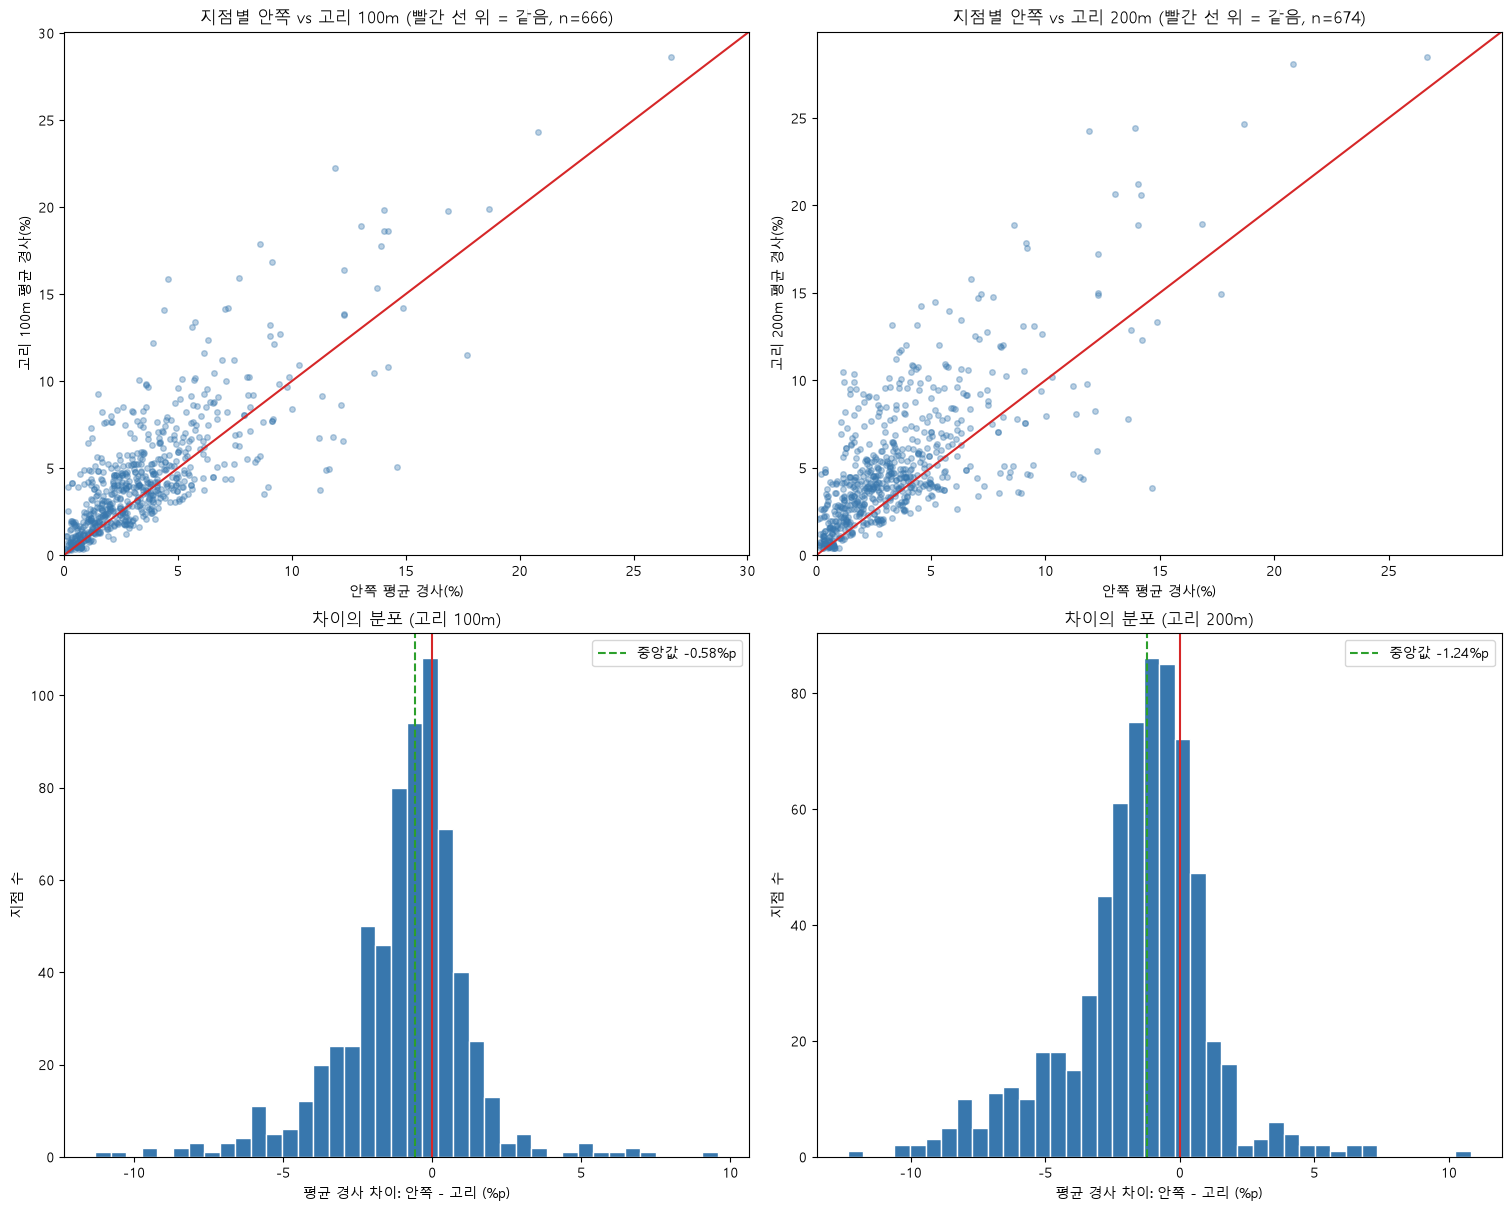

In [ ]:
# 지점마다 안쪽과 고리의 경사를 짝지어 비교한다 (안쪽 - 고리). 통계검정은 하지 않는다
measures = ['경사_평균_pct', '경사_p90_pct', '경사_5pct초과비율']
rows = []
for w in RING_WIDTHS:
    for m in measures:
        d = seoul_ring[[f'내부_{m}', f'고리{w}m_{m}']].dropna()
        diff = d[f'내부_{m}'] - d[f'고리{w}m_{m}']
        rows.append({'고리 폭': f'{w}m', '경사 지표': m, '짝 수': len(d), '안쪽 중앙값': round(d[f'내부_{m}'].median(), 3), '고리 중앙값': round(d[f'고리{w}m_{m}'].median(), 3),
                     '차이(안쪽-고리) 중앙값': round(diff.median(), 3), '안쪽이 더 가파름_%': round((diff > 0).mean() * 100, 1), '고리가 더 가파름_%': round((diff < 0).mean() * 100, 1)})
print('안쪽 - 고리 (양수 = 사고다발지역 안쪽이 주변보다 가파름)')
display(pd.DataFrame(rows).set_index(['고리 폭', '경사 지표']))

fig, axes = plt.subplots(2, len(RING_WIDTHS), figsize=(7.5 * len(RING_WIDTHS), 12), layout='constrained')
for j, w in enumerate(RING_WIDTHS):
    d = seoul_ring[['내부_경사_평균_pct', f'고리{w}m_경사_평균_pct']].dropna()
    x, y = d.iloc[:, 0], d.iloc[:, 1]
    lim = max(x.max(), y.max()) * 1.05
    ax = axes[0, j]
    ax.scatter(x, y, alpha=.35, s=16, color='#3877ad')
    ax.plot([0, lim], [0, lim], color='#d62728', linewidth=1.5)
    ax.set(xlim=(0, lim), ylim=(0, lim), xlabel='안쪽 평균 경사(%)', ylabel=f'고리 {w}m 평균 경사(%)',
           title=f'지점별 안쪽 vs 고리 {w}m (빨간 선 위 = 같음, n={len(d)})')
    ax = axes[1, j]
    diff = x - y
    ax.hist(diff, bins=40, color='#3877ad', edgecolor='white')
    ax.axvline(0, color='#d62728', linewidth=1.5)
    ax.axvline(diff.median(), color='#2ca02c', linewidth=1.5, linestyle='--', label=f'중앙값 {diff.median():.2f}%p')
    ax.set(xlabel='평균 경사 차이: 안쪽 - 고리 (%p)', ylabel='지점 수', title=f'차이의 분포 (고리 {w}m)')
    ax.legend()
plt.show()

### 5-4. 경사 차이와 사고 지표

안쪽이 고리보다 가파른 정도(평균 경사 차이)가 클수록 사고 지표도 큰지를 Spearman 순위상관으로 본다. 같은 동네끼리 뺀 값이라 언덕 많은 동네의 영향은 줄어든다. 탐색용 값이며 p값은 없다.

In [ ]:
# 안쪽-고리 평균 경사 차이와 사고 지표 9개의 Spearman 순위상관 (탐색용, p값 없음)
rows = {}
for w in RING_WIDTHS:
    diff = seoul_ring['내부_경사_평균_pct'] - seoul_ring[f'고리{w}m_경사_평균_pct']
    rows[f'고리 {w}m (n={int(diff.notna().sum())})'] = {y: diff.corr(seoul_analysis[y], method='spearman') for y in acc_outcomes}
print('평균 경사 차이(안쪽-고리) vs 사고 지표')
display(pd.DataFrame(rows).T.round(2))

평균 경사 차이(안쪽-고리) vs 사고 지표


,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
고리 100m (n=666),-0.00,0.01,0.05,-0.02,0.05,-0.08,0.09,-0.02,0.04
고리 200m (n=674),-0.02,0.01,0.03,-0.02,0.03,-0.06,0.08,-0.01,0.03


---
## 6. 사고다발지역 지점 유형 규정: 사고 컬럼의 관계 분석

### 6-1. 무엇을 하려는가

- **목표**: 사고다발지역의 각 지점을 "어떤 지점(공간)인가"로 규정한다.
- **방법**: 다른 데이터를 붙이기 전에, 사고다발지역 데이터 자체의 컬럼들이 서로 어떤 관계인지 먼저 본다. 그 관계에서 지점을 나누는 기준을 정한다.
  1. 6-2. 사고 컬럼끼리의 관계
  2. 6-3. 관계를 바탕으로 유형 규칙 정하기 (피해 구성 × 규모)
  3. 6-4. 지점명으로 공간 종류 표시하고 유형과 비교하기
- **대상**: 서울 693곳. 재료는 사고건수·사망자수·중상자수·경상자수·부상신고자수다. 사상자수는 세부 항목의 합이라 이중으로 세지 않으려고 뺀다.
- 유형 이름은 이 프로젝트에서 붙인 분류이며 공식 분류가 아니다. 통계검정은 하지 않는다.

### 6-2. 사고 컬럼끼리의 관계

다섯 개 사고 컬럼과 폴리곤 면적을 보고, 컬럼끼리 어떤 규칙이 있는지 확인한다. 왼쪽은 컬럼 간 순위상관(Spearman), 오른쪽은 사고건수와 사망·중상자수의 관계다. 사고당 사상자수(= 사상자수 ÷ 사고건수)도 함께 넣었다.

        count  mean   std  min  25%  50%  75%   max
사고건수    693.0  8.14  1.93  7.0  7.0  7.0  8.0  22.0
사망자수    693.0  0.32  0.56  0.0  0.0  0.0  1.0   3.0
중상자수    693.0  8.05  2.12  5.0  7.0  7.0  9.0  22.0
경상자수    693.0  0.32  0.96  0.0  0.0  0.0  0.0  18.0
부상신고자수  693.0  0.04  0.23  0.0  0.0  0.0  0.0   2.0

폴리곤 면적: 19,519 ~ 19,721 m2, 변동계수 0.25% -> 크기가 거의 같아서 유형을 나누는 재료로 쓰지 않는다
사고건수 - (사망자수 + 중상자수): 0인 곳 563곳 (81.2%), 음수 130곳, 양수 0곳
경상·부상신고자가 있는 155곳 중 사고건수가 사상자수보다 적은 곳: 155곳

사망자수별 평균


,지점수,평균_사고건수,평균_중상자수,평균_경상자수
사망자수,,,,
0,502,8.11,8.35,0.32
1,161,8.20,7.41,0.29
2,28,8.21,6.54,0.50
3,2,9.00,6.00,0.00


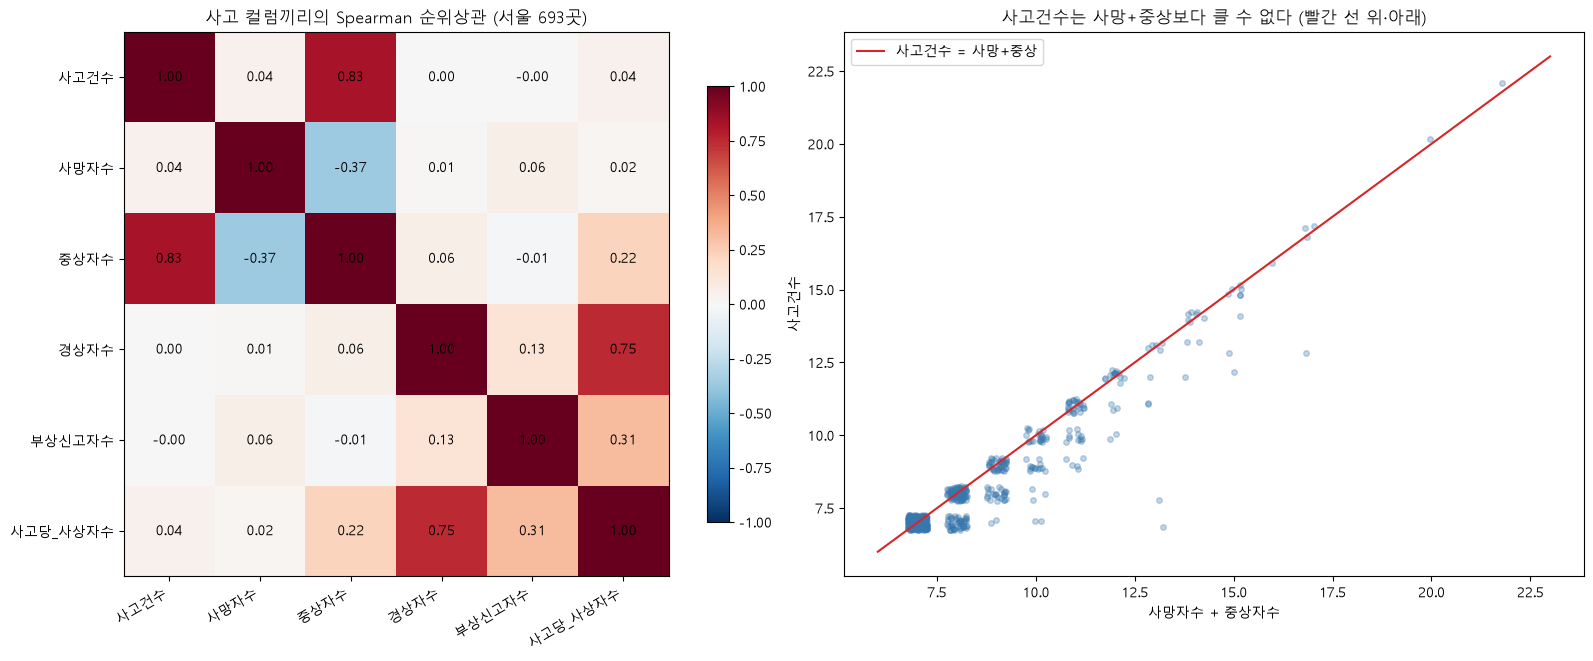

In [ ]:
# 사고 컬럼끼리의 관계 (서울 사고다발지역 693곳)
d = seoul_analysis
cnt = ['사고건수', '사망자수', '중상자수', '경상자수', '부상신고자수']
print(d[cnt].describe().round(2).T)

area = d['면적_m2']
print(f"\n폴리곤 면적: {area.min():,.0f} ~ {area.max():,.0f} m2, 변동계수 {area.std() / area.mean() * 100:.2f}% -> 크기가 거의 같아서 유형을 나누는 재료로 쓰지 않는다")

serious = d['사망자수'] + d['중상자수']          # 사망 + 중상
gap = d['사고건수'] - serious
minor = d['경상자수'] + d['부상신고자수']        # 경상 + 부상신고
print(f"사고건수 - (사망자수 + 중상자수): 0인 곳 {int(gap.eq(0).sum())}곳 ({gap.eq(0).mean() * 100:.1f}%), 음수 {int(gap.lt(0).sum())}곳, 양수 {int(gap.gt(0).sum())}곳")
print(f"경상·부상신고자가 있는 {int(minor.gt(0).sum())}곳 중 사고건수가 사상자수보다 적은 곳: {int((d.loc[minor.gt(0), '사고건수'] < d.loc[minor.gt(0), '사상자수']).sum())}곳")

# 사망자수에 따라 중상자수가 어떻게 달라지는가
by_death = d.groupby('사망자수').agg(지점수=('사고건수', 'size'), 평균_사고건수=('사고건수', 'mean'), 평균_중상자수=('중상자수', 'mean'), 평균_경상자수=('경상자수', 'mean')).round(2)
print('\n사망자수별 평균')
display(by_death)

corr_cols = cnt + ['사고당_사상자수']
r = d[corr_cols].corr(method='spearman')
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), layout='constrained', gridspec_kw={'width_ratios': [1.05, 1]})
ax = axes[0]
im = ax.imshow(r, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=30, ha='right')
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{r.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('사고 컬럼끼리의 Spearman 순위상관 (서울 693곳)')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)

rng = np.random.default_rng(0)
ax = axes[1]
ax.scatter(serious + rng.uniform(-.25, .25, len(d)), d['사고건수'] + rng.uniform(-.25, .25, len(d)), alpha=.3, s=16, color='#3877ad')
lim = [serious.min() - 1, serious.max() + 1]
ax.plot(lim, lim, color='#d62728', linewidth=1.5, label='사고건수 = 사망+중상')
ax.set(xlabel='사망자수 + 중상자수', ylabel='사고건수', title='사고건수는 사망+중상보다 클 수 없다 (빨간 선 위·아래)')
ax.legend()
plt.show()

### 6-3. 유형 규칙: 피해 구성 × 규모

6-2에서 본 관계로 지점을 두 축으로 나눈다.

- **피해 구성**: 사망자가 1명 이상이면 `사망 포함`. 사망은 없고 경상자나 부상신고자가 있으면 `경상·신고 포함`. 나머지(사망·중상 위주)는 `중상 위주`다. 사망·중상이 사고건수를 이루고 경상·부상신고는 그 위에 더해지는 구조라서, 이 셋으로 나누면 지점의 피해 성격이 갈린다.
- **규모**: 사고건수 7건(선정 하한), 8~9건, 10건 이상. 구간 경계는 보기 위한 것이며 기준값이 아니다.
- **다수피해 사고**: 사고건수가 사망+중상자수보다 적으면, 한 사고에서 여러 명이 사망·중상한 사고가 들어 있다고 표시한다.

피해 구성 (사망 포함: 사망자수 1명 이상 / 경상·신고 포함: 사망 없이 경상자나 부상신고자가 있음 / 중상 위주: 그 외)


피해_구성,중상 위주,사망 포함,경상·신고 포함
지점 수,390.0,191.0,112.0
비중_%,56.3,27.6,16.2


규모 x 피해 구성 (지점 수)


피해_구성,중상 위주,사망 포함,경상·신고 포함,합계
규모_구간,,,,
7건,225,101,66,392
8~9건,102,55,32,189
10건 이상,63,35,14,112


사고건수 < 사망+중상인 지점(한 사고에서 여러 명이 사망·중상): 130곳 (18.8%)


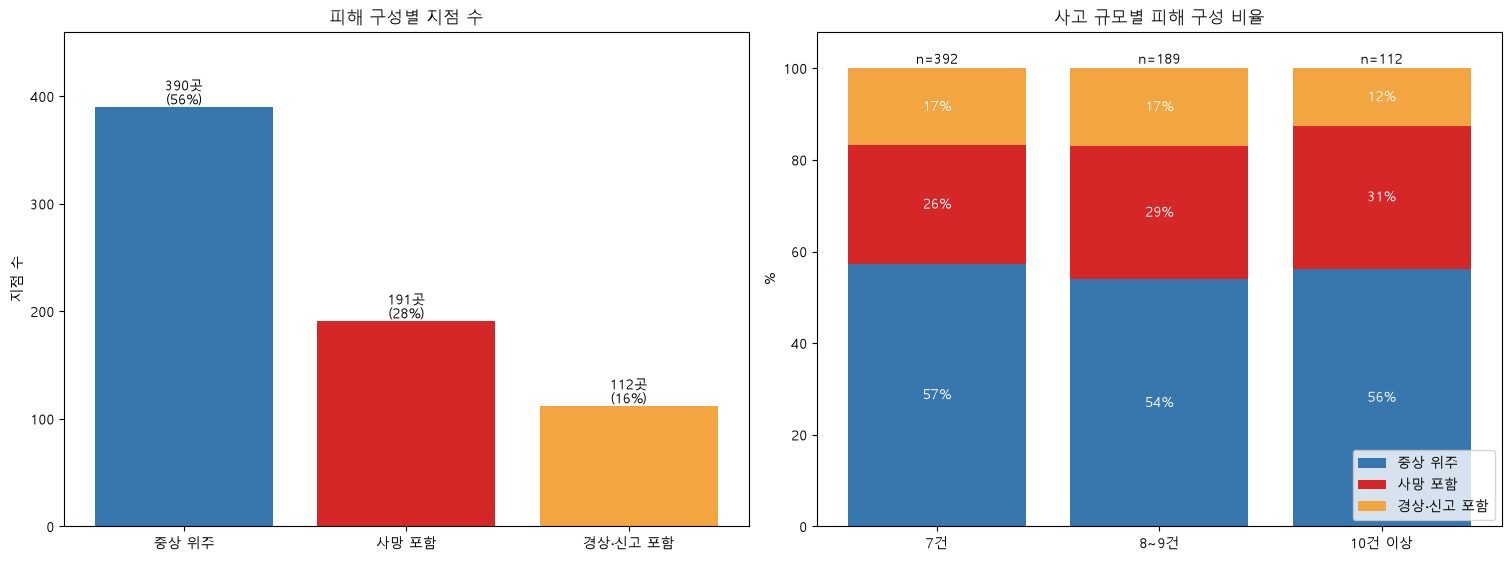

In [ ]:
# 지점 유형 규정: 피해 구성 x 규모. 규칙은 6-2에서 본 컬럼 관계에서 나온 것이다
d = seoul_analysis
serious = d['사망자수'] + d['중상자수']
minor = d['경상자수'] + d['부상신고자수']

d['피해_구성'] = np.select([d['사망자수'] > 0, minor > 0], ['사망 포함', '경상·신고 포함'], default='중상 위주')
d['규모_구간'] = pd.cut(d['사고건수'], [6, 7, 9, np.inf], labels=['7건', '8~9건', '10건 이상'])
d['다수피해_사고'] = d['사고건수'] < serious   # 한 사고에서 사망·중상이 둘 이상 나온 사고가 들어 있음
d['지점_유형'] = d['피해_구성'] + ' / ' + d['규모_구간'].astype(str)

order = ['중상 위주', '사망 포함', '경상·신고 포함']
share = d['피해_구성'].value_counts().reindex(order)
print('피해 구성 (사망 포함: 사망자수 1명 이상 / 경상·신고 포함: 사망 없이 경상자나 부상신고자가 있음 / 중상 위주: 그 외)')
display(pd.DataFrame({'지점 수': share, '비중_%': (share / len(d) * 100).round(1)}).T)

ct = pd.crosstab(d['규모_구간'], d['피해_구성']).reindex(columns=order)
print('규모 x 피해 구성 (지점 수)')
display(ct.assign(합계=ct.sum(axis=1)))
print(f"사고건수 < 사망+중상인 지점(한 사고에서 여러 명이 사망·중상): {int(d['다수피해_사고'].sum())}곳 ({d['다수피해_사고'].mean() * 100:.1f}%)")

colors = {'중상 위주': '#3877ad', '사망 포함': '#d62728', '경상·신고 포함': '#f2a541'}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), layout='constrained')
ax = axes[0]
ax.bar(order, share.values, color=[colors[k] for k in order])
for i, v in enumerate(share.values):
    ax.text(i, v, f'{v}곳\n({v / len(d) * 100:.0f}%)', ha='center', va='bottom')
ax.set(title='피해 구성별 지점 수', ylabel='지점 수', ylim=(0, share.max() * 1.18))
ax = axes[1]
pct = ct.div(ct.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(pct))
for k in order:
    ax.bar(pct.index.astype(str), pct[k], bottom=bottom, color=colors[k], label=k)
    for i, (b, v) in enumerate(zip(bottom, pct[k])):
        ax.text(i, b + v / 2, f'{v:.0f}%', ha='center', va='center', color='white', fontsize=10)
    bottom += pct[k].to_numpy()
for i, n in enumerate(ct.sum(axis=1)):
    ax.text(i, 101, f'n={n}', ha='center')
ax.set(title='사고 규모별 피해 구성 비율', ylabel='%', ylim=(0, 108))
ax.legend(loc='lower right')
plt.show()

### 6-4. 지점명으로 본 공간 종류

지점명은 "동(가까운 시설 이름 부근)" 형식이다. 괄호 안 시설 이름의 키워드로 지하철역, 시장, 병원·약국, 학교, 상가·빌딩, 교차로, 기타로 나눈다(위에서부터 먼저 맞는 종류로 정한다). 실제 토지 이용이 아니라 이름 기반의 거친 분류다. 공간 종류마다 피해 구성 비율이 다른지 본다.

공간 종류별 지점 수


공간_종류,지하철역,병원·약국,교차로,기타,상가·빌딩,시장,학교
지점 수,160,130,118,118,74,59,34


기타로 남은 이름 예: ['세종로180', '용산구마포구', '기업은행성동지점', '을지로1가', '이태원소방파출소', '우리은행청량리중앙지', '장안APT', '장안동우리은행', '전농동29568', '서울시설공단', '장안동46914', '용두교']
공간 종류별 피해 구성 비율(%)


피해_구성,지점 수,중상 위주,사망 포함,경상·신고 포함,평균 사고건수
공간_종류,,,,,
지하철역,160,51.2,32.5,16.2,8.52
병원·약국,130,63.8,24.6,11.5,8.40
교차로,118,53.4,28.8,17.8,7.85
기타,118,56.8,25.4,17.8,7.62
상가·빌딩,74,59.5,21.6,18.9,8.19
시장,59,54.2,33.9,11.9,8.34
학교,34,55.9,20.6,23.5,7.65


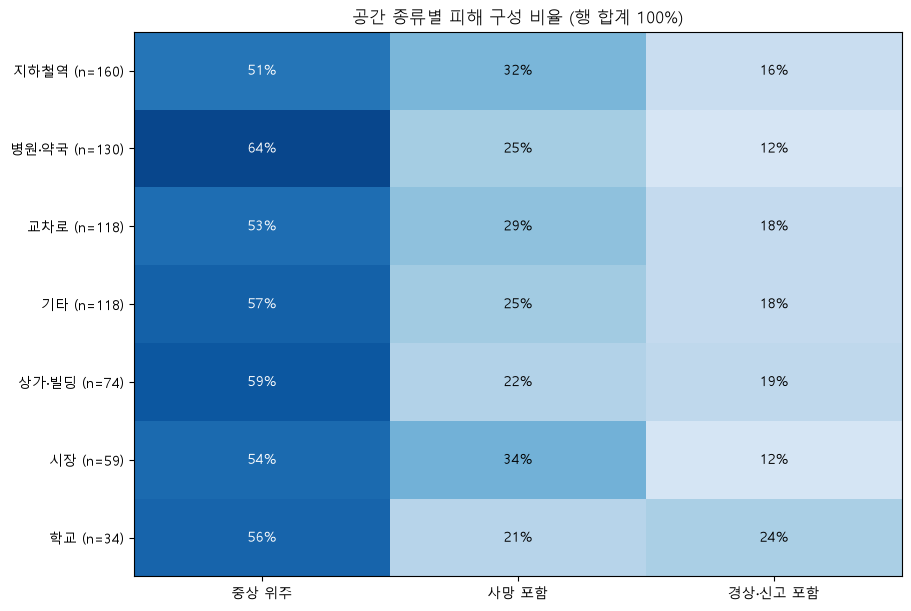

지점 유형(피해 구성 / 규모) 상위


지점_유형,중상 위주 / 7건,중상 위주 / 8~9건,사망 포함 / 7건,경상·신고 포함 / 7건,중상 위주 / 10건 이상,사망 포함 / 8~9건,사망 포함 / 10건 이상,경상·신고 포함 / 8~9건,경상·신고 포함 / 10건 이상
지점 수,225,102,101,66,63,55,35,32,14


In [ ]:
import re
# 지점명에서 공간 종류 표시 (지점명 괄호 안의 '부근' 시설 이름을 키워드로 분류). 실제 토지 이용이 아니라 거친 분류다
d = seoul_analysis
landmark = d['지점명'].str.extract(r'\((.*)\)')[0].str.replace(r'\s*부근\s*$', '', regex=True)
SPACE_RULES = [('지하철역', r'역|출구'), ('시장', r'시장'), ('병원·약국', r'병원|의원|약국|한의원|치과'),
               ('학교', r'학교|초교|중학|고교|대학|유치원|어린이집'), ('상가·빌딩', r'상가|빌딩|타워|센터|백화점|마트|프라자|플라자|몰'),
               ('교차로', r'교차로|사거리|삼거리|오거리|네거리|입구|앞')]   # 위에서부터 먼저 맞는 종류로 정한다

def space_type(text):
    if not isinstance(text, str):
        return '기타'
    for name, pattern in SPACE_RULES:
        if re.search(pattern, text):
            return name
    return '기타'

d['공간_종류'] = landmark.map(space_type)
print('공간 종류별 지점 수')
display(d['공간_종류'].value_counts().rename('지점 수').to_frame().T)
print('기타로 남은 이름 예:', landmark[d['공간_종류'].eq('기타')].head(12).tolist())

order = ['중상 위주', '사망 포함', '경상·신고 포함']
ct = pd.crosstab(d['공간_종류'], d['피해_구성']).reindex(columns=order)
n = ct.sum(axis=1)
rate = ct.div(n, axis=0) * 100
spaces = n.sort_values(ascending=False).index.tolist()
tbl = rate.loc[spaces].round(1)
tbl.insert(0, '지점 수', n.loc[spaces])
tbl['평균 사고건수'] = d.groupby('공간_종류')['사고건수'].mean().loc[spaces].round(2)
print('공간 종류별 피해 구성 비율(%)')
display(tbl)

fig, ax = plt.subplots(figsize=(9, 6), layout='constrained')
im = ax.imshow(rate.loc[spaces].to_numpy(), cmap='Blues', vmin=0, vmax=70, aspect='auto')
ax.set_xticks(range(3), order)
ax.set_yticks(range(len(spaces)), [f'{s} (n={n[s]})' for s in spaces])
for i, s in enumerate(spaces):
    for j, k in enumerate(order):
        ax.text(j, i, f'{rate.loc[s, k]:.0f}%', ha='center', va='center', color='white' if rate.loc[s, k] > 45 else 'black')
ax.set_title('공간 종류별 피해 구성 비율 (행 합계 100%)')
ax.grid(False)
plt.show()

print('지점 유형(피해 구성 / 규모) 상위')
display(d['지점_유형'].value_counts().rename('지점 수').to_frame().T)

### 6-5. 실행 결과 정리

**컬럼 관계 (6-2)**
- 사고건수는 사망자수+중상자수보다 클 수 없다. 693곳 중 563곳은 같고 130곳은 더 적다(한 사고에서 여러 명이 사망·중상). 경상·부상신고자가 있는 155곳은 모두 사고건수가 사상자수보다 적다. 사고건수는 사망·중상 기준으로 센 값이고 경상·부상신고는 그 위에 얹힌 값으로 보인다(자료 설명서로 확인 필요).
- 사망자수가 늘면 중상자수가 줄고 사고건수는 그대로다(사망 0명 8.35 → 1명 7.41 → 2명 6.54, 사고건수 평균은 8.1~8.2). 사망과 중상은 사고건수를 나눠 갖는 관계이고 상관이 -0.37이다.
- 사고당 사상자수는 경상자수와 0.75로 함께 움직인다. 경상자가 있는 지점에서 한 사고당 사상자가 많아진다.
- 폴리곤 면적은 19,519~19,721㎡로 거의 같아서(변동계수 0.25%) 유형을 나누는 재료가 되지 않는다.

**유형 (6-3)**
- 피해 구성: 중상 위주 390곳(56%), 사망 포함 191곳(28%), 경상·신고 포함 112곳(16%).
- 규모: 7건 392곳(57%), 8~9건 189곳, 10건 이상 112곳. 규모가 커져도 피해 구성 비율은 크게 달라지지 않는다(사망 포함 26% → 29% → 31%).
- 한 사고에서 여러 명이 사망·중상한 사고가 든 지점: 130곳(18.8%).

**공간 종류 (6-4)**
- 지하철역 160곳, 병원·약국 130곳, 교차로 118곳, 상가·빌딩 74곳, 시장 59곳, 학교 34곳, 기타 118곳.
- 공간 종류별 피해 구성 차이는 크지 않다. 사망 포함 비율은 학교 21%~시장 34%, 중상 위주 비율은 지하철역 51%~병원·약국 64%다. 학교는 34곳뿐이라 비율이 불안정하다.

**한계**: 사고 기간을 모른다. 지점명 분류는 거칠고 기타가 17%다. 유형은 사고 수치로만 나눈 것이라 "어떤 공간인가"를 아직 다 설명하지 못한다. 경사·횡단보도 같은 공간 특성을 붙여서 유형을 채워 나가는 것이 다음 단계다.

---
## 7. 교차로형 사고다발지역과 교차로 횡단보도 정보

### 7-1. 발상과 방법

- **발상**: 사고다발지역의 지점명에는 "성균관대입구교차로", "약수역사거리"처럼 실제 장소 이름이 들어 있다. 여기서 **교차로 계열 단어**(교차로·사거리·삼거리·오거리·네거리)가 든 지점을 뽑으면, 횡단보도 데이터의 교차로(`교차로관리번호`)와 이어 볼 수 있다. 그러면 "교차로 안에서 나타난 사고 양상"과 "그 교차로의 횡단보도 정보(개수·종류·보행등)"의 관계를 볼 수 있다.
- **교차로 연결 방법**: 지점명이 아니라 **위치**로 잇는다. 사고다발지역 폴리곤 안(경계 포함) 횡단보도를 교차로관리번호로 묶고, 가장 많이 걸린 교차로를 그 지점의 교차로로 삼는다(같으면 폴리곤 중심에 가까운 쪽). 이름이 맞는지는 연결이 맞았는지 보는 검증에만 쓴다.
- **정보**: 교차로 전체의 횡단보도 수, 종류별 개수(이단·화살표있음 / 일단·화살표없음 / 기타), 보행등 없는 횡단보도 수와 비율, 폴리곤 안에 걸린 교차로 수. 사고 쪽은 사고 지표 9개와 6장의 피해 구성이다.
- 6-4의 `공간_종류`는 지하철역·시장 등을 먼저 정하고 남은 것을 교차로로 두었다. 이번 `교차로형`은 그것과 별도로, 지점명에 교차로 계열 단어가 든 지점을 모두 뽑은 것이다.
- 통계검정은 하지 않는다.

### 7-2. 교차로형 지점 뽑기와 교차로 연결

지점명에 교차로 계열 단어가 든 지점을 뽑고, 폴리곤 안 횡단보도로 횡단보도 데이터의 교차로에 연결한다. 연결한 결과의 이름이 지점명과 맞는지도 확인한다. 이름이 맞지 않는 곳은 표기만 다른 것인지 연결이 틀린 것인지 알 수 없어, 표에서 빼지 않고 개수만 확인한다.

In [ ]:
import re

# 지점명에 교차로 계열 단어가 든 사고다발지역을 뽑고, 폴리곤 안 횡단보도로 횡단보도 데이터의 교차로에 연결한다
IX_PATTERN = r'교차로|사거리|삼거리|오거리|네거리'
d = seoul_analysis
d['지점_시설명'] = d['지점명'].str.extract(r'\((.*)\)')[0].str.replace(r'\s*부근\s*$', '', regex=True)
d['교차로형'] = d['지점_시설명'].str.contains(IX_PATTERN)
ix_sites = d.loc[d['교차로형'], ['site_id', '지점_시설명', 'geometry']]

# 폴리곤 안(경계 포함) 횡단보도를 교차로관리번호로 묶고, 가장 많이 걸린 교차로를 그 지점의 교차로로 삼는다
inside_ix = gpd.sjoin(seoul_cross, ix_sites, how='inner', predicate='intersects')
centers = gpd.GeoSeries(inside_ix['site_id'].map(ix_sites.set_index('site_id').geometry.centroid).to_numpy(), index=inside_ix.index, crs=SEOUL_CRS)
inside_ix['중심거리'] = inside_ix.geometry.distance(centers)
per = (inside_ix.groupby(['site_id', '교차로관리번호'])
       .agg(안_횡단보도수=('연번', 'size'), 교차로명=('교차로명', 'first'), 중심거리=('중심거리', 'mean')).reset_index())
n_ix = per.groupby('site_id').size().rename('폴리곤_안_교차로수')
main_ix = (per.sort_values(['site_id', '안_횡단보도수', '중심거리'], ascending=[True, False, True])
           .groupby('site_id').head(1).set_index('site_id').join(n_ix))

# 교차로 전체의 횡단보도 정보 (폴리곤 밖에 걸친 횡단보도도 포함)
whole = seoul_cross[seoul_cross['교차로관리번호'].isin(main_ix['교차로관리번호'])].copy()
whole['종류_구분'] = whole['횡단보도종류'].map({'이단(화살표있음)': '이단_화살표있음', '일단(화살표없음)': '일단_화살표없음'}).fillna('기타종류')
kind = whole.groupby(['교차로관리번호', '종류_구분']).size().unstack(fill_value=0).reindex(columns=['이단_화살표있음', '일단_화살표없음', '기타종류'], fill_value=0).add_suffix('_수')
sig = whole.groupby(['교차로관리번호', '보행등유무']).size().unstack(fill_value=0).reindex(columns=['유', '무'], fill_value=0)
ix_info = kind.join(sig.rename(columns={'유': '보행등_유_수', '무': '보행등_무_수'}))
ix_info['교차로_횡단보도수'] = whole.groupby('교차로관리번호').size()
ix_info['보행등_없음_비율'] = ix_info['보행등_무_수'] / (ix_info['보행등_유_수'] + ix_info['보행등_무_수'])
outcome_cols = ['지점_시설명', '피해_구성', '규모_구간', '사고건수'] + acc_outcomes
ix_table = main_ix.join(ix_info, on='교차로관리번호').join(d.set_index('site_id')[outcome_cols])

# 이름이 맞는지 확인 (연결이 맞았는지 보는 검증용이며, 맞지 않아도 표에서 빼지 않는다)
def norm_name(s):
    s = re.sub(r'\(.*?\)|\d|\s', '', str(s))
    return re.sub(r'교차로|사거리|삼거리|오거리|네거리|앞', '', s)
def name_match(a, b):
    a, b = norm_name(a), norm_name(b)
    return len(a) >= 2 and len(b) >= 2 and (a in b or b in a)
ix_table['이름일치'] = [name_match(a, b) for a, b in zip(ix_table['지점_시설명'], ix_table['교차로명'])]

n_all, n_ix_site, n_linked = len(d), int(d['교차로형'].sum()), len(ix_table)
print(f'서울 사고다발지역 {n_all}곳 중 지점명에 교차로 계열 단어가 든 곳: {n_ix_site}곳 ({n_ix_site / n_all * 100:.0f}%)')
print(f'  폴리곤 안에 횡단보도가 있어 교차로에 연결된 곳: {n_linked}곳 / 연결 못 한 곳(폴리곤 안 횡단보도 없음): {n_ix_site - n_linked}곳')
print('  폴리곤 안에 걸린 교차로 수 (지점 수):', ix_table['폴리곤_안_교차로수'].value_counts().sort_index().to_dict())
print(f"  이름으로도 일치한 곳: {int(ix_table['이름일치'].sum())}곳 ({ix_table['이름일치'].mean() * 100:.0f}%)")
print(f"  폴리곤 안 횡단보도 수 중앙값 {ix_table['안_횡단보도수'].median():.0f}, 교차로 전체 횡단보도 수 중앙값 {ix_table['교차로_횡단보도수'].median():.0f}")
print('이름이 맞지 않은 연결 예 (연결이 틀렸는지, 표기만 다른지 눈으로 확인용)')
display(ix_table.loc[~ix_table['이름일치'], ['지점_시설명', '교차로명', '안_횡단보도수', '폴리곤_안_교차로수']].head(10))

서울 사고다발지역 693곳 중 지점명에 교차로 계열 단어가 든 곳: 254곳 (37%)
  폴리곤 안에 횡단보도가 있어 교차로에 연결된 곳: 238곳 / 연결 못 한 곳(폴리곤 안 횡단보도 없음): 16곳
  폴리곤 안에 걸린 교차로 수 (지점 수): {1: 136, 2: 81, 3: 17, 4: 3, 5: 1}
  이름으로도 일치한 곳: 172곳 (72%)
  폴리곤 안 횡단보도 수 중앙값 4, 교차로 전체 횡단보도 수 중앙값 4
이름이 맞지 않은 연결 예 (연결이 틀렸는지, 표기만 다른지 눈으로 확인용)


,지점_시설명,교차로명,안_횡단보도수,폴리곤_안_교차로수
site_id,,,,
acc_row_100,영등포여상사거리,신정5동,4,1
acc_row_101,롯데캐슬위너앞사거리,목2동등촌시장,3,1
acc_row_1082,동묘앞역교차로,완구시장입구,3,2
acc_row_1090,신금호역교차로,금호초교입구(경보)1,1,1
acc_row_1099,답십리1동교차로,답십리역,6,2
acc_row_1103,장안동사거리,장안삼성쉐르빌,2,2
acc_row_1109,신내지하차도교차로,국민망우삼거리,5,2
acc_row_1112,우림시장교차로,플러스빌,3,1
acc_row_1114,겸재삼거리,새마을금고서일대점,3,1


### 7-3. 교차로형 지점과 그 외 지점의 사고 양상

교차로형 지점(254곳)과 그 외 지점(439곳)의 피해 구성 비율과 사고 규모를 비교한다.

교차로형 vs 그 외: 피해 구성 비율(%)과 사고 규모


피해_구성,중상 위주,사망 포함,경상·신고 포함,지점수,평균 사고건수,평균 사고당 사상자수,다수피해 사고 포함_%
교차로형,,,,,,,
교차로형,52.0,31.5,16.5,254,8.24,1.071,16.5
그 외,58.8,25.3,15.9,439,8.08,1.078,20.0


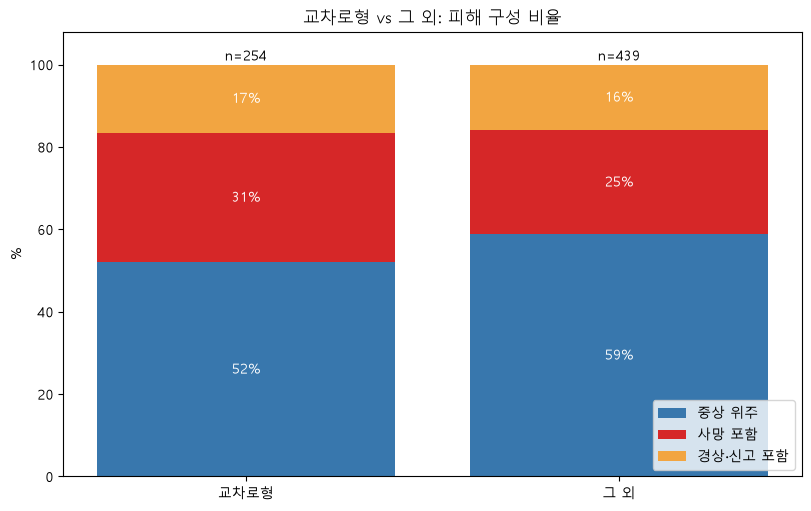

In [ ]:
# 교차로형 사고다발지역과 그 외 지점의 사고 양상 비교 (서울 693곳)
d = seoul_analysis
order = ['중상 위주', '사망 포함', '경상·신고 포함']
grp = d['교차로형'].map({True: '교차로형', False: '그 외'})
ct = pd.crosstab(grp, d['피해_구성']).reindex(index=['교차로형', '그 외'], columns=order)
rate = ct.div(ct.sum(axis=1), axis=0) * 100
summary = rate.round(1).assign(지점수=ct.sum(axis=1))
summary['평균 사고건수'] = d.groupby(grp)['사고건수'].mean().round(2)
summary['평균 사고당 사상자수'] = d.groupby(grp)['사고당_사상자수'].mean().round(3)
summary['다수피해 사고 포함_%'] = (d.groupby(grp)['다수피해_사고'].mean() * 100).round(1)
print('교차로형 vs 그 외: 피해 구성 비율(%)과 사고 규모')
display(summary)

colors = {'중상 위주': '#3877ad', '사망 포함': '#d62728', '경상·신고 포함': '#f2a541'}
fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
bottom = np.zeros(len(rate))
for k in order:
    ax.bar(rate.index, rate[k], bottom=bottom, color=colors[k], label=k)
    for i, (b, v) in enumerate(zip(bottom, rate[k])):
        ax.text(i, b + v / 2, f'{v:.0f}%', ha='center', va='center', color='white')
    bottom += rate[k].to_numpy()
for i, n in enumerate(ct.sum(axis=1)):
    ax.text(i, 101, f'n={n}', ha='center')
ax.set(title='교차로형 vs 그 외: 피해 구성 비율', ylabel='%', ylim=(0, 108))
ax.legend(loc='lower right')
plt.show()

### 7-4. 교차로 횡단보도 정보와 사고 양상의 관계

교차로에 연결된 교차로형 지점(238곳)에서, 교차로의 횡단보도 정보와 사고 지표 9개의 Spearman 순위상관을 본다. 이어서 피해 구성(중상 위주·사망 포함·경상·신고 포함)별로 교차로 정보의 평균이 다른지 본다. 연결이 틀렸을 가능성을 보려고, 교차로 이름까지 일치한 지점만으로도 다시 계산한다.

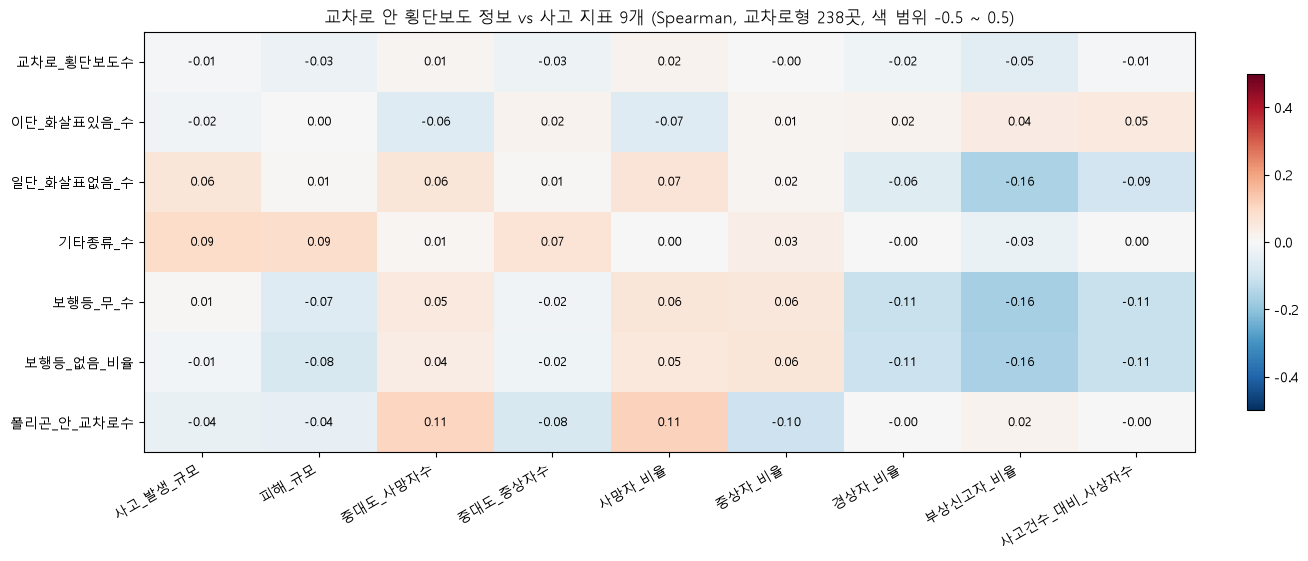

Spearman 순위상관


,사고_발생_규모,피해_규모,중대도_사망자수,중대도_중상자수,사망자_비율,중상자_비율,경상자_비율,부상신고자_비율,사고건수_대비_사상자수
교차로_횡단보도수,-0.01,-0.03,0.01,-0.03,0.02,-0.00,-0.02,-0.05,-0.01
이단_화살표있음_수,-0.02,0.00,-0.06,0.02,-0.07,0.01,0.02,0.04,0.05
일단_화살표없음_수,0.06,0.01,0.06,0.01,0.07,0.02,-0.06,-0.16,-0.09
기타종류_수,0.09,0.09,0.01,0.07,0.00,0.03,-0.00,-0.03,0.00
보행등_무_수,0.01,-0.07,0.05,-0.02,0.06,0.06,-0.11,-0.16,-0.11
보행등_없음_비율,-0.01,-0.08,0.04,-0.02,0.05,0.06,-0.11,-0.16,-0.11
폴리곤_안_교차로수,-0.04,-0.04,0.11,-0.08,0.11,-0.10,-0.00,0.02,-0.00


교차로 이름까지 일치한 172곳만 다시 계산: 상관계수 절댓값 최대 0.23 (전체 0.16)
  이름 일치 곳에서 가장 큰 칸: 보행등_없음_비율 - 사고건수_대비_사상자수 = -0.23
피해 구성별 교차로 정보 평균


,지점 수,교차로_횡단보도수,이단_화살표있음_수,일단_화살표없음_수,기타종류_수,보행등_무_수,보행등_없음_비율,폴리곤_안_교차로수
피해_구성,,,,,,,,
중상 위주,123,4.89,3.28,1.15,0.46,1.43,0.30,1.46
사망 포함,74,4.74,2.99,1.32,0.43,1.50,0.30,1.64
경상·신고 포함,41,4.88,3.41,1.07,0.39,1.17,0.25,1.61


In [ ]:
# 교차로 안 횡단보도 정보와 사고 양상의 관계 (교차로에 연결된 교차로형 지점). 탐색용이며 p값·검정은 없다
feats = ['교차로_횡단보도수', '이단_화살표있음_수', '일단_화살표없음_수', '기타종류_수', '보행등_무_수', '보행등_없음_비율', '폴리곤_안_교차로수']
t = ix_table

def spearman_pair(xs, ys, data):
    r = pd.DataFrame(index=xs, columns=ys, dtype=float)
    for x in xs:
        for y in ys:
            v = data[[x, y]].dropna()
            r.loc[x, y] = v[x].corr(v[y], method='spearman') if v[x].nunique() > 1 and v[y].nunique() > 1 else np.nan
    return r

r = spearman_pair(feats, acc_outcomes, t)
n_used = int(t[feats[0]].notna().sum())
fig, ax = plt.subplots(figsize=(13, 5.5), layout='constrained')
im = ax.imshow(r.to_numpy(dtype=float), cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
ax.set_xticks(range(len(r.columns)), r.columns, rotation=30, ha='right')
ax.set_yticks(range(len(r.index)), r.index)
for i in range(len(r.index)):
    for j in range(len(r.columns)):
        ax.text(j, i, f'{r.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title(f'교차로 안 횡단보도 정보 vs 사고 지표 9개 (Spearman, 교차로형 {n_used}곳, 색 범위 -0.5 ~ 0.5)')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()
print('Spearman 순위상관'); display(r.round(2))
r_m = spearman_pair(feats, acc_outcomes, t[t['이름일치']])
print(f"교차로 이름까지 일치한 {int(t['이름일치'].sum())}곳만 다시 계산: 상관계수 절댓값 최대 {np.nanmax(np.abs(r_m.to_numpy(dtype=float))):.2f} (전체 {np.nanmax(np.abs(r.to_numpy(dtype=float))):.2f})")
mm = r_m.abs().stack().idxmax()
print(f'  이름 일치 곳에서 가장 큰 칸: {mm[0]} - {mm[1]} = {r_m.loc[mm[0], mm[1]]:.2f}')

# 피해 구성별로 교차로 정보가 어떻게 다른가 (평균)
order = ['중상 위주', '사망 포함', '경상·신고 포함']
by = t.groupby('피해_구성')[feats].mean().reindex(order).round(2)
by.insert(0, '지점 수', t['피해_구성'].value_counts().reindex(order))
print('피해 구성별 교차로 정보 평균')
display(by)

### 7-5. 실행 결과 정리

**교차로형 지점과 연결 (7-2)**
- 서울 693곳 중 지점명에 교차로 계열 단어가 든 곳은 254곳(37%)이다. 이 중 238곳은 폴리곤 안에 횡단보도가 있어 교차로에 연결됐고, 16곳은 폴리곤 안에 횡단보도가 없어 연결하지 못했다.
- 폴리곤 안에 걸린 교차로는 1개인 곳이 136곳, 2개가 81곳, 3개 이상이 21곳이다. 폴리곤(반경 약 80m)이 교차로 하나에만 딱 맞지는 않는다.
- 교차로 이름까지 지점명과 일치한 곳은 172곳(72%)이다. 나머지는 이름만 다를 수도 있고 연결이 틀렸을 수도 있다.

**교차로형 vs 그 외 (7-3)**
- 사망 포함 비율은 교차로형 31.5%, 그 외 25.3%로 교차로형이 6%p 높다. 중상 위주는 52.0% 대 58.8%, 경상·신고 포함은 16.5% 대 15.9%다. 평균 사고건수는 8.24건 대 8.08건으로 비슷하다.

**교차로 횡단보도 정보와 사고 양상 (7-4)**
- 교차로 횡단보도 수, 종류별 개수, 보행등 없는 비율과 사고 지표 9개의 상관계수 절댓값은 모두 0.16 이하다. 뚜렷한 관계는 보이지 않는다.
- 가장 진한 칸(-0.16)은 보행등 없는 횡단보도 수·일단(화살표없음) 수와 부상신고자_비율이다. 부상신고자가 있는 지점이 693곳 중 28곳뿐이라 불안정하다.
- 이름이 일치한 172곳만 보면 가장 큰 칸이 보행등 없는 비율과 사고건수_대비_사상자수의 -0.23이다. 전체(-0.11)에서는 약해지고, 여러 칸 중 하나가 크게 나온 것이라 우연일 가능성이 있다.
- 피해 구성별 교차로 정보 평균도 비슷하다(횡단보도 수 4.7~4.9개, 보행등 없는 비율 0.25~0.30).

**한계**: 교차로 연결은 위치 기반의 근사라서 일부는 틀렸을 수 있다. 사고다발지역이 이미 선별된 곳이라는 점, 노출량이 없다는 점은 그대로다. 교차로형에서 사망 포함 비율이 조금 높은 이유는 확인하지 못했다.

---
## 8. 사고 지표를 합쳐서 다시 보기

### 8-1. 무엇을 합쳤는가

지금까지는 사고 지표 9개를 하나씩 봤다. 이 중 사망자수와 중상자수, 사망자·중상자 비율은 값이 드물거나 서로 겹쳐서, 합쳐서 다시 본다.

- **사망중상자수** = 사망자수 + 중상자수
- **사망중상_비율** = 사망자_비율 + 중상자_비율 (= 사망·중상자수 ÷ 사상자수)
- **경상자_비율**은 따로 보지 않는다. 사망중상_비율의 나머지(경상자와 부상신고자)라서 거꾸로 같은 정보다. 경상자까지 합치면 부상신고자 비율만 남아 거의 0이라 뜻이 없다.
- 그대로 두는 지표: 사고_발생_규모, 피해_규모, 사고건수_대비_사상자수. 결국 5개 지표가 된다.
- **다시 보는 것**: 폴리곤 안 횡단보도(개수·종류·보행등), 지형 경사, 7장의 교차로형 지점 교차로 정보. 5장의 안쪽-바깥 띠 경사 차이는 오래 걸려서 다시 계산하지 않았다.
- 탐색용 Spearman 순위상관이며 p값은 없다.

사망중상_비율 = 사망자_비율 + 중상자_비율 (최대 차이 1.1e-16), 경상자_비율은 이 값의 나머지(1 - 사망중상_비율 - 부상신고자_비율)라 따로 보지 않는다
합친 사고 지표: ['사고_발생_규모', '피해_규모', '사망중상자수', '사망중상_비율', '사고건수_대비_사상자수']


사고_발생_규모와 사망중상자수의 순위상관 0.92 (사고건수가 사망+중상자수에서 나온 값이라 거의 같은 정보다)


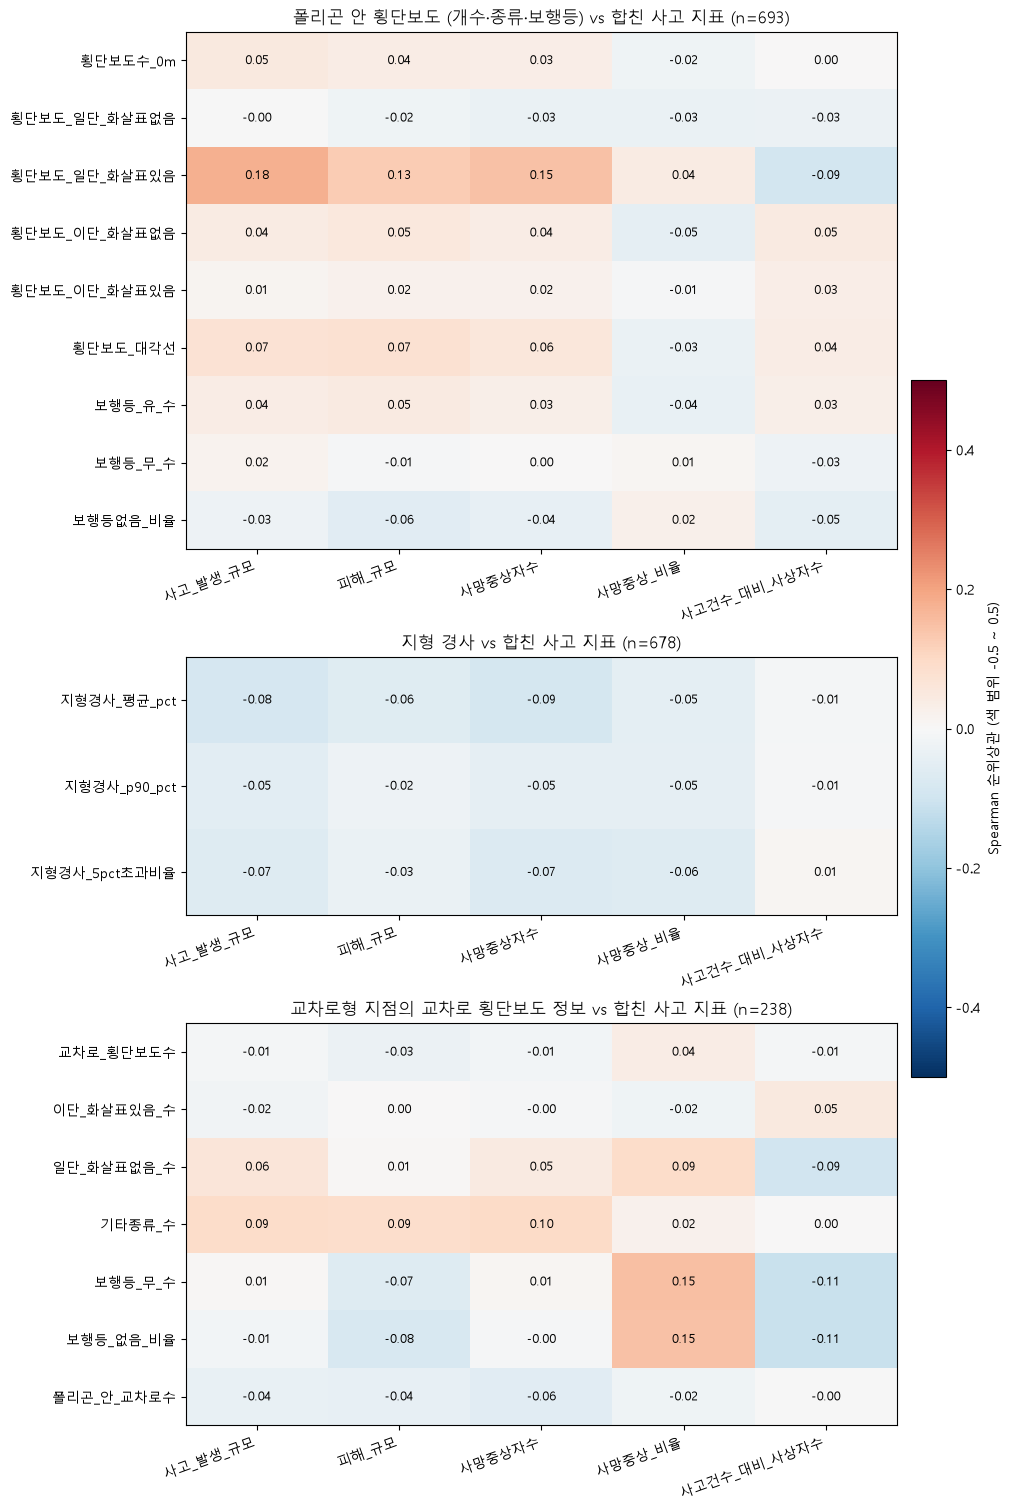

대상별 상관계수가 큰 칸


,n,절댓값 최대,큰 칸 3개
대상,,,
폴리곤 안 횡단보도 (개수·종류·보행등),693,0.18,횡단보도_일단_화살표있음~사고_발생_규모 +0.18 / 횡단보도_일단_화살표있음~사망중상자수 +0.15 / 횡단보도_일단_화살표있음~피해_규모 +0.13
지형 경사,678,0.09,지형경사_평균_pct~사망중상자수 -0.09 / 지형경사_평균_pct~사고_발생_규모 -0.08 / 지형경사_5pct초과비율~사망중상자수 -0.07
교차로형 지점의 교차로 횡단보도 정보,238,0.15,보행등_무_수~사망중상_비율 +0.15 / 보행등_없음_비율~사망중상_비율 +0.15 / 보행등_무_수~사고건수_대비_사상자수 -0.11


교차로형 vs 그 외: 합친 사고 지표 평균


,지점 수,사고_발생_규모,피해_규모,사망중상자수,사망중상_비율,사고건수_대비_사상자수
교차로형,,,,,,
교차로형,254,8.236,8.803,8.425,0.962,1.071
그 외,439,8.080,8.706,8.344,0.967,1.078


In [ ]:
# 사고 지표를 합쳐서 다시 본다: 사망자수+중상자수, 사망자·중상자 비율의 합. 탐색용이며 p값·검정은 없다
d = seoul_analysis
d['사망중상자수'] = d['사망자수'] + d['중상자수']
gap = (d['사망중상_비율'] - (d['사망자_비율'] + d['중상자_비율'])).abs().max()
print(f'사망중상_비율 = 사망자_비율 + 중상자_비율 (최대 차이 {gap:.1e}), 경상자_비율은 이 값의 나머지(1 - 사망중상_비율 - 부상신고자_비율)라 따로 보지 않는다')
merged = ['사고_발생_규모', '피해_규모', '사망중상자수', '사망중상_비율', '사고건수_대비_사상자수']
print('합친 사고 지표:', merged)
print(f"사고_발생_규모와 사망중상자수의 순위상관 {d['사고_발생_규모'].corr(d['사망중상자수'], method='spearman'):.2f} (사고건수가 사망+중상자수에서 나온 값이라 거의 같은 정보다)")

cw_feats = ['횡단보도수_0m'] + [c for c in type_cols if c != '횡단보도_삼단_화살표있음'] + ['보행등_유_수', '보행등_무_수', '보행등없음_비율']
slope_feats = ['지형경사_평균_pct', '지형경사_p90_pct', '지형경사_5pct초과비율']
ix_feats = ['교차로_횡단보도수', '이단_화살표있음_수', '일단_화살표없음_수', '기타종류_수', '보행등_무_수', '보행등_없음_비율', '폴리곤_안_교차로수']
ix_m = ix_table[ix_feats].join(d.set_index('site_id')[merged])

def spearman_pair(data, xs, ys):
    r = pd.DataFrame(index=xs, columns=ys, dtype=float)
    for x in xs:
        for y in ys:
            v = data[[x, y]].dropna()
            r.loc[x, y] = v[x].corr(v[y], method='spearman') if v[x].nunique() > 1 and v[y].nunique() > 1 else np.nan
    return r

groups = [('폴리곤 안 횡단보도 (개수·종류·보행등)', d, cw_feats), ('지형 경사', d, slope_feats), ('교차로형 지점의 교차로 횡단보도 정보', ix_m, ix_feats)]
results = [(name, spearman_pair(data, feats, merged), int(data[feats[0]].notna().sum())) for name, data, feats in groups]

fig, axes = plt.subplots(3, 1, figsize=(10, 15), layout='constrained', gridspec_kw={'height_ratios': [len(cw_feats), len(slope_feats) + 1.5, len(ix_feats)]})
for ax, (name, r, n) in zip(axes, results):
    im = ax.imshow(r.to_numpy(dtype=float), cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(len(r.columns)), r.columns, rotation=20, ha='right')
    ax.set_yticks(range(len(r.index)), r.index)
    for i in range(len(r.index)):
        for j in range(len(r.columns)):
            ax.text(j, i, f'{r.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
    ax.set_title(f'{name} vs 합친 사고 지표 (n={n})')
    ax.grid(False)
fig.colorbar(im, ax=axes, label='Spearman 순위상관 (색 범위 -0.5 ~ 0.5)', shrink=0.5, pad=0.02)
plt.show()

rows = []
for name, r, n in results:
    top = r.abs().stack().sort_values(ascending=False).head(3)
    rows.append({'대상': name, 'n': n, '절댓값 최대': round(top.iloc[0], 2),
                 '큰 칸 3개': ' / '.join(f'{a}~{b} {r.loc[a, b]:+.2f}' for a, b in top.index)})
print('대상별 상관계수가 큰 칸')
with pd.option_context('display.max_colwidth', 200, 'display.width', 250):
    display(pd.DataFrame(rows).set_index('대상'))

grp = d['교차로형'].map({True: '교차로형', False: '그 외'})
tbl = d.groupby(grp)[merged].mean().round(3)
tbl.insert(0, '지점 수', grp.value_counts())
print('교차로형 vs 그 외: 합친 사고 지표 평균')
display(tbl)

### 8-2. 실행 결과 정리

- **합친 지표는 결과를 바꾸지 못했다.** 상관계수 절댓값 최대가 폴리곤 안 횡단보도 0.18, 지형 경사 0.09, 교차로 횡단보도 정보 0.15다. 9개 지표로 볼 때(0.20, 0.09, 0.16)와 거의 같다.
- 사고_발생_규모와 사망중상자수의 순위상관이 0.92다. 사고건수가 사망+중상자수에서 나온 값이라 거의 같은 정보이고, 둘을 따로 봐도 새로운 결과가 나오지 않는다.
- **폴리곤 안 횡단보도**: 가장 큰 칸은 일단(화살표있음) 개수와 사고_발생_규모 0.18이다. 이 종류가 폴리곤 안에 44개뿐이라 근거가 약하다.
- **교차로형 지점**: 보행등 없는 횡단보도 수·비율과 사망중상_비율이 0.15다. 보행등이 없는 횡단보도가 많을수록 사망·중상 비중이 조금 높은 쪽이다. 7장에서 경상자_비율(-0.11)·부상신고자_비율(-0.16)과 반대 부호로 나온 것과 같은 이야기다. 다만 238곳에서 0.15이고 크기가 작아, 우연일 가능성을 배제하기 어렵다.
- **교차로형 vs 그 외**: 사망중상_비율이 0.962 대 0.967, 사망중상자수가 8.43명 대 8.34명으로 같다. 7-3에서 본 사망 포함 비율의 차이(31.5% 대 25.3%)는 사망자만 따로 볼 때 나타난 것이고, 중상자와 합치면 보이지 않는다.
- 중상자가 사상자의 대부분이라(사망·중상이 사상자의 96~97%) 합친 지표는 중상자수와 사실상 같다. 사망자만 따로 보면 다른 결과가 나올 수 있지만, 사망자가 있는 지점이 서울 693곳 중 191곳뿐이라 불안정하다.